# How to use

1. Run all the starter cells
    * these cells create the tape7 objects
    * ensure your tape7 data files are located in the /data folder
    * ensure your SRF files are in the /data folder as well
    * These cells also include some graphing functions you can use as well
2. use cmd f + these below to jump to different locations of work
    * END STARTER CELLS
    * RADIANCE GRAPHS
    * START OF MAIN WORK
    * START OF ERROR ANALYSIS
    * TESTING XGBOOST


# START OF STARTER CELLS

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import os
import seaborn as sns

from tp7.tp7 import Tape7
from srfs.srfs import SRFS
from matt_code.convert_tp7 import load_all_runs_from_tp7
import scipy.integrate as integrate
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, explained_variance_score, mean_absolute_percentage_error
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.tree import export_text, plot_tree

import warnings
warnings.filterwarnings('ignore')

In [2]:
def modtran_data_files(path: str) -> list:
    files = [path + "/" + file for file in os.listdir(path) if file.endswith(".tp7")]
    return files

a00_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA00")
a41_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA41")
a60_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA60")
a75_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA75")
a85_files = modtran_data_files("./data/Modtran_Unfiltering_Tape7s_SZA85")

srf = SRFS("./data/libera_srfs_20241017.csv")
tot_wvln = srf.srf_vals['wavelength [um]']
sw_srf = srf.srf_vals[' sw srf']
lw_srf = srf.srf_vals[' lw srf']
# tot_wvln = srf.srf_vals['wavelength_um']
# sw_srf = srf.srf_vals['sw_srf']
# lw_srf = srf.srf_vals['lw_srf']

viirs_rads_indxs = {'M1': [1469, 1701],
             'M2': [1648, 1849],
             'M3': [1873, 2039],
             'M4': [2131, 2260],
             'I1': [2231, 2601],
             'M5': [2467, 2559],
             'DNB': [667, 3090],
             'M6': [2621, 2696],
             'I2': [2790, 2893],
             'M7': [2790, 2893],
             'M8': [3181, 3206],
             'M9': [3264, 3284],
             'I3': [3355, 3401],
             'M10': [3355, 3401],
             'M11': [3546, 3565],
             'I4': [3703, 3757],
             'M12': [3716, 3742],
             'M13': [3744, 3762],
             'M14': [3879, 3887],
             'M15': [3898, 3914],
             'I5': [3896, 3925],
             'M16': [3910, 3922]}

viirs_band_ranges = {
    "I1": "I1 0.60 - 0.68 μm",
    "I2": "I2 0.85 - 0.88 μm",
    "I3": "I3 1.58 - 1.64 μm",
    "I4": "I4 3.55 - 3.93 μm",
    "I5": "I5 10.5 - 12.4 μm",
    "M1": "M1 0.402 - 0.422 μm",
    "M2": "M2 0.436 - 0.454 μm",
    "M3": "M3 0.478 - 0.488 μm",
    "M4": "M4 0.545 - 0.565 μm",
    "M5": "M5 0.662 - 0.682 μm",
    "M6": "M6 0.739 - 0.754 μm",
    "M7": "M7 0.846 - 0.885 μm",
    "M8": "M8 1.23 - 1.25 μm",
    "M9": "M9 1.371 - 1.386 μm",
    "M10": "M10 1.58 - 1.64 μm",
    "M11": "M11 2.23 - 2.28 μm",
    "M12": "M11 3.61 - 3.79 μm",
    "M13": "M13 3.97 - 4.13 μm",
    "M14": "M14 8.4 - 8.7 μm",
    "M15": "M15 10.26 - 11.26 μm",
    "M16": "M16 11.54 - 12.49 μm",
    "DNB": "DNB 0.50 - 0.90 μm"
}

def rename_bands(df: pd.DataFrame) -> pd.DataFrame:
    return df.rename(columns=viirs_band_ranges)

In [3]:
def plot_radiance(rads, title, runnum, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(rads[runnum, 0, :], rads[runnum, s_or_l, :] * 1e6, 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 2:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)

In [4]:
def plot_integrated_radiance(rads, title, idx, wvs, s_or_l=1):
    #access wavelength with rads[:,0,runnum], swrad with rads[:,1,runnum], lwrad with rads[:,2,runnum]

    figure = plt.figure(2, figsize=(10,8))
    ax = plt.axes()
    ax.plot(wvs, rads[idx, :], 'r-', label='Radiance')
    ax.legend(prop={"size":20})
    plt.title("%s Radiance Spectrum"%title, fontsize=40)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.xlabel('Wavelength um', fontsize=30)
    plt.ylabel('Radiance $W m^{-2} um^{-1} sr^{-1}$', fontsize=30)
    if s_or_l == 1:
        plt.xlim(0,50)
    else:
        plt.xlim(0,5)

In [5]:
y_lim_map = {
    "Snow": [[1.75e-6, 4], [1e-5, 100]],
    "Cloudy Ocean": [[2.25e-6, 5], [1e-5, 100]],
    "Land": [[600, 3], [10, 50]],
    "Clear Ocean": [[7e-7, 3], [1.75e-5, 100]],
    "Deep Convective Cloud": [[500, 3], [2.5, 80]]
}

def plot_sza(sza_dict: dict):
    fig, axes = plt.subplots(5, 1, figsize=(18, 50))

    for i, (key, tp7) in enumerate(sza_dict.items()):

        wavelength = tp7.rads[0, 0, :]

        print(key)
        ax_sw = axes[i]
        shortwave = tp7.rads[-1, 1, :]
        interp_shortwave_filt = np.interp(x=wavelength, xp=tot_wvln, fp=sw_srf)
        shortwave_filt = interp_shortwave_filt * shortwave

        ax_sw.plot(wavelength, shortwave_filt, 'r-', label='Filtered')
        ax_sw.plot(wavelength, shortwave, 'b-', label='Unfiltered')
        # ax_sw.set_xlim(0, y_lim_map[key][0][1])
        # ax_sw.set_ylim(0, y_lim_map[key][0][0])
        ax_sw.set_xlim(0, y_lim_map["Land"][0][1])
        ax_sw.set_ylim(0, y_lim_map["Land"][0][0])

        ax_sw.legend(prop={"size": 10})
        ax_sw.set_title(f'Shortwave: {key}')
        ax_sw.set_ylabel('Radiance Wm$^{-2}$µm$^{-1}$sr$^{-1}$')
        ax_sw.set_xlabel('Wavelength µm')
        ax_sw.grid(True)


        # ax_lw = axes[i, 1]
        # longwave = tp7.rads[-1, 2, :]
        # longwave_filt = np.interp(x=wavelength, xp=tot_wvln, fp=lw_srf)
        # longwave_filt = longwave_filt * shortwave
        # ax_lw.plot(wavelength, longwave, longwave_filt, 'b-', label='Longwave')
        # ax_lw.set_xlim(5, y_lim_map[key][1][1])
        # ax_lw.set_ylim(0, y_lim_map[key][1][0])
        #
        # ax_lw.legend(prop={"size": 10})
        # ax_lw.set_title(f'Longwave: {key}')
        # ax_lw.set_ylabel('Radiance Wm$^{-2}$µm$^{-1}$sr$^{-1}$')
        # ax_lw.set_xlabel('Wavelength µm')
        # ax_lw.grid(True)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4)
    plt.show()

In [6]:
viirs_rads_indxs = {'M1': [1469, 1701],
             'M2': [1648, 1849],
             'M3': [1873, 2039],
             'M4': [2131, 2260],
             'I1': [2231, 2601],
             'M5': [2467, 2559],
             'DNB': [667, 3090],
             'M6': [2621, 2696],
             'I2': [2790, 2893],
             'M7': [2790, 2893],
             'M8': [3181, 3206],
             'M9': [3264, 3284],
             'I3': [3355, 3401],
             'M10': [3355, 3401],
             'M11': [3546, 3565],
             'I4': [3703, 3757],
             'M12': [3716, 3742],
             'M13': [3744, 3762],
             'M14': [3879, 3887],
             'M15': [3898, 3914],
             'I5': [3896, 3925],
             'M16': [3910, 3922]}

def viirs_band_integration(tp7_data: Tape7, rad_indxs: dict):
    for idx, run in enumerate(tp7_data.rads):
        for band, rng in rad_indxs.items():
            y_vals = run[1][rng[0]: rng[1] + 1]
            x_vals = run[0][rng[0]: rng[1] + 1]
            integrated = integrate.simpson(y=y_vals, x=x_vals)
            tp7_data.describer_df.loc[idx, band] = integrated

In [7]:
a00_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a00_files]
titles = [file.title for file in a00_data]
a00 = {title: file for title, file in zip(titles, a00_data)}

a41_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a41_files]
titles = [file.title for file in a41_data]
a41 = {title: file for title, file in zip(titles, a41_data)}

a60_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a60_files]
titles = [file.title for file in a60_data]
a60 = {title: file for title, file in zip(titles, a60_data)}

a75_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a75_files]
titles = [file.title for file in a75_data]
a75 = {title: file for title, file in zip(titles, a75_data)}

a85_data = [Tape7(file, tot_wvln, sw_srf, lw_srf) for file in a85_files]
titles = [file.title for file in a85_data]
a85 = {title: file for title, file in zip(titles, a85_data)}


In [8]:
snow_data = [a00["Snow"], a41["Snow"], a60["Snow"], a75["Snow"], a85["Snow"]]
dc_data = [a00["Deep Convective Cloud"], a41["Deep Convective Cloud"], a60["Deep Convective Cloud"],
           a75["Deep Convective Cloud"], a85["Deep Convective Cloud"]]
land_data = [a00["Land"], a41["Land"], a60["Land"], a75["Land"], a85["Land"]]
clear_data = [a00["Clear Ocean"], a41["Clear Ocean"], a60["Clear Ocean"], a75["Clear Ocean"], a85["Clear Ocean"]]
cloudy_data = [a00["Cloudy Ocean"], a41["Cloudy Ocean"], a60["Cloudy Ocean"], a75["Cloudy Ocean"], a85["Cloudy Ocean"]]
[viirs_band_integration(data, viirs_rads_indxs) for data in snow_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in dc_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in land_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in clear_data]
[viirs_band_integration(data, viirs_rads_indxs) for data in cloudy_data]

[None, None, None, None, None]

In [9]:
snow_dfs = [file.describer_df for file in snow_data]
snow_dataset = pd.concat(snow_dfs, axis=0)
land_dfs = [file.describer_df for file in land_data]
dc_dfs = [file.describer_df for file in dc_data]
cloud_dfs = [file.describer_df for file in cloudy_data]
clear_dfs = [file.describer_df for file in clear_data]
land_dataset = pd.concat(land_dfs, axis=0)
dc_dataset = pd.concat(dc_dfs, axis=0)
cloud_dataset = pd.concat(cloud_dfs, axis=0)
clear_dataset = pd.concat(clear_dfs, axis=0)
all_dataset = pd.concat([snow_dataset, land_dataset, dc_dataset, cloud_dataset, clear_dataset])

In [10]:
clear_dataset

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),...,I3,M10,M11,I4,M12,M13,M14,M15,I5,M16
0,Clear Ocean,0.000,0.000,0.0,0,0,61.754012,104.742202,43.977158,66.439684,...,1.379878,1.379878,0.260867,0.289889,0.145132,0.068062,0.003004,0.001845,0.002486,0.000938
1,Clear Ocean,0.000,0.000,0.0,0,1,59.861764,100.234847,42.512746,63.859872,...,1.353868,1.353868,0.257902,0.286892,0.143647,0.067430,0.002983,0.001840,0.002479,0.000935
2,Clear Ocean,0.000,0.000,0.0,0,2,58.575515,96.211097,41.517904,61.526911,...,1.312697,1.312697,0.251675,0.280750,0.140590,0.066131,0.002957,0.001831,0.002466,0.000929
3,Clear Ocean,0.000,0.000,0.0,0,3,56.280375,94.357094,39.741528,60.442017,...,1.236569,1.236569,0.239994,0.269016,0.134748,0.063643,0.002906,0.001813,0.002440,0.000919
4,Clear Ocean,0.000,0.000,0.0,0,4,52.776801,92.622868,37.006801,59.421168,...,1.105825,1.105825,0.219368,0.247597,0.124078,0.059078,0.002808,0.001778,0.002390,0.000897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,Clear Ocean,83.845,89.947,172.5,0,142,55.161028,68.826211,38.615647,44.514829,...,0.312599,0.312599,0.028152,0.004446,0.002860,0.000531,0.000014,0.000010,0.000013,0.000005
143,Clear Ocean,83.845,89.947,172.5,0,143,58.683832,68.796818,41.349000,44.500770,...,0.512514,0.512514,0.050262,0.007428,0.004841,0.000933,0.000018,0.000013,0.000016,0.000006
144,Clear Ocean,83.845,89.947,172.5,0,144,62.944481,68.745825,44.649744,44.474058,...,0.749410,0.749410,0.083528,0.012774,0.008280,0.001732,0.000027,0.000019,0.000023,0.000008
145,Clear Ocean,83.845,89.947,172.5,0,145,68.463058,68.719250,48.909934,44.461081,...,1.046843,1.046843,0.131840,0.020758,0.013350,0.003030,0.000036,0.000023,0.000027,0.000009


In [11]:
all_dataset["Scene"].unique()

array(['Snow', 'Land', 'Deep Convective Cloud', 'Cloudy Ocean',
       'Clear Ocean'], dtype=object)

In [12]:
ocean_clear = all_dataset[all_dataset["Scene"] == "Clear Ocean"]
ocean_clear

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),...,I3,M10,M11,I4,M12,M13,M14,M15,I5,M16
0,Clear Ocean,0.000,0.000,0.0,0,0,61.754012,104.742202,43.977158,66.439684,...,1.379878,1.379878,0.260867,0.289889,0.145132,0.068062,0.003004,0.001845,0.002486,0.000938
1,Clear Ocean,0.000,0.000,0.0,0,1,59.861764,100.234847,42.512746,63.859872,...,1.353868,1.353868,0.257902,0.286892,0.143647,0.067430,0.002983,0.001840,0.002479,0.000935
2,Clear Ocean,0.000,0.000,0.0,0,2,58.575515,96.211097,41.517904,61.526911,...,1.312697,1.312697,0.251675,0.280750,0.140590,0.066131,0.002957,0.001831,0.002466,0.000929
3,Clear Ocean,0.000,0.000,0.0,0,3,56.280375,94.357094,39.741528,60.442017,...,1.236569,1.236569,0.239994,0.269016,0.134748,0.063643,0.002906,0.001813,0.002440,0.000919
4,Clear Ocean,0.000,0.000,0.0,0,4,52.776801,92.622868,37.006801,59.421168,...,1.105825,1.105825,0.219368,0.247597,0.124078,0.059078,0.002808,0.001778,0.002390,0.000897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,Clear Ocean,83.845,89.947,172.5,0,142,55.161028,68.826211,38.615647,44.514829,...,0.312599,0.312599,0.028152,0.004446,0.002860,0.000531,0.000014,0.000010,0.000013,0.000005
143,Clear Ocean,83.845,89.947,172.5,0,143,58.683832,68.796818,41.349000,44.500770,...,0.512514,0.512514,0.050262,0.007428,0.004841,0.000933,0.000018,0.000013,0.000016,0.000006
144,Clear Ocean,83.845,89.947,172.5,0,144,62.944481,68.745825,44.649744,44.474058,...,0.749410,0.749410,0.083528,0.012774,0.008280,0.001732,0.000027,0.000019,0.000023,0.000008
145,Clear Ocean,83.845,89.947,172.5,0,145,68.463058,68.719250,48.909934,44.461081,...,1.046843,1.046843,0.131840,0.020758,0.013350,0.003030,0.000036,0.000023,0.000027,0.000009


In [13]:
def run_regression_model(dataset: pd.DataFrame, neurons=100, rf = True):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    # in the X dataset we want everything except the Unfiltered ground truth data and the run # and Scene
    X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)",]).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                               'Shortwave Filtered Rads (Integrated)',
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    print(X.columns, y.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

    if rf:
        base_model = RandomForestRegressor(n_estimators=neurons, random_state=42)
    else:
        base_model = LinearRegression()
    regression_model = MultiOutputRegressor(base_model)
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
    rmse = root_mean_squared_error(y_test, y_pred, multioutput='raw_values')
    mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
    mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Single MSE"] = mse
    ret["RMSE"] = rmse
    ret["MAE"] = mae
    ret["MAEP"] = mae_percentage

    tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    ret["Shortwave MSPE"] = (1.0 - (rmse[0] / tg_range_sw)) * 100

    tg_range_lw = max(y_test["Longwave Unfiltered Rads (Integrated)"]) - min(y_test["Longwave Unfiltered Rads (Integrated)"])
    ret["Longwave MSPE"] = (1.0 - (rmse[1] / tg_range_lw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    ret["CV RMSE"] = cv_scores
    ret["Model"] = regression_model
    ret["Predictions"] = y_pred
    ret["Y_True"] = y_test

    return ret


In [14]:
def run_shortwave_regression_model(dataset: pd.DataFrame, neurons=100, rf = True):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    # in the X dataset we want everything except the Unfiltered ground truth data and the run # and Scene
    X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)"]).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                               'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)",
                               'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
                               'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                               'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    print(X.columns, y.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

    regression_model = RandomForestRegressor(n_estimators=neurons, random_state=42)
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Single MSE"] = mse
    ret["RMSE"] = rmse
    ret["MAE"] = mae
    # ret["MAEP"] = mae_percentage

    tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    ret["CV RMSE"] = cv_scores

    return [ret, y_pred]

In [15]:
def estimator_testing(scene: str, dataset: pd.DataFrame):
    res = {}
    N = [10, 25, 50, 100, 125, 150, 200]
    tests = [run_regression_model(dataset, neurons=n) for n in N]
    for i in range(len(N)):
        del tests[i]["Model"]
        del tests[i]["Predictions"]
        del tests[i]["Y_True"]
        res[f"{scene}_{N[i]}"] = tests[i]

    return res

In [16]:
def plot_ml_est(results_dict):
    """
    Plots different accuracy metrics against the number of estimators.

    :param results_dict: Dictionary with the format:
                         {
                             num_estimators_1: {
                                 "Single MSE": value,
                                 "RMSE": value,
                                 "MAE": value,
                                 "MAEP": value,
                                 "Shortwave MSPE": value,
                                 "Longwave MSPE": value,
                                 "CV RMSPE": value
                             },
                             num_estimators_2: {...},
                             ...
                         }
    """
    # Extracting number of estimators and metrics
    num_estimators = results_dict.keys()
    # print(num_estimators)
    metrics = ["Single MSE", "RMSE", "MAE", "MAEP", "Shortwave MSPE", "Longwave MSPE", "CV RMSE"]

    # Creating a figure for each metric
    for metric in metrics:
        metric_values = [results_dict[est][metric] for est in num_estimators]

        plt.figure(figsize=(8, 5))
        plt.plot(num_estimators, metric_values, marker='o', linestyle='-')
        plt.xlabel("Number of Estimators")
        plt.ylabel(metric)
        plt.title(f"{metric} vs. Number of Estimators")
        plt.grid(True)
        plt.show()

In [17]:
min_shortwave = min(all_dataset["Shortwave Filtered Rads (Integrated)"])
max_shortwave = max(all_dataset["Shortwave Filtered Rads (Integrated)"])
scaler = MinMaxScaler(feature_range=(min_shortwave, max_shortwave))
all_dataset["Scaled Shortwave Filtered"] = MinMaxScaler().fit_transform(all_dataset[["Shortwave Filtered Rads (Integrated)"]])
all_dataset["Scaled Shortwave Unfiltered"] = MinMaxScaler().fit_transform(all_dataset[['Shortwave Unfiltered Rads (Integrated)']])
all_dataset["Scaled Longwave Filtered"] = MinMaxScaler().fit_transform(all_dataset[["Longwave Filtered Rads (Integrated)"]])
all_dataset["Scaled Longwave Unfiltered"] = MinMaxScaler().fit_transform(all_dataset[['Longwave Unfiltered Rads (Integrated)']])
min(all_dataset["Scaled Shortwave Unfiltered"]), max(all_dataset["Scaled Shortwave Unfiltered"])

(0.0, 1.0)

In [18]:
all_dataset.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
       'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Scaled Shortwave Filtered',
       'Scaled Shortwave Unfiltered', 'Scaled Longwave Filtered',
       'Scaled Longwave Unfiltered'],
      dtype='object')

# END STARTER CELLS

# Plan from Vikas

check shortwave and longwave plots for all

put together block diagram of the algorithm

plot by the predictions/ground truth and then do it for each scene do a scatter plot

focal loss or weighted mean squared error

chart accuracy vs number of estimators

correlation for pred v ground truth

pred - ground truth / ground truth

stratified by SZA

add noise purposely 1 sigma noise

DOUBLE CHECK THE LONGWAVE GRAPHS LIKE YOU DID WITH THE SHORT + INTEGRATED

do the bands too!

set numpy random state 42

do a plot of different estimators for each of the scenes

plot estimators and accuracy

# RADIANCE GRAPHS

Snow
Land
Clear Ocean
Cloudy Ocean
Deep Convective Cloud


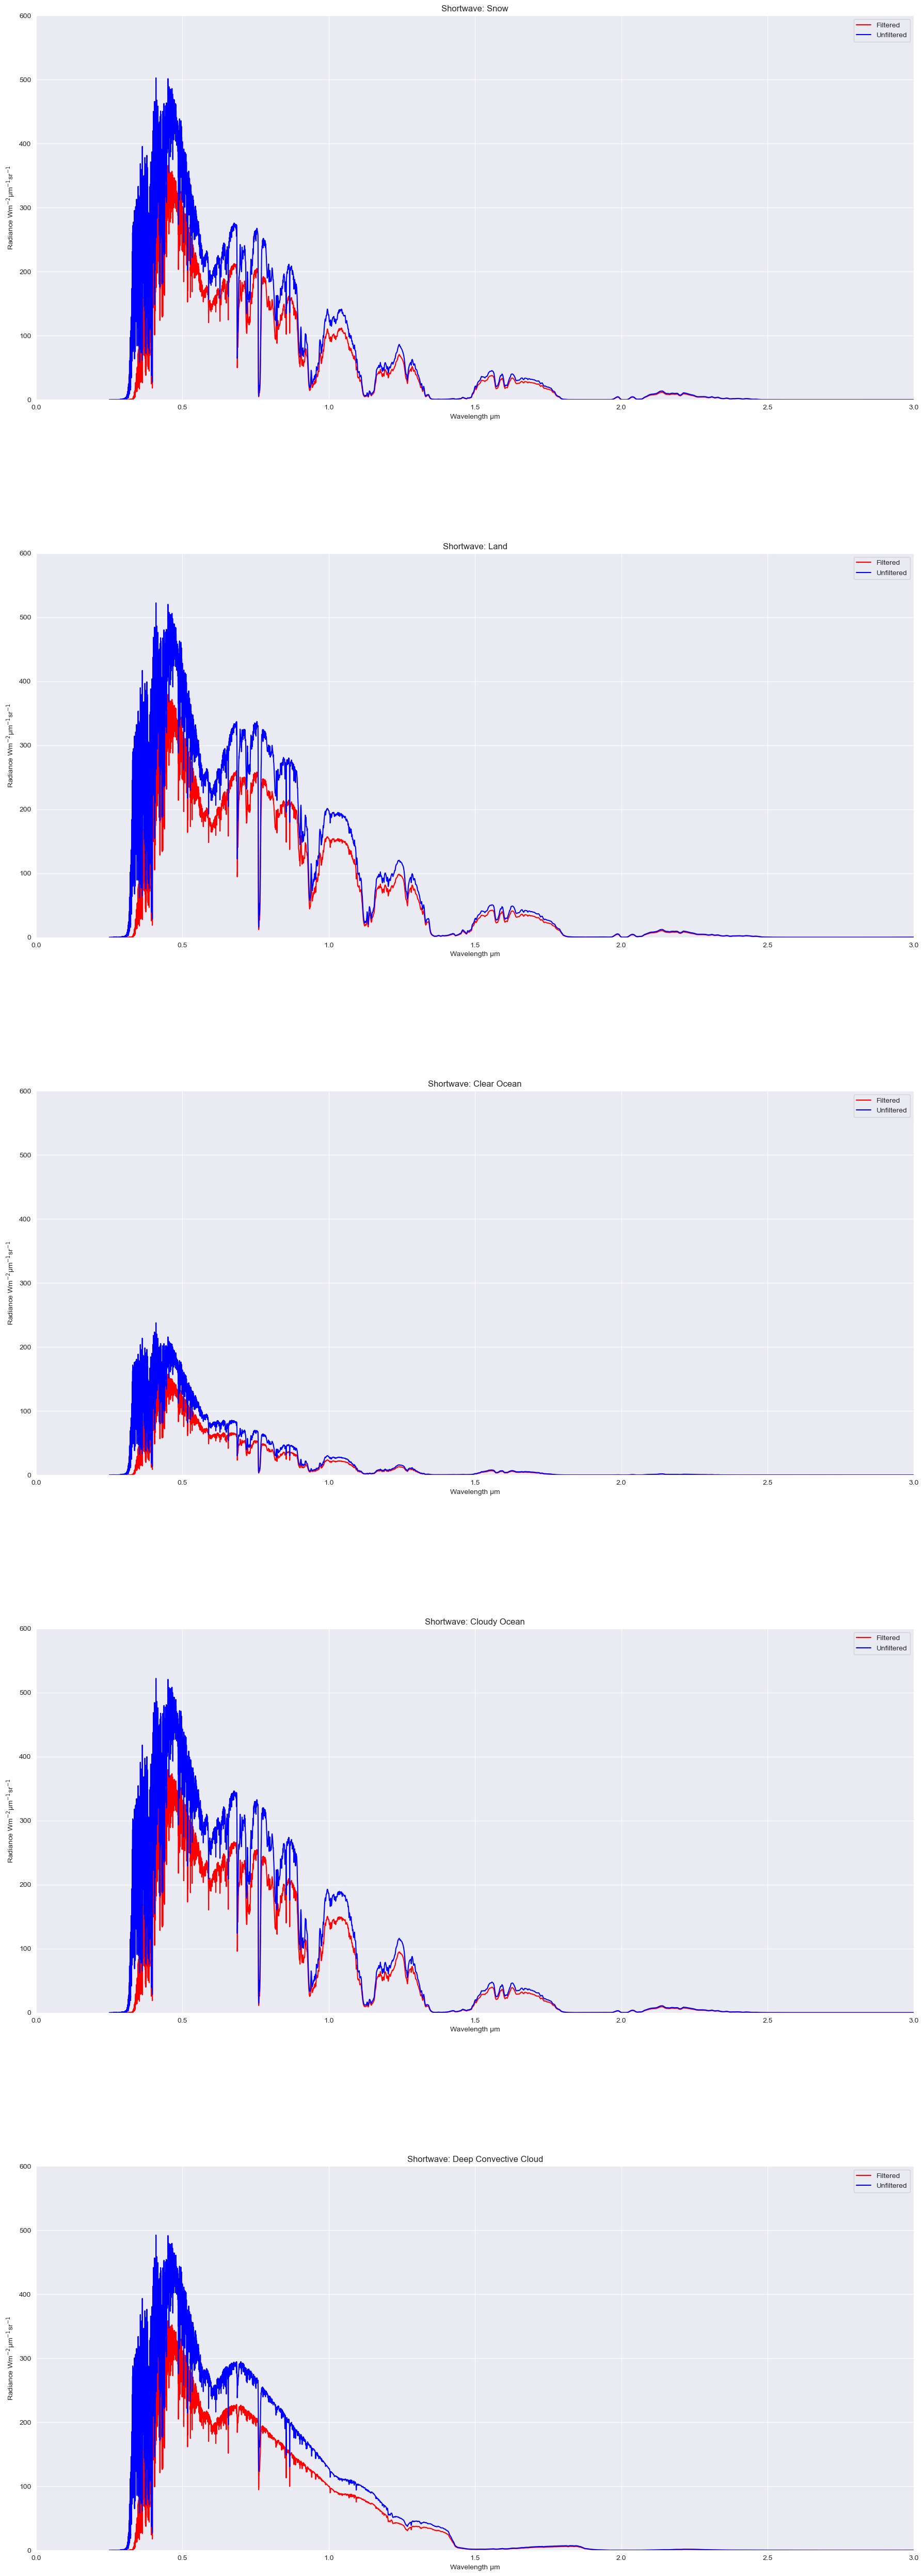

In [14]:
plot_sza(a00)

In [15]:
# plot_sza(a41)

In [16]:
# plot_sza(a60)

In [17]:
# plot_sza(a75)

In [18]:
# plot_sza(a85)

In [14]:
all_res = run_shortwave_regression_model(all_dataset, 100)

Index(['SZA', 'VZA', 'RAZ', 'Cloud', 'Shortwave Filtered Rads (Integrated)',
       'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9',
       'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object') Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')


In [15]:
all_res

{'Single MSE': 1.4209858823855115,
 'RMSE': 1.1920511240653697,
 'MAE': 0.3186874615866022,
 'Shortwave MSPE': 99.79611265203997,
 'CV RMSE': array([-7.15844268, -2.76372374, -0.63921087, -2.63548524, -3.17413055])}

In [36]:
np.sqrt(all_res["Single MSE"])

1.1920511240653697

In [14]:
all_dataset.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
       'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object')

In [98]:
all_dataset

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),...,M12,M13,M14,M15,I5,M16,Scaled Shortwave Filtered,Scaled Shortwave Unfiltered,Scaled Longwave Filtered,Scaled Longwave Unfiltered
0,Snow,0.000,0.000,0.0,0,0,307.528673,64.630148,223.024942,42.028651,...,0.004348,0.001302,0.000088,0.000138,0.000294,0.000190,0.461624,0.500871,0.492051,0.477688
1,Snow,0.000,0.000,0.0,1,1,308.989576,61.707542,224.234444,40.175852,...,0.013530,0.005802,0.000327,0.000176,0.000381,0.000226,0.464154,0.503278,0.453498,0.439632
2,Snow,0.000,0.000,0.0,1,2,307.570444,65.121000,222.758504,42.332800,...,0.003081,0.000960,0.000084,0.000111,0.000276,0.000193,0.461066,0.500940,0.498380,0.484079
3,Snow,0.000,0.000,0.0,1,3,367.808738,53.795463,271.419300,35.158965,...,0.347688,0.160067,0.012621,0.007502,0.010138,0.003258,0.562855,0.600195,0.349106,0.336606
4,Snow,0.000,0.000,0.0,1,4,323.988001,63.367576,236.683397,41.264825,...,0.377263,0.147548,0.011686,0.006478,0.008392,0.002541,0.490194,0.527991,0.476157,0.461247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,Clear Ocean,83.845,89.947,172.5,0,142,55.161028,68.826211,38.615647,44.514829,...,0.002860,0.000531,0.000014,0.000010,0.000013,0.000005,0.075878,0.085044,0.543784,0.532326
143,Clear Ocean,83.845,89.947,172.5,0,143,58.683832,68.796818,41.349000,44.500770,...,0.004841,0.000933,0.000018,0.000013,0.000016,0.000006,0.081595,0.090849,0.543491,0.531943
144,Clear Ocean,83.845,89.947,172.5,0,144,62.944481,68.745825,44.649744,44.474058,...,0.008280,0.001732,0.000027,0.000019,0.000023,0.000008,0.088500,0.097869,0.542935,0.531279
145,Clear Ocean,83.845,89.947,172.5,0,145,68.463058,68.719250,48.909934,44.461081,...,0.013350,0.003030,0.000036,0.000023,0.000027,0.000009,0.097411,0.106962,0.542665,0.530933


In [17]:
min(all_dataset["Shortwave Filtered Rads (Integrated)"]), max(all_dataset["Shortwave Filtered Rads (Integrated)"])

(2.341706313336201, 480.40057188125786)

In [18]:
min(all_dataset["Shortwave Unfiltered Rads (Integrated)"]), max(all_dataset["Shortwave Unfiltered Rads (Integrated)"])

(3.5472382110609804, 610.4526726464998)

In [23]:
min(all_dataset["Scaled Shortwave Filtered"]), max(all_dataset["Scaled Shortwave Filtered"])

(0.0, 1.0)

In [21]:
all_dataset.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
       'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Scaled Shortwave Filtered',
       'Scaled Shortwave Unfiltered', 'Scaled Longwave Filtered',
       'Scaled Longwave Unfiltered'],
      dtype='object')

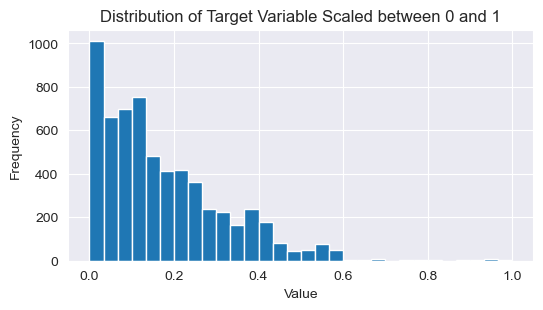

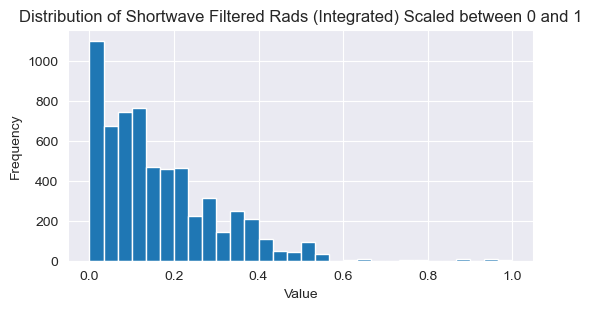

In [16]:
plt.figure(figsize=(6, 3))
plt.hist(all_dataset["Scaled Shortwave Unfiltered"], bins=30)
plt.title('Distribution of Target Variable Scaled between 0 and 1')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(6, 3))
plt.hist(all_dataset["Scaled Shortwave Filtered"], bins=30)
plt.title(f'Distribution of Shortwave Filtered Rads (Integrated) Scaled between 0 and 1')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

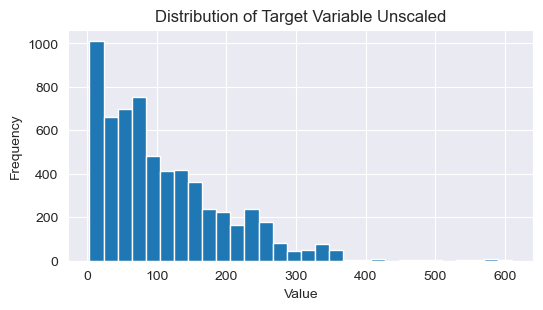

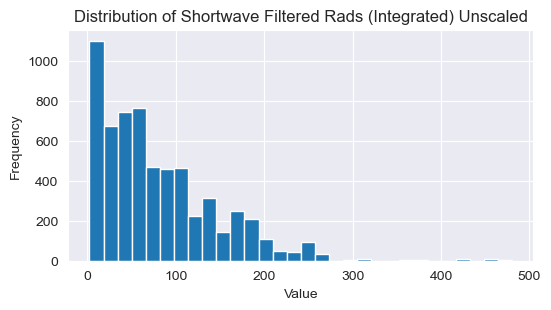

In [17]:
plt.figure(figsize=(6, 3))
plt.hist(all_dataset["Shortwave Unfiltered Rads (Integrated)"], bins=30)
plt.title('Distribution of Target Variable Unscaled')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(6, 3))
plt.hist(all_dataset["Shortwave Filtered Rads (Integrated)"], bins=30)
plt.title(f'Distribution of Shortwave Filtered Rads (Integrated) Unscaled')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

# START OF MAIN WORK

In [19]:
def add_noise_to_features(X: np.ndarray, noise_level: float, seed: int = 42):
    np.random.seed(seed)
    noise = np.random.normal(loc=0.0, scale=noise_level, size=X.shape)
    return X + noise


In [20]:
def run_shortwave_regression_model_scaled(dataset: pd.DataFrame, scaled: bool, rf: bool, v: bool, viirs_bands: bool, noised: bool, noise_level: float = 0.01, neurons: int = 100, tree_depth: int = 10):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    X, y = None, None

    columns_to_drop = ["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",
                      "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 
                      'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered', "Cloud",
                       'Scaled Shortwave Filtered',]

    # print(dataset.columns)
    
    if not viirs_bands:
        columns_to_drop.extend(['M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 
                              'I3', 'M10', 'M11', 'I4', 'M1', 'M2', 'M3', 'M4', 'I1'])

    if scaled:
        X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Filtered',
                                  'Shortwave Unfiltered Rads (Integrated)', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16',]).reset_index(drop=True)

    else:
        X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                   'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)

    params = {'bootstrap': True,
            'max_depth': 12,
            'max_features': None,
            'max_samples': 0.8,
            'min_samples_leaf': 2,
            'min_samples_split': 5,
            'n_estimators': 100}


    if rf:
        regression_model = RandomForestRegressor(**params)
    else:
        regression_model = LinearRegression()
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
    ret["Mean_Absolute_Percentage_Error"] = mape
    ret["Root_Mean_Squared_Error"] = rmse
    ret["Mean_Absolute_Error"] = mae
    ret["Accuracy"] = 100 - mape
    # ret["MAEP"] = mae_percentage

    # tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    # ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(regression_model, X, y, cv=5, scoring="r2")
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["R_Squared"] = r2_score(y_test, y_pred)

    ret["Model"] = regression_model

    return [ret, y_pred, y_test]

In [21]:
def run_MLP(dataset: pd.DataFrame, scaled: bool, v: bool, noised: bool, noise_level: float = 0.01, neurons: tuple = (8, 4), max_iter: int = 500):

    ret = {}
    X, y = None, None
    if scaled:
        X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered',
                                  'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                                  'M1', 'M2', 'M3', 'M4', 'I1',]).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Filtered',
                                  'Shortwave Unfiltered Rads (Integrated)', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    else:
        X = dataset.drop(columns=["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",  "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Filtered', 'Scaled Shortwave Unfiltered',
                                  'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                                  'M1', 'M2', 'M3', 'M4', 'I1',]).reset_index(drop=True)

        # in y we should only have the unfiltered ground truth data
        y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                   'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                   'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                   'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)


    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)

    MLP = MLPRegressor(
        # hidden_layer_sizes=(32, 16, 8), # best for scaled (8, 4)
        hidden_layer_sizes=neurons,
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size='auto',
        learning_rate='adaptive',
        max_iter=max_iter,
        random_state=42
    )

    MLP.fit(X_train, y_train)

    # Evaluate
    train_accuracy = MLP.score(X_train, y_train)
    test_accuracy = MLP.score(X_test, y_test)

    y_pred = MLP.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    cv_scores = cross_val_score(MLP, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(MLP, X, y, cv=5, scoring="r2")

    ret["Mean_Absolute_Error"] = mae
    ret["Train_Accuracy"] = train_accuracy
    ret["Test_Accuracy"] = test_accuracy
    ret["Mean_Squared_Error"] = mse
    ret["R_Squared"] = r2
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["Model"] = MLP

    return [ret, y_pred, y_test]


In [22]:
def run_shortwave_viirs_model(dataset: pd.DataFrame, v: bool, noised: bool, noise_level: float = 0.01, neurons: int = 100, tree_depth: int = 10):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    X, y = None, None

    columns_to_drop = ["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)", 
                      "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 
                      'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered', "Cloud"]
    
    # if not viirs_bands:
    #     columns_to_drop.extend(['M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 
    #                           'I3', 'M10', 'M11', 'I4', 'M1', 'M2', 'M3', 'M4', 'I1'])

    
    X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)

    
    regression_model = RandomForestRegressor(random_state=42)
    param_grid = {
        'n_estimators': [25, 50, 75, 100, 200, 400, 500, 600],
        'max_depth': [2, 4, 6, 8, 10, 12, 15],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4, 6, 8],
        'max_features': ['sqrt', 'log2'],
        'max_samples': [0.7, 0.8, 0.9]
    }
    grid_search = GridSearchCV(
        estimator=regression_model,
        param_grid=param_grid,
        cv=5,  # 5-fold cross-validation
        scoring='neg_root_mean_squared_error',  # Optimize for RMSE
        n_jobs=-1,  # Use all available cores
        verbose=1
    )

    grid_search.fit(X, y)
    regression_model.fit(X_train, y_train)

    y_pred = regression_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100

    ret["Mean_Absolute_Percentage_Error"] = mape
    ret["Root_Mean_Squared_Error"] = rmse
    ret["Mean_Absolute_Error"] = mae
    ret["Accuracy"] = 100 - mape
    # ret["MAEP"] = mae_percentage

    # tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    # ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(regression_model, X, y, cv=5, scoring="r2")
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["R_Squared"] = r2_score(y_test, y_pred)

    ret["GridSearch_Params"] = grid_search.best_params_
    ret["GridSearch_RMSE"] = -grid_search.best_params_

    ret["Model"] = regression_model

    return [ret, y_pred, y_test]

In [23]:
def compare_MLP_neurons(dataset: pd.DataFrame, neurons: list = ((2), (2,2), (4,2), (8,4), (16, 8), (32, 16, 8))):
    # unscaled data
    mlp_neuron_results = [run_MLP(dataset=dataset, scaled=False, v=False, neurons=n, noised=False) for n in neurons]
    return dict(zip(neurons, mlp_neuron_results))

def comapare_MLP_max_iter(dataset: pd.DataFrame, max_iter: list = (5, 10, 50, 100, 250, 500)):
    mlp_max_iter_results = [run_MLP(dataset=dataset, scaled=False, v=False,  noised=False, max_iter=mx) for mx in max_iter]
    return dict(zip(max_iter, mlp_max_iter_results))

def compare_tree_depth(dataset: pd.DataFrame, tree_depth: list = (1,2,3,4,5,6,7,8,9,10)):
    tree_depth_res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False, viirs_bands=False, noised=False, neurons=100, tree_depth=td) for td in tree_depth]
    return dict(zip(tree_depth, tree_depth_res))

def compare_tree_estimators(dataset: pd.DataFrame, estimators: list = (1,5,10,25,50,100)):
    tree_est_res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False, viirs_bands=False, noised=False, neurons=est, tree_depth=10) for est in estimators]
    return dict(zip(estimators, tree_est_res))

def compare_tree_td_est(dataset: pd.DataFrame, tree_depth: list = (1,2,3,4,5,6,7,8,9,10), estimators: list = (1,5,10,25,50,100)):
    vars = [(td, est) for td in tree_depth for est in estimators]
    res = [run_shortwave_regression_model_scaled(dataset=dataset,scaled=False, rf=True, v=False, viirs_bands=False, noised=False, neurons=est, tree_depth=td) for td, est in vars]
    return dict(zip(vars, res))

def compare_mlp_neurons_iters(dataset: pd.DataFrame, neurons: list = ((2), (2,2), (4,2), (8,4), (16, 8), (32, 16, 8)), max_iter: list = (5, 10, 50, 100, 250, 500)):
    vars = [(n, mx) for n in neurons for mx in max_iter]
    res = [run_MLP(dataset=dataset, scaled=False, v=False,  noised=False, neurons=n, max_iter=mx) for n, mx in vars]
    return dict(zip(vars, res))

def compare_noise_mlp(dataset: pd.DataFrame, noise:list = [0, 0.01, 0.1, 0.5, 1.0, 10.0, 20.0, 50.0, 100.0]):
    res = [run_MLP(dataset=dataset, scaled=False, v=False, noised=True, noise_level=nl) for nl in noise]
    return dict(zip(noise, res))

def compare_noise_tree(dataset: pd.DataFrame, noise:list = [0, 0.01, 0.1, 0.5, 1.0, 10.0, 20.0, 50.0, 100.0]):
    res = [run_shortwave_regression_model_scaled(dataset=dataset, scaled=False, v=False, rf=True, viirs_bands=False, noised=True, noise_level=nl) for nl in noise]
    return dict(zip(noise, res))



In [59]:
mlp_neuron_comparison = compare_MLP_neurons(all_dataset)
mlp_neuron_comparison

{2: [{'Mean_Absolute_Error': 1.2343687998135853,
   'Train_Accuracy': 0.9995102773170298,
   'Test_Accuracy': 0.9995049211614154,
   'Mean_Squared_Error': 4.083748474734383,
   'R_Squared': 0.9995049211614154,
   'Cross_Validated_Root_Mean_Squared_Error': array([2.84719555, 2.78983213, 0.88872214, 2.91879486, 1.68933922]),
   'Cross_Validated_R_Squared': array([0.99874523, 0.99918573, 0.99972442, 0.9988794 , 0.99944855]),
   'Model': MLPRegressor(alpha=0.001, hidden_layer_sizes=2, learning_rate='adaptive',
                max_iter=500, random_state=42)},
  array([ 51.10725826,  88.42800497, 344.56185357, ...,  21.45295216,
          17.46859718, 127.33420025]),
  array([[ 50.31396922],
         [ 86.83895218],
         [348.78264058],
         ...,
         [ 20.90997346],
         [ 16.7682088 ],
         [127.59956971]])],
 (2,
  2): [{'Mean_Absolute_Error': 99.67836945961535,
   'Train_Accuracy': -1.1813534354010131,
   'Test_Accuracy': -1.1957463987987205,
   'Mean_Squared_Error': 

In [42]:
mlp_max_iter_comparison = comapare_MLP_max_iter(all_dataset)
mlp_max_iter_comparison

{5: [{'Mean_Absolute_Error': 51.19328611778193,
   'Train_Accuracy': 0.3555407622134106,
   'Test_Accuracy': 0.351392733305693,
   'Mean_Squared_Error': 5350.155833033391,
   'R_Squared': 0.351392733305693,
   'Cross_Validated_Root_Mean_Squared_Error': array([103.6990759 ,  88.32518562,  49.11241776,  57.03171028,
           46.81352781]),
   'Cross_Validated_R_Squared': array([-0.66448658,  0.18382756,  0.15840105,  0.57216363,  0.57653727]),
   'Model': MLPRegressor(alpha=0.001, hidden_layer_sizes=(8, 4), learning_rate='adaptive',
                max_iter=5, random_state=42)},
  array([ 39.8459039 ,  45.19593575, 144.04774739, ...,  45.41232115,
          43.366823  ,  68.78624318]),
  array([[ 50.31396922],
         [ 86.83895218],
         [348.78264058],
         ...,
         [ 20.90997346],
         [ 16.7682088 ],
         [127.59956971]])],
 10: [{'Mean_Absolute_Error': 21.791935926896027,
   'Train_Accuracy': 0.9040686622575959,
   'Test_Accuracy': 0.9060599659400626,
   'Mea

In [43]:
tree_depth_comparison = compare_tree_depth(all_dataset)
tree_depth_comparison

{1: [{'Mean_Absolute_Percentage_Error': 0.7141000082270945,
   'Root_Mean_Squared_Error': 1.1780295043697953,
   'Mean_Absolute_Error': 0.5527638102675143,
   'Accuracy': 99.28589999177291,
   'Cross_Validated_Root_Mean_Squared_Error': array([5.88774816, 2.32321476, 0.90174916, 2.28256487, 2.65258031]),
   'Cross_Validated_R_Squared': array([0.99450636, 0.99949376, 0.99970983, 0.99923552, 0.99868713]),
   'R_Squared': 0.9998317605989226,
   'Model': RandomForestRegressor(max_depth=12, max_features=None, max_samples=0.8,
                         min_samples_leaf=2, min_samples_split=5)},
  array([ 49.95108604,  86.74156755, 348.8084943 , ...,  21.24860224,
          16.93432723, 127.74856334]),
  array([[ 50.31396922],
         [ 86.83895218],
         [348.78264058],
         ...,
         [ 20.90997346],
         [ 16.7682088 ],
         [127.59956971]])],
 2: [{'Mean_Absolute_Percentage_Error': 0.7093827438768108,
   'Root_Mean_Squared_Error': 1.4753899382230835,
   'Mean_Absolute_Er

In [44]:
"""
For the below est comparison use different tree depths as well just to show how to build up the model
"""

'\nFor the below est comparison use different tree depths as well just to show how to build up the model\n'

In [45]:
tree_est_comparison = compare_tree_estimators(all_dataset)
tree_est_comparison

{1: [{'Mean_Absolute_Percentage_Error': 0.7129991795836758,
   'Root_Mean_Squared_Error': 1.3178093173357077,
   'Mean_Absolute_Error': 0.5622183507521551,
   'Accuracy': 99.28700082041632,
   'Cross_Validated_Root_Mean_Squared_Error': array([5.87231016, 2.25635111, 0.91652758, 2.62397106, 2.93458714]),
   'Cross_Validated_R_Squared': array([0.99490712, 0.99945612, 0.99971135, 0.99910127, 0.99850108]),
   'R_Squared': 0.9997894668318736,
   'Model': RandomForestRegressor(max_depth=12, max_features=None, max_samples=0.8,
                         min_samples_leaf=2, min_samples_split=5)},
  array([ 50.0172014 ,  86.77040554, 348.93763094, ...,  21.20637471,
          16.93046104, 127.82256874]),
  array([[ 50.31396922],
         [ 86.83895218],
         [348.78264058],
         ...,
         [ 20.90997346],
         [ 16.7682088 ],
         [127.59956971]])],
 5: [{'Mean_Absolute_Percentage_Error': 0.7063075239614565,
   'Root_Mean_Squared_Error': 1.24606842504995,
   'Mean_Absolute_Erro

In [46]:
all_td_est_comparison = compare_tree_td_est(all_dataset)
all_td_est_comparison

{(1,
  1): [{'Mean_Absolute_Percentage_Error': 0.7091439474583225,
   'Root_Mean_Squared_Error': 1.1340786313752595,
   'Mean_Absolute_Error': 0.5466588125157065,
   'Accuracy': 99.29085605254167,
   'Cross_Validated_Root_Mean_Squared_Error': array([5.86341269, 2.21503404, 0.8988009 , 2.49123982, 2.60316931]),
   'Cross_Validated_R_Squared': array([0.99455961, 0.99944519, 0.99971623, 0.99918952, 0.99828007]),
   'R_Squared': 0.9998440800406022,
   'Model': RandomForestRegressor(max_depth=12, max_features=None, max_samples=0.8,
                         min_samples_leaf=2, min_samples_split=5)}, array([ 50.01981525,  86.85670099, 348.87733432, ...,  21.22525999,
          16.91129629, 127.7658289 ]), array([[ 50.31396922],
         [ 86.83895218],
         [348.78264058],
         ...,
         [ 20.90997346],
         [ 16.7682088 ],
         [127.59956971]])],
 (1,
  5): [{'Mean_Absolute_Percentage_Error': 0.7121257345969,
   'Root_Mean_Squared_Error': 1.243842619433797,
   'Mean_Absol

In [47]:
all_mlp_neurons_iters_comparison = compare_mlp_neurons_iters(all_dataset)
all_mlp_neurons_iters_comparison

{(2,
  5): [{'Mean_Absolute_Error': 107.9245584224196,
   'Train_Accuracy': -1.1793629776592365,
   'Test_Accuracy': -1.1645072338434983,
   'Mean_Squared_Error': 17854.33435214457,
   'R_Squared': -1.1645072338434983,
   'Cross_Validated_Root_Mean_Squared_Error': array([177.97482037, 145.85344415, 113.55987316, 112.50267245,
           89.4796536 ]),
   'Cross_Validated_R_Squared': array([-3.90283924, -1.22559524, -3.49958391, -0.66483268, -0.54710944]),
   'Model': MLPRegressor(alpha=0.001, hidden_layer_sizes=2, learning_rate='adaptive',
                max_iter=5, random_state=42)}, array([ -0.78036452,  -0.78036452,  49.70549077, ..., -29.12987186,
          -3.57958008,  -0.78036452]), array([[ 50.31396922],
         [ 86.83895218],
         [348.78264058],
         ...,
         [ 20.90997346],
         [ 16.7682088 ],
         [127.59956971]])],
 (2,
  10): [{'Mean_Absolute_Error': 62.91471771966248,
   'Train_Accuracy': 0.13067318854768717,
   'Test_Accuracy': 0.128731388314427

In [48]:
all_mlp_noise_comparison = compare_noise_mlp(all_dataset)
all_mlp_noise_comparison

{0: [{'Mean_Absolute_Error': 1.4142247221960287,
   'Train_Accuracy': 0.9993642017730769,
   'Test_Accuracy': 0.9993469587453174,
   'Mean_Squared_Error': 5.386730395048138,
   'R_Squared': 0.9993469587453174,
   'Cross_Validated_Root_Mean_Squared_Error': array([2.9224335 , 3.28397799, 0.74450014, 3.26972216, 2.01928419]),
   'Cross_Validated_R_Squared': array([0.99867804, 0.99887173, 0.9998066 , 0.99859374, 0.99921211]),
   'Model': MLPRegressor(alpha=0.001, hidden_layer_sizes=(8, 4), learning_rate='adaptive',
                max_iter=500, random_state=42)},
  array([ 50.28241833,  87.826602  , 343.35429608, ...,  21.17514442,
          16.47522386, 126.40504149]),
  array([[ 50.31396922],
         [ 86.83895218],
         [348.78264058],
         ...,
         [ 20.90997346],
         [ 16.7682088 ],
         [127.59956971]])],
 0.01: [{'Mean_Absolute_Error': 1.4133711515519038,
   'Train_Accuracy': 0.9993643564166825,
   'Test_Accuracy': 0.9993471964176103,
   'Mean_Squared_Error': 

In [49]:
all_tree_noise_comparison = compare_noise_tree(all_dataset)
all_tree_noise_comparison

{0: [{'Mean_Absolute_Percentage_Error': 0.7094945996085609,
   'Root_Mean_Squared_Error': 1.1121218654747835,
   'Mean_Absolute_Error': 0.5424557844725311,
   'Accuracy': 99.29050540039144,
   'Cross_Validated_Root_Mean_Squared_Error': array([5.8208961 , 2.41340054, 0.90221674, 2.69363691, 2.56743058]),
   'Cross_Validated_R_Squared': array([0.99459684, 0.99941639, 0.9997124 , 0.99916761, 0.99855459]),
   'R_Squared': 0.9998500590917508,
   'Model': RandomForestRegressor(max_depth=12, max_features=None, max_samples=0.8,
                         min_samples_leaf=2, min_samples_split=5)},
  array([ 50.0175812 ,  86.70474751, 349.16779284, ...,  21.20502261,
          16.91800724, 127.73822968]),
  array([[ 50.31396922],
         [ 86.83895218],
         [348.78264058],
         ...,
         [ 20.90997346],
         [ 16.7682088 ],
         [127.59956971]])],
 0.01: [{'Mean_Absolute_Percentage_Error': 0.7382850984107373,
   'Root_Mean_Squared_Error': 1.3497946382227792,
   'Mean_Absolute

In [19]:
all_unscaled_res_linear_regression = run_shortwave_regression_model_scaled(all_dataset, scaled=False, rf=False, v=True, viirs_bands=False, noised=False, neurons=100,)
all_unscaled_res_linear_regression[0]

Input Features Index(['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)'], dtype='object'), Prediction feature Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')


{'Mean_Absolute_Percentage_Error': 1.7907052787381477,
 'Root_Mean_Squared_Error': 2.3225999346276565,
 'Mean_Absolute_Error': 1.3071459600243585,
 'Accuracy': 98.20929472126186,
 'Cross_Validated_Root_Mean_Squared_Error': array([3.0656275 , 3.35629646, 0.95115663, 3.32088313, 1.93832164]),
 'Cross_Validated_R_Squared': array([0.99854531, 0.99882149, 0.99968433, 0.99854939, 0.99927402]),
 'R_Squared': 0.9993460204062952,
 'Model': LinearRegression()}

In [24]:
all_unscaled_res_random_forest = run_shortwave_regression_model_scaled(all_dataset, scaled=False, rf=True, v=True, viirs_bands=True, noised=False, neurons=100, tree_depth=10)
all_unscaled_res_random_forest[0]

Input Features Index(['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object'), Prediction feature Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')


{'Mean_Absolute_Percentage_Error': 0.4787859945055657,
 'Root_Mean_Squared_Error': 1.4441898240760693,
 'Mean_Absolute_Error': 0.3851323110066441,
 'Accuracy': 99.52121400549443,
 'Cross_Validated_Root_Mean_Squared_Error': array([6.11725879, 1.84875942, 0.64511761, 3.15843401, 3.2422568 ]),
 'Cross_Validated_R_Squared': array([0.99590294, 0.99946237, 0.99985443, 0.99890278, 0.99723372]),
 'R_Squared': 0.9997471494286377,
 'Model': RandomForestRegressor(max_depth=12, max_features=None, max_samples=0.8,
                       min_samples_leaf=2, min_samples_split=5)}

In [52]:
all_unscaled_mlp = run_MLP(all_dataset, False, True, False,(2))
all_unscaled_mlp[0]

Input Features Index(['SZA', 'VZA', 'RAZ', 'Cloud', 'Shortwave Filtered Rads (Integrated)'], dtype='object'), Prediction feature Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')


{'Mean_Absolute_Error': 1.4142247221960287,
 'Train_Accuracy': 0.9993642017730769,
 'Test_Accuracy': 0.9993469587453174,
 'Mean_Squared_Error': 5.386730395048138,
 'R_Squared': 0.9993469587453174,
 'Cross_Validated_Root_Mean_Squared_Error': array([2.9224335 , 3.28397799, 0.74450014, 3.26972216, 2.01928419]),
 'Cross_Validated_R_Squared': array([0.99867804, 0.99887173, 0.9998066 , 0.99859374, 0.99921211]),
 'Model': MLPRegressor(alpha=0.001, hidden_layer_sizes=(8, 4), learning_rate='adaptive',
              max_iter=500, random_state=42)}

In [53]:
viirs_results = run_shortwave_regression_model_scaled(dataset=all_dataset, scaled=False, rf=True, v=True, viirs_bands=True, noised=False)
viirs_results

Input Features Index(['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object'), Prediction feature Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')


[{'Mean_Absolute_Percentage_Error': 0.47730900408164706,
  'Root_Mean_Squared_Error': 1.3834577278693758,
  'Mean_Absolute_Error': 0.3811067631062337,
  'Accuracy': 99.52269099591835,
  'Cross_Validated_Root_Mean_Squared_Error': array([5.29610138, 2.07924191, 0.64523783, 3.39210963, 3.17386944]),
  'Cross_Validated_R_Squared': array([0.99589391, 0.99953329, 0.99984929, 0.99861396, 0.99759118]),
  'R_Squared': 0.999767968383615,
  'Model': RandomForestRegressor(max_depth=12, max_features=None, max_samples=0.8,
                        min_samples_leaf=2, min_samples_split=5)},
 array([ 50.54198765,  86.61942369, 348.84990695, ...,  20.81632895,
         16.8883274 , 127.60553504]),
 array([[ 50.31396922],
        [ 86.83895218],
        [348.78264058],
        ...,
        [ 20.90997346],
        [ 16.7682088 ],
        [127.59956971]])]

In [54]:
viirs_grid_search_results = run_shortwave_viirs_model(dataset=all_dataset, v=True, noised=False,)
viirs_grid_search_results

Input Features Index(['SZA', 'VZA', 'RAZ', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6',
       'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14',
       'M15', 'I5', 'M16', 'Scaled Shortwave Filtered'],
      dtype='object'), Prediction feature Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')
Fitting 5 folds for each of 1620 candidates, totalling 8100 fits


/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

KeyboardInterrupt: 

# START OF ERROR ANALYSIS

In [46]:
all_unscaled_res_random_forest[0]["Model"]

RandomForestRegressor(max_depth=12, max_features=None, max_samples=0.8,
                      min_samples_leaf=2, min_samples_split=5)

In [43]:
type(all_unscaled_res_random_forest[0]["Model"].estimators_), len(all_unscaled_res_random_forest[0]["Model"].estimators_)

(list, 100)

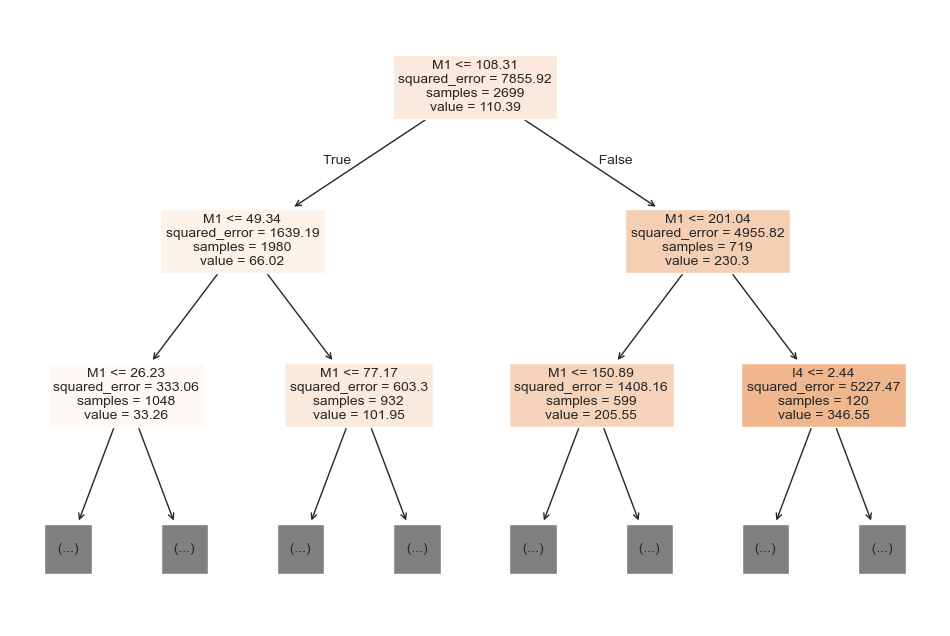

In [94]:
plt.figure(figsize=(12, 8))
plot_tree(all_unscaled_res_random_forest[0]["Model"].estimators_[0],
          feature_names=['SZA', 'VZA', 'RAZ', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5',
                         'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11',
                         'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Scaled Shortwave Filtered'],
          filled=True,
          max_depth=2,
          fontsize=10,
          proportion=False,
          precision=2)

plt.savefig('./imgs/tree.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
# plot_ml_est(snow_est_tests)

In [15]:
# plot_ml_est(land_est_tests)

In [46]:
# clear_est_tests = estimator_testing("land", clear_dataset)
# clear_est_tests

In [16]:
# plot_ml_est(clear_est_tests)

Block diagram + Physical explanation: Start with a clear diagram showing the deterministic nature of the problem. Emphasize that you're essentially "inverting" a known filter operation using SZA/VZA/RAZ and filtered values to recover unfiltered data - this isn't a typical noisy prediction problem.

Truth vs. Prediction visualizations:

Scatter plots of predicted vs. ground truth values (should fall very close to y=x line)

Residual plots (prediction - ground truth) to show error distribution

Histogram of percentage errors (pred - truth)/truth × 100%


In [36]:
all_unscaled_y_pred_random_forest = np.squeeze(all_unscaled_res_random_forest[1])
all_unscaled_y_true_random_forest = np.squeeze(all_unscaled_res_random_forest[2])
# all_unscaled_y_true_random_forest = all_unscaled_res_random_forest[2]["Shortwave Unfiltered Rads (Integrated)"]
all_unscaled_residuals_random_forest = all_unscaled_y_pred_random_forest - all_unscaled_y_true_random_forest

np.shape(all_unscaled_y_pred_random_forest), np.shape(all_unscaled_y_true_random_forest), np.shape(all_unscaled_residuals_random_forest)

((1239,), (1239,), (1239,))

In [77]:
all_unscaled_y_pred_linear_regression = np.squeeze(all_unscaled_res_linear_regression[1])
all_unscaled_y_true_linear_regression = np.squeeze(all_unscaled_res_linear_regression[2])
all_unscaled_residuals_linear_regression = all_unscaled_y_pred_linear_regression - all_unscaled_y_true_linear_regression

np.shape(all_unscaled_y_pred_linear_regression), np.shape(all_unscaled_y_true_linear_regression), np.shape(all_unscaled_residuals_linear_regression)

((1239,), (1239,), (1239,))

In [78]:
all_unscaled_y_pred_mlp = np.squeeze(all_unscaled_mlp[1])
all_unscaled_y_true_mlp = np.squeeze(all_unscaled_mlp[2])
all_unscaled_residuals_mlp = all_unscaled_y_pred_mlp - all_unscaled_y_true_mlp

np.shape(all_unscaled_y_pred_mlp), np.shape(all_unscaled_y_true_mlp), np.shape(all_unscaled_residuals_mlp)

((1239,), (1239,), (1239,))

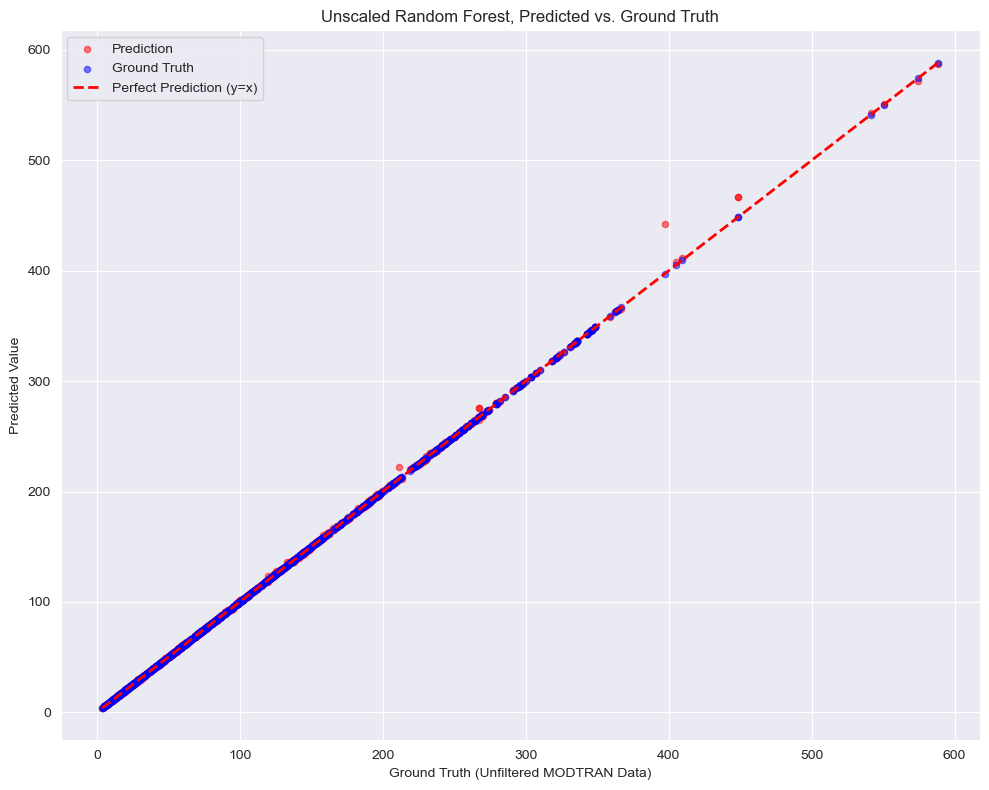

In [79]:
## Ground truth v predictions
fig, ax = plt.subplots(figsize=(10, 8))
# scatter = ax.scatter(all_unscaled_y_true_random_forest, all_unscaled_y_pred_random_forest, alpha=0.5, s=20)

# Plot predictions as orange crosses
ax.scatter(all_unscaled_y_true_random_forest, all_unscaled_y_pred_random_forest,
           alpha=0.5, s=20, color='red', label='Prediction')

ax.scatter(all_unscaled_y_true_random_forest, all_unscaled_y_true_random_forest,
           alpha=0.5, s=20, color='blue', label='Ground Truth')
# Add perfect prediction line (y=x)
line_x = np.linspace(all_unscaled_y_true_random_forest.min(), all_unscaled_y_true_random_forest.max(), 100)
line_y = line_x
ax.plot(line_x, line_y, 'r--', linewidth=2, label='Perfect Prediction (y=x)')
ax.set_xlabel('Ground Truth (Unfiltered MODTRAN Data)')
ax.set_ylabel('Predicted Value')
ax.set_title(f'Unscaled Random Forest, Predicted vs. Ground Truth')
ax.legend()
fig.tight_layout()

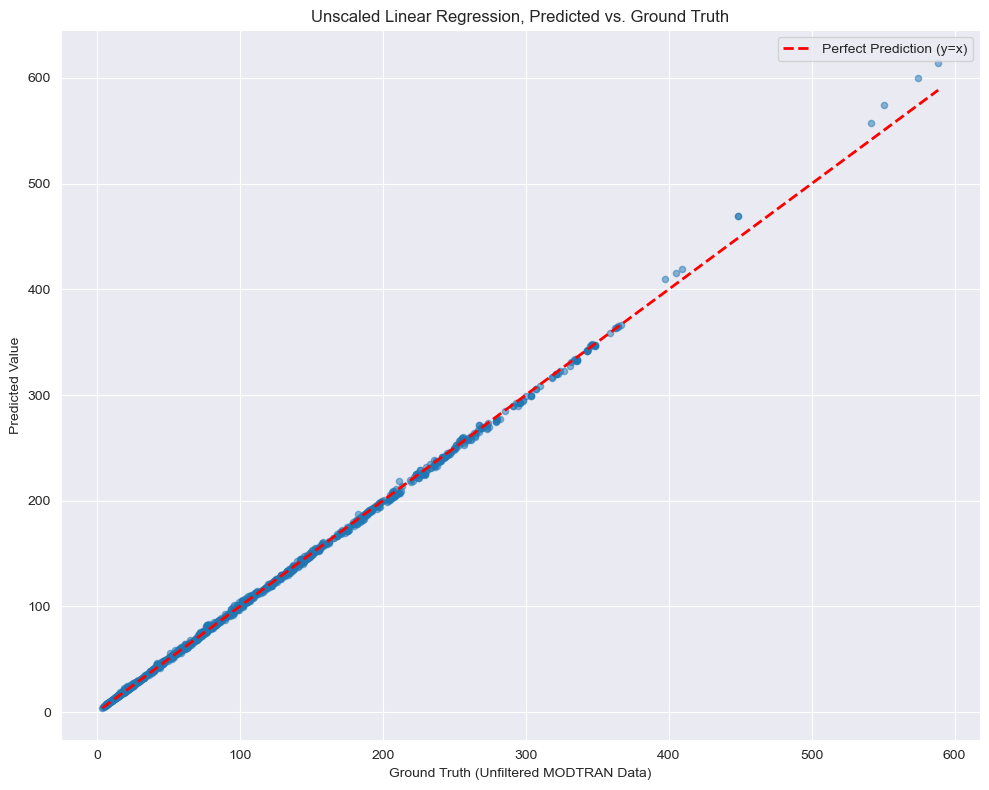

In [80]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(all_unscaled_y_true_linear_regression, all_unscaled_y_pred_linear_regression, alpha=0.5, s=20)
# Add perfect prediction line (y=x)
line_x = np.linspace(all_unscaled_y_true_linear_regression.min(), all_unscaled_y_true_linear_regression.max(), 100)
line_y = line_x
ax.plot(line_x, line_y, 'r--', linewidth=2, label='Perfect Prediction (y=x)')
ax.set_xlabel('Ground Truth (Unfiltered MODTRAN Data)')
ax.set_ylabel('Predicted Value')
ax.set_title(f'Unscaled Linear Regression, Predicted vs. Ground Truth')
ax.legend()
fig.tight_layout()

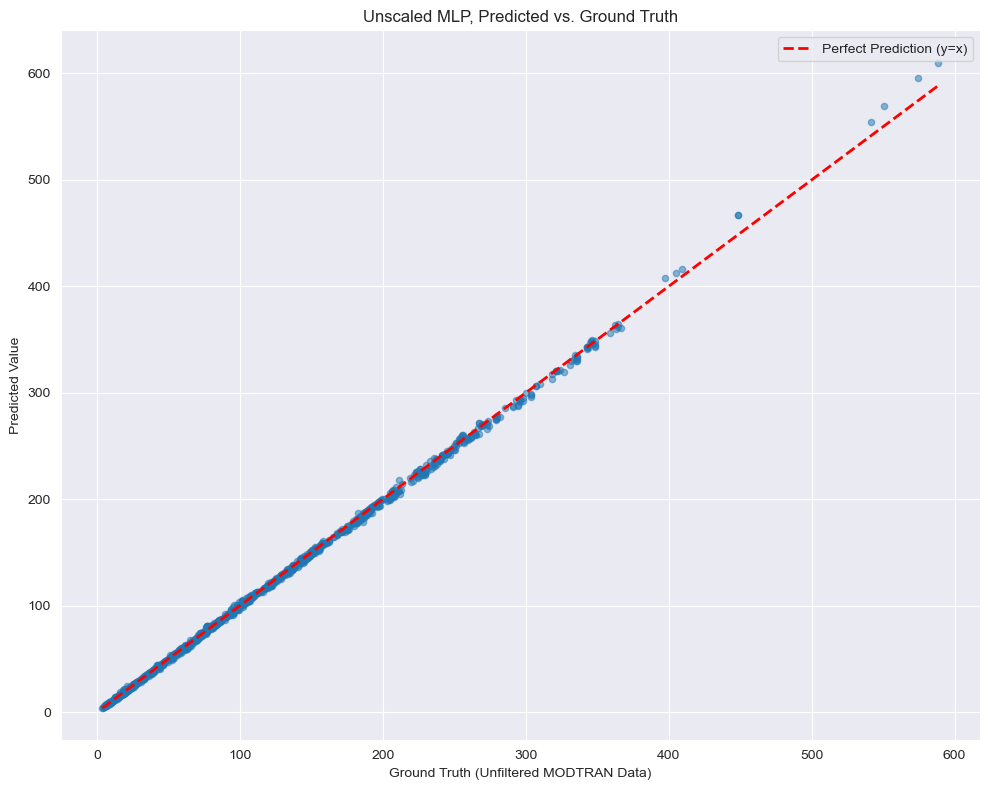

In [81]:
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(all_unscaled_y_true_mlp, all_unscaled_y_pred_mlp, alpha=0.5, s=20)
# Add perfect prediction line (y=x)
line_x = np.linspace(all_unscaled_y_true_mlp.min(), all_unscaled_y_true_mlp.max(), 100)
line_y = line_x
ax.plot(line_x, line_y, 'r--', linewidth=2, label='Perfect Prediction (y=x)')
ax.set_xlabel('Ground Truth (Unfiltered MODTRAN Data)')
ax.set_ylabel('Predicted Value')
ax.set_title(f'Unscaled MLP, Predicted vs. Ground Truth')
ax.legend()
fig.tight_layout()

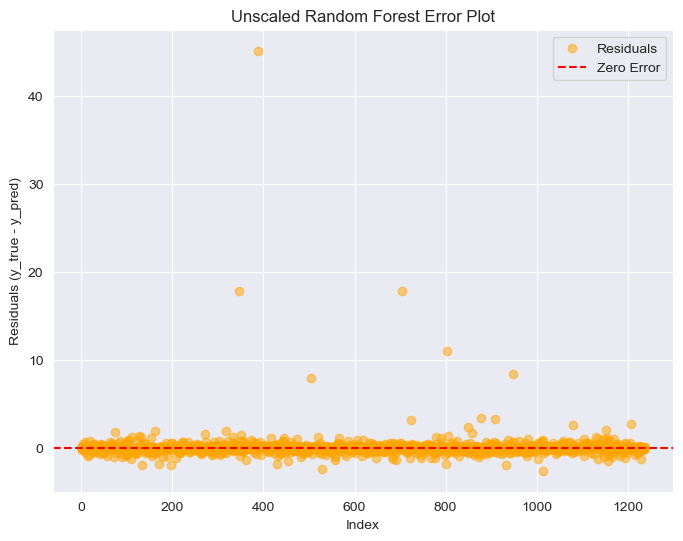

In [82]:
plt.figure(figsize=(8, 6))
plt.scatter(range(len(all_unscaled_residuals_random_forest)), all_unscaled_residuals_random_forest, alpha=0.5, color='orange', label='Residuals')
plt.axhline(0, color='red', linestyle='--', label='Zero Error')
plt.xlabel('Index')
plt.ylabel('Residuals (y_true - y_pred)')
plt.title('Unscaled Random Forest Error Plot')
plt.legend()
plt.show()

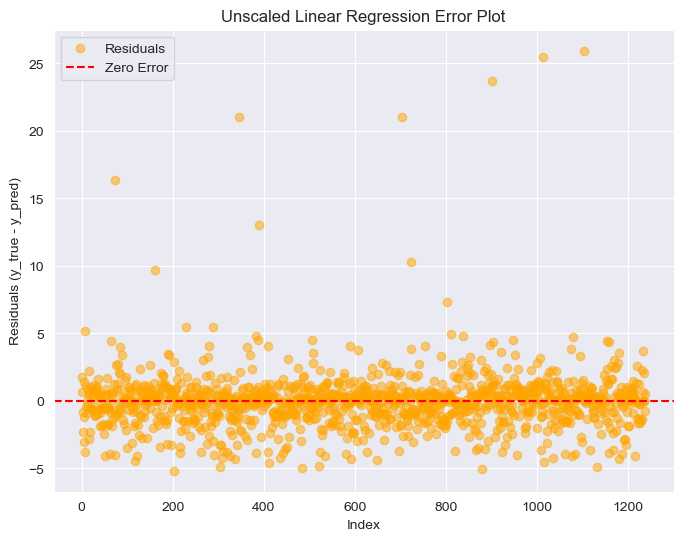

In [95]:
plt.figure(figsize=(8, 6))
plt.scatter(range(len(all_unscaled_residuals_linear_regression)), all_unscaled_residuals_linear_regression, alpha=0.5, color='orange', label='Residuals')
plt.axhline(0, color='red', linestyle='--', label='Zero Error')
plt.xlabel('Index')
plt.ylabel('Residuals (y_true - y_pred)')
plt.title('Unscaled Linear Regression Error Plot')
plt.legend()
plt.show()

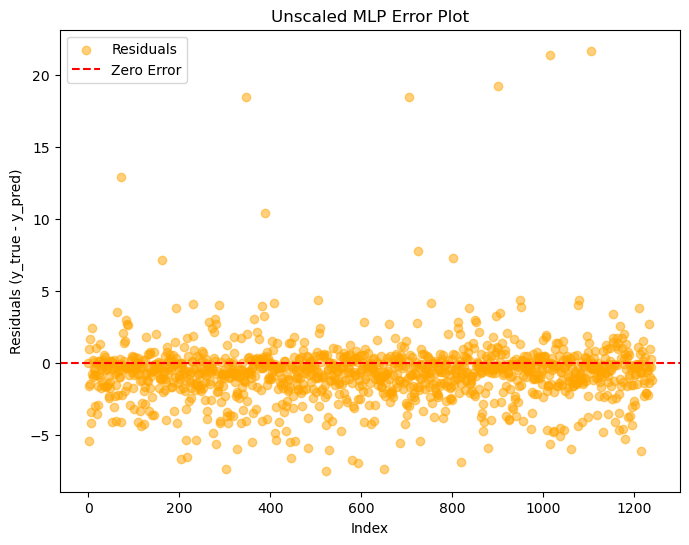

In [184]:
plt.figure(figsize=(8, 6))
plt.scatter(range(len(all_unscaled_residuals_mlp)), all_unscaled_residuals_mlp, alpha=0.5, color='orange', label='Residuals')
plt.axhline(0, color='red', linestyle='--', label='Zero Error')
plt.xlabel('Index')
plt.ylabel('Residuals (y_true - y_pred)')
plt.title('Unscaled MLP Error Plot')
plt.legend()
plt.show()

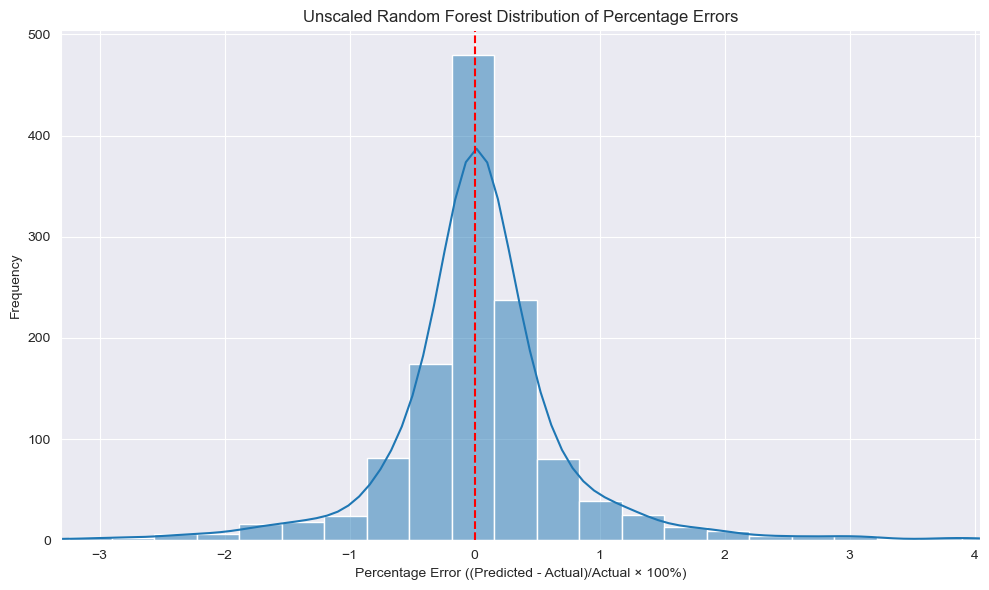

In [83]:
fig, ax = plt.subplots(figsize=(10, 6))
percentage_errors = 100 * (all_unscaled_y_pred_random_forest - all_unscaled_y_true_random_forest) / all_unscaled_y_true_random_forest
sns.histplot(percentage_errors, bins=50, kde=True, ax=ax)
ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
ax.set_ylabel('Frequency')
ax.set_title('Unscaled Random Forest Distribution of Percentage Errors')
# Set x-axis limits to focus on the main distribution
lower_bound = np.percentile(percentage_errors, 1)
upper_bound = np.percentile(percentage_errors, 99)
margin = (upper_bound - lower_bound) * 0.2
ax.set_xlim([lower_bound - margin, upper_bound + margin])
fig.tight_layout()

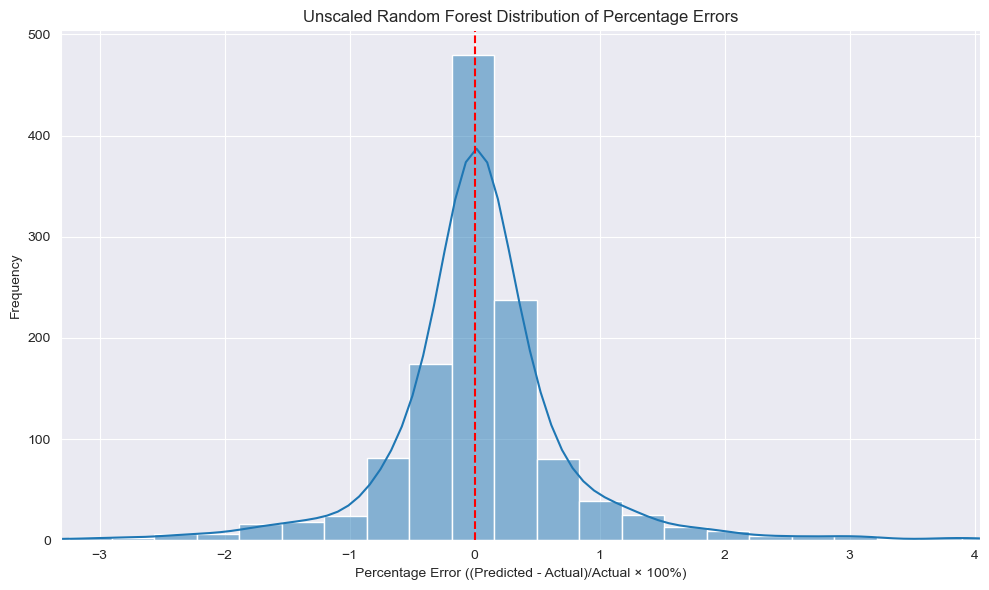

In [37]:
fig, ax = plt.subplots(figsize=(10, 6))
percentage_errors = 100 * (all_unscaled_y_pred_random_forest - all_unscaled_y_true_random_forest) / all_unscaled_y_true_random_forest
sns.histplot(percentage_errors, bins=50, kde=True, ax=ax)
ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
ax.set_ylabel('Frequency')
ax.set_title('Unscaled Random Forest Distribution of Percentage Errors')
# Set x-axis limits to focus on the main distribution
lower_bound = np.percentile(percentage_errors, 1)
upper_bound = np.percentile(percentage_errors, 99)
margin = (upper_bound - lower_bound) * 0.2
ax.set_xlim([lower_bound - margin, upper_bound + margin])
fig.tight_layout()

In [43]:
all_unscaled_res_random_forest[0]

array([ 50.4997693 ,  86.73924259, 348.61655196, ...,  20.8030438 ,
        16.8777457 , 127.59364593])

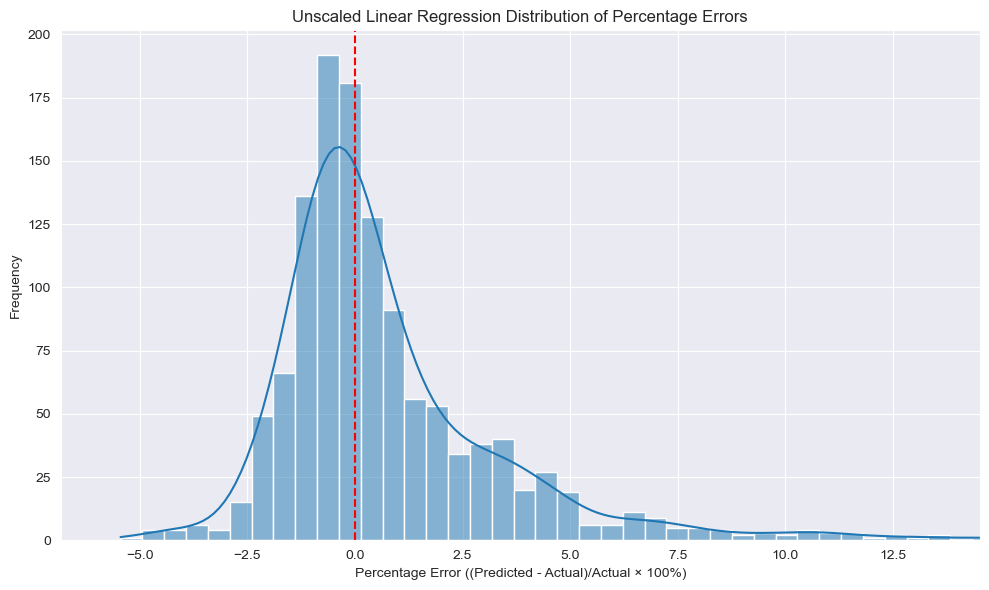

In [92]:
fig, ax = plt.subplots(figsize=(10, 6))
percentage_errors = 100 * (all_unscaled_y_pred_linear_regression - all_unscaled_y_true_linear_regression) / all_unscaled_y_true_linear_regression
sns.histplot(percentage_errors, bins=50, kde=True, ax=ax)
ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
ax.set_ylabel('Frequency')
ax.set_title('Unscaled Linear Regression Distribution of Percentage Errors')
# Set x-axis limits to focus on the main distribution
lower_bound = np.percentile(percentage_errors, 1)
upper_bound = np.percentile(percentage_errors, 99)
margin = (upper_bound - lower_bound) * 0.2
ax.set_xlim([lower_bound - margin, upper_bound + margin])
fig.tight_layout()

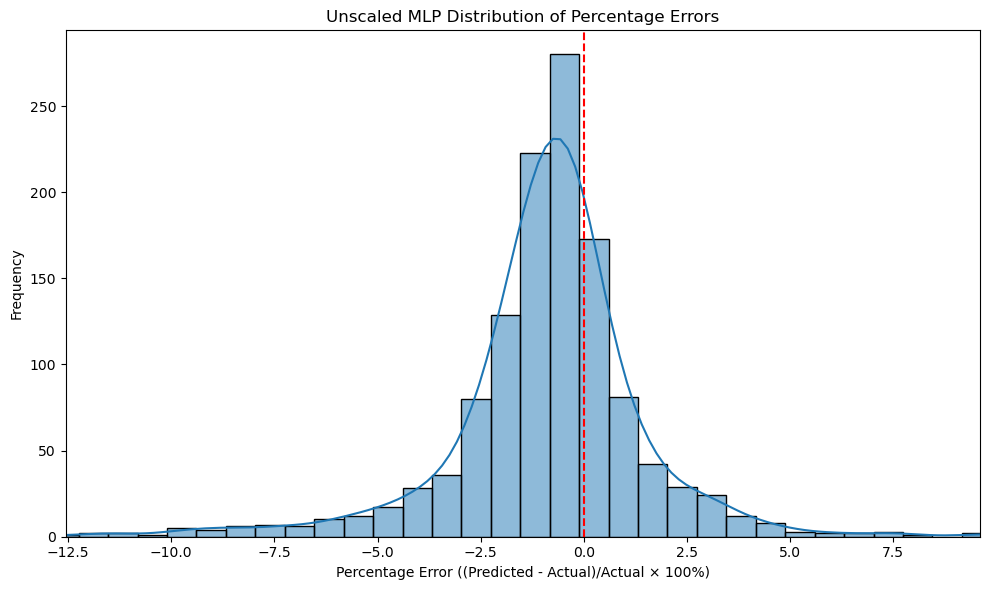

In [187]:
fig, ax = plt.subplots(figsize=(10, 6))
percentage_errors = 100 * (all_unscaled_y_pred_mlp - all_unscaled_y_true_mlp) / all_unscaled_y_true_mlp
sns.histplot(percentage_errors, bins=50, kde=True, ax=ax)
ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
ax.set_ylabel('Frequency')
ax.set_title('Unscaled MLP Distribution of Percentage Errors')
# Set x-axis limits to focus on the main distribution
lower_bound = np.percentile(percentage_errors, 1)
upper_bound = np.percentile(percentage_errors, 99)
margin = (upper_bound - lower_bound) * 0.2
ax.set_xlim([lower_bound - margin, upper_bound + margin])
fig.tight_layout()

Performance breakdown by conditions:

Stratify errors by SZA ranges to show consistency across different angles

Create separate plots for different scenes to demonstrate robustness

Show error metrics for different atmospheric conditions if applicable

Model validation experiments, MLP vs Tree:

Plot R² and RMSE vs. number of estimators (should plateau quickly if truly deterministic)

Show cross-validation results across different data splits

Plot learning curves to show how quickly the model reaches high accuracy


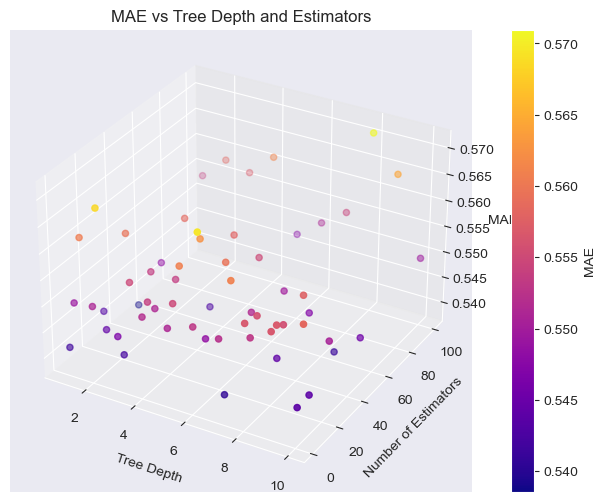

In [84]:
tree_est = []
tree_depths = []
maes = np.array([])
for key, value in all_td_est_comparison.items():
    tree_depths.append(key[0])
    tree_est.append(key[1])
    maes = np.append(maes, value[0]["Mean_Absolute_Error"])

half = len(tree_est) // 2
tree_df = pd.DataFrame({
    "Tree_Est": tree_est[:half],
    "Tree_Depth": tree_depths[:half],
    "mae": maes[:half]
})

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# 3D scatter
sc = ax.scatter(tree_depths, tree_est, maes, c=maes, cmap='plasma')
ax.set_xlabel("Tree Depth")
ax.set_ylabel("Number of Estimators")
ax.set_zlabel("MAE")
plt.title("MAE vs Tree Depth and Estimators")

# Color bar
fig.colorbar(sc, label="MAE")
plt.show()

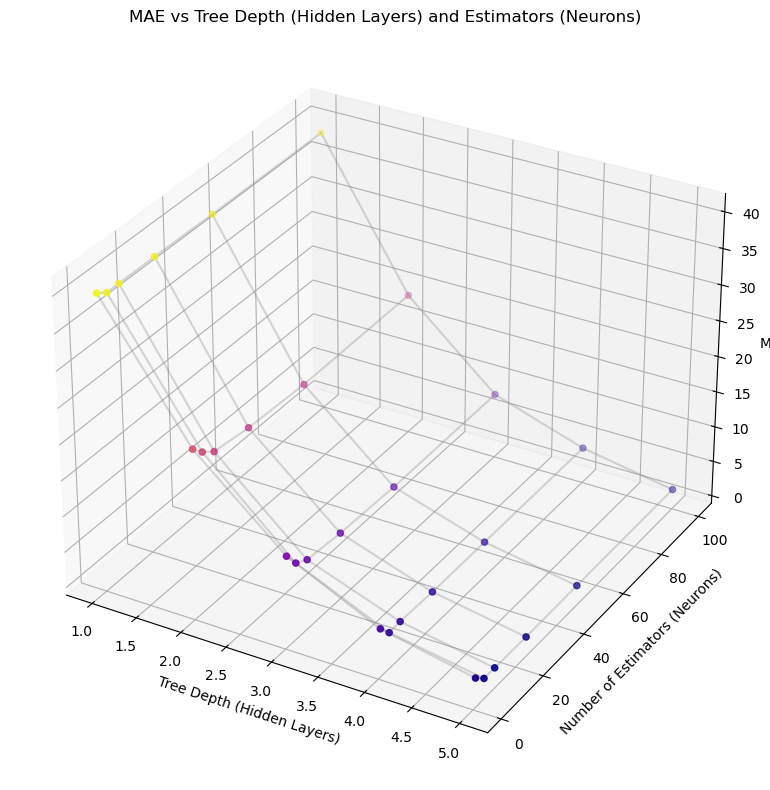

In [51]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter
sc = ax.scatter(tree_df['Tree_Depth'], tree_df['Tree_Est'], tree_df['mae'], c=tree_df['mae'], cmap='plasma')

# # Group by depth and plot lines between estimators
# for depth in tree_df['Tree_Depth'].unique():
#     subset = tree_df[tree_df['Tree_Depth'] == depth].sort_values(by='Tree_Est')
#     ax.plot(subset['Tree_Depth'], subset['Tree_Est'], subset['mae'], color='gray', alpha=0.5)
for depth in tree_df['Tree_Depth'].unique():
    subset = tree_df[tree_df['Tree_Depth'] == depth].sort_values(by='Tree_Est')
    ax.plot(subset['Tree_Depth'], subset['Tree_Est'], subset['mae'], color='gray', alpha=0.3)



for est in tree_df['Tree_Est'].unique():
    subset = tree_df[tree_df['Tree_Est'] == est].sort_values(by='Tree_Depth')
    ax.plot(subset['Tree_Depth'], subset['Tree_Est'], subset['mae'], color='gray', alpha=0.3)

ax.set_xlabel("Tree Depth (Hidden Layers)")
ax.set_ylabel("Number of Estimators (Neurons)")
ax.set_zlabel("MAE")
# ax.set_zlabel("MAE", labelpad=10)
plt.title("MAE vs Tree Depth (Hidden Layers) and Estimators (Neurons)")
# fig.colorbar(sc, label="MAE")
fig.tight_layout()

plt.show()

[1, 5, 10, 25, 50, 100, 1, 5, 10, 25, 50, 100, 1, 5, 10, 25, 50, 100, 1, 5, 10, 25, 50, 100, 1, 5, 10, 25, 50, 100]


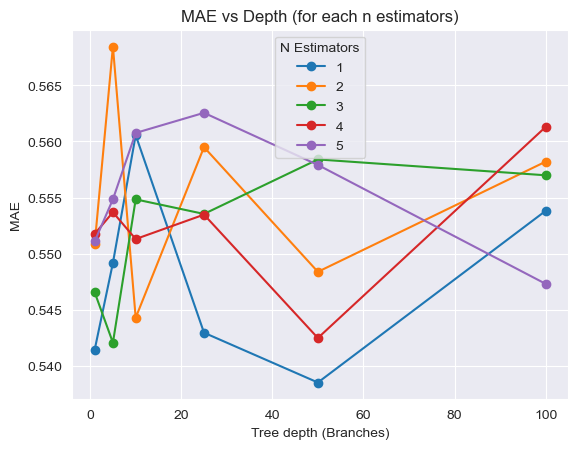

In [85]:

print(tree_est[:half])

# Pivot for plotting: rows = layer, cols = iter, values = mae
pivot = tree_df.pivot_table(index='Tree_Est', columns='Tree_Depth', values='mae')

pivot.plot(marker='o')
plt.xlabel("Tree depth (Branches)")
plt.ylabel("MAE")
plt.title("MAE vs Depth (for each n estimators)")
plt.legend(title="N Estimators")
plt.grid(True)
plt.show()

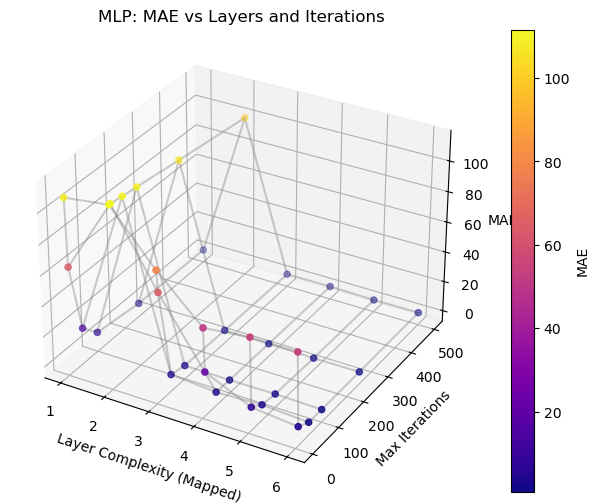

In [191]:
layer_map = {
    '2': 1,
    '(2, 2)': 2,
    '(4, 2)': 3,
    '(8, 4)': 4,
    '(16, 8)': 5,
    '(32, 16, 8)':6
}

mlp_iter = []
mlp_layers = []
mlp_maes = np.array([])
for key, value in all_mlp_neurons_iters_comparison.items():
    mlp_layers.append(str(key[0]))
    mlp_iter.append(key[1])
    mlp_maes = np.append(mlp_maes, value[0]["Mean_Absolute_Error"])
    
mlp_layer_nums = [layer_map[l] for l in mlp_layers]

mlp_df = pd.DataFrame({
    "layer": mlp_layer_nums,
    "iter": mlp_iter,
    "mae": mlp_maes
})

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Connect points with the same layer (varying iter)
for layer in mlp_df['layer'].unique():
    subset = mlp_df[mlp_df['layer'] == layer].sort_values('iter')
    ax.plot(subset['layer'], subset['iter'], subset['mae'], color='gray', alpha=0.4)

# Connect points with the same max_iter (varying layer complexity)
for it in mlp_df['iter'].unique():
    subset = mlp_df[mlp_df['iter'] == it].sort_values('layer')
    ax.plot(subset['layer'], subset['iter'], subset['mae'], color='gray', alpha=0.4)


sc = ax.scatter(mlp_layer_nums, mlp_iter, mlp_maes, c=mlp_maes, cmap='plasma')
ax.set_xlabel("Layer Complexity (Mapped)")
ax.set_ylabel("Max Iterations")
ax.set_zlabel("MAE")
plt.title("MLP: MAE vs Layers and Iterations")
fig.colorbar(sc, label="MAE")
plt.show()

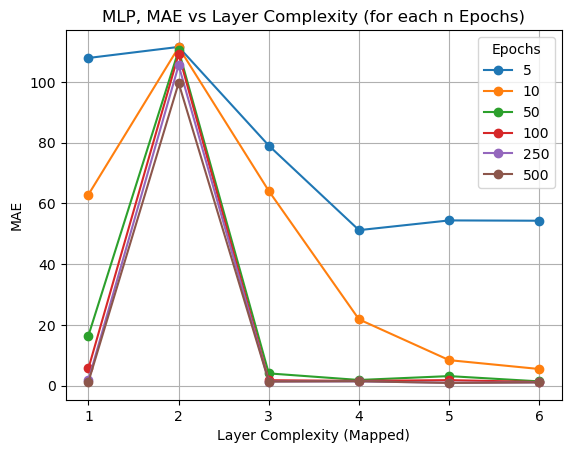

In [192]:
# Pivot for plotting: rows = layer, cols = iter, values = mae
pivot = mlp_df.pivot_table(index='layer', columns='iter', values='mae')

pivot.plot(marker='o')
plt.xlabel("Layer Complexity (Mapped)")
plt.ylabel("MAE")
plt.title("MLP, MAE vs Layer Complexity (for each n Epochs)")
plt.legend(title="Epochs")
plt.grid(True)
plt.show()

Synthetic tests to prove concept:

Add controlled noise to your inputs and show how accuracy degrades predictably

Create a simplified version of the problem where you apply a known filter to data, then show the model can recover it almost perfectly


In [102]:
all_mlp_noise_comparison

{0: [{'Mean_Absolute_Error': 1.4142247221960287,
   'Train_Accuracy': 0.9993642017730769,
   'Test_Accuracy': 0.9993469587453174,
   'Mean_Squared_Error': 5.386730395048138,
   'R_Squared': 0.9993469587453174,
   'Cross_Validated_Root_Mean_Squared_Error': array([2.9224335 , 3.28397799, 0.74450014, 3.26972216, 2.01928419]),
   'Cross_Validated_R_Squared': array([0.99867804, 0.99887173, 0.9998066 , 0.99859374, 0.99921211]),
   'Model': MLPRegressor(alpha=0.001, hidden_layer_sizes=(8, 4), learning_rate='adaptive',
                max_iter=500, random_state=42)},
  array([ 50.28241833,  87.826602  , 343.35429608, ...,  21.17514442,
          16.47522386, 126.40504149]),
        Shortwave Unfiltered Rads (Integrated)
  2941                               50.313969
  2366                               86.838952
  1634                              348.782641
  5035                               62.199197
  1212                               96.241008
  ...                                      

In [103]:
all_tree_noise_comparison

{0: [{'Mean_Absolute_Percentage_Error': 0.7347429658625121,
   'Root_Mean_Squared_Error': 0.8544535030709338,
   'Mean_Absolute_Error': 0.5072555753714032,
   'Accuracy': 99.26525703413749,
   'Cross_Validated_Root_Mean_Squared_Error': array([5.77987368, 2.15911602, 0.93868794, 1.78663513, 3.0470108 ]),
   'Cross_Validated_R_Squared': array([0.99482909, 0.99951229, 0.99969256, 0.99958013, 0.99820601]),
   'R_Squared': 0.9999114900190178,
   'Model': RandomForestRegressor(max_depth=10, random_state=42)},
  array([ 50.2935176 ,  86.5743519 , 348.77291356, ...,  21.16437618,
          16.99820388, 127.8343468 ]),
        Shortwave Unfiltered Rads (Integrated)
  2941                               50.313969
  2366                               86.838952
  1634                              348.782641
  5035                               62.199197
  1212                               96.241008
  ...                                      ...
  5613                               32.616666
  5072

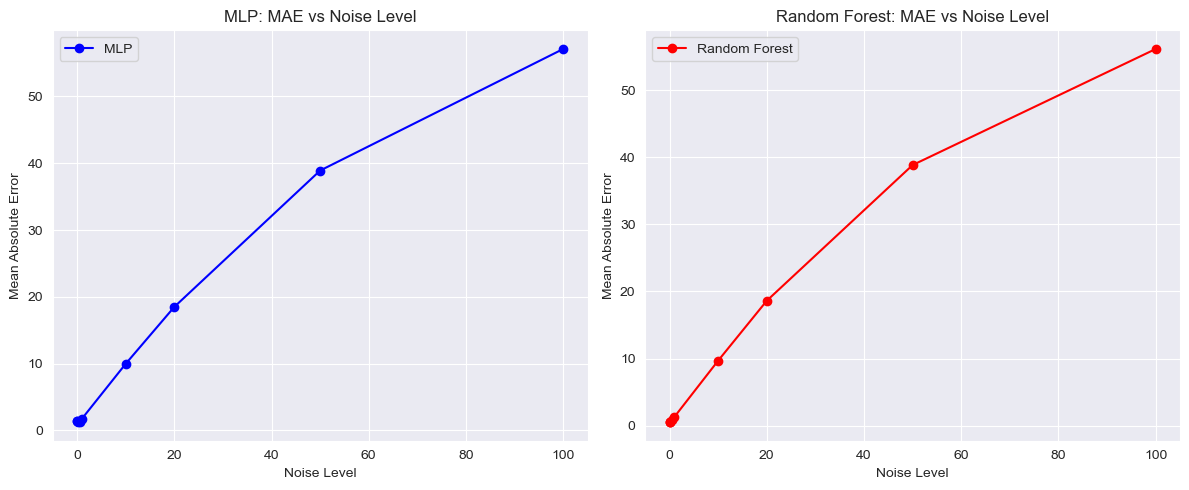

In [86]:
# Create noise comparison plots for MLP and Random Forest
plt.figure(figsize=(12, 5))

# MLP noise comparison
plt.subplot(1, 2, 1)
noise_levels = list(all_mlp_noise_comparison.keys())
mlp_maes = [results[0]['Mean_Absolute_Error'] for results in all_mlp_noise_comparison.values()]
plt.plot(noise_levels, mlp_maes, 'b-o', label='MLP')
plt.xlabel('Noise Level')
plt.ylabel('Mean Absolute Error')
plt.title('MLP: MAE vs Noise Level')
plt.grid(True)
plt.legend()

# Random Forest noise comparison  
plt.subplot(1, 2, 2)
noise_levels = list(all_tree_noise_comparison.keys())
rf_maes = [results[0]['Mean_Absolute_Error'] for results in all_tree_noise_comparison.values()]
plt.plot(noise_levels, rf_maes, 'r-o', label='Random Forest')
plt.xlabel('Noise Level')
plt.ylabel('Mean Absolute Error')
plt.title('Random Forest: MAE vs Noise Level')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


Physical validation:

Plot specific spectral features that would be physically interpretable to an atmospheric scientist

Compare your model's predictions with physics-based models for specific test cases

Demonstrate how the predicted unfiltered data maintains expected physical relationships


Turn into bell curve with the just the viirs bands

In [96]:
all_unscaled_y_pred_viirs_results = np.squeeze(viirs_results[1])
all_unscaled_y_true_viirs_results = np.squeeze(viirs_results[2])
# all_unscaled_y_true_random_forest = all_unscaled_res_random_forest[2]["Shortwave Unfiltered Rads (Integrated)"]
all_unscaled_residuals_viirs_results = all_unscaled_y_pred_viirs_results - all_unscaled_y_true_viirs_results

np.shape(all_unscaled_y_pred_viirs_results), np.shape(all_unscaled_y_true_viirs_results), np.shape(all_unscaled_residuals_viirs_results)

((1239,), (1239,), (1239,))

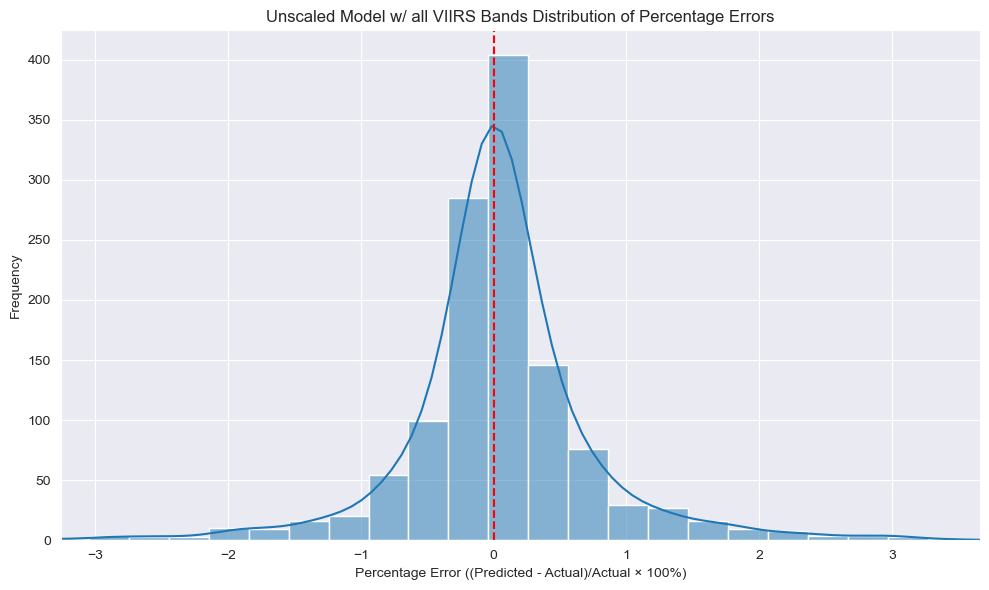

In [97]:
fig, ax = plt.subplots(figsize=(10, 6))
percentage_errors = 100 * (all_unscaled_y_pred_viirs_results - all_unscaled_y_true_viirs_results) / all_unscaled_y_true_viirs_results
sns.histplot(percentage_errors, bins=50, kde=True, ax=ax)
ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
ax.set_ylabel('Frequency')
ax.set_title('Unscaled Model w/ all VIIRS Bands Distribution of Percentage Errors')
# Set x-axis limits to focus on the main distribution
lower_bound = np.percentile(percentage_errors, 1)
upper_bound = np.percentile(percentage_errors, 99)
margin = (upper_bound - lower_bound) * 0.2
ax.set_xlim([lower_bound - margin, upper_bound + margin])
fig.tight_layout()

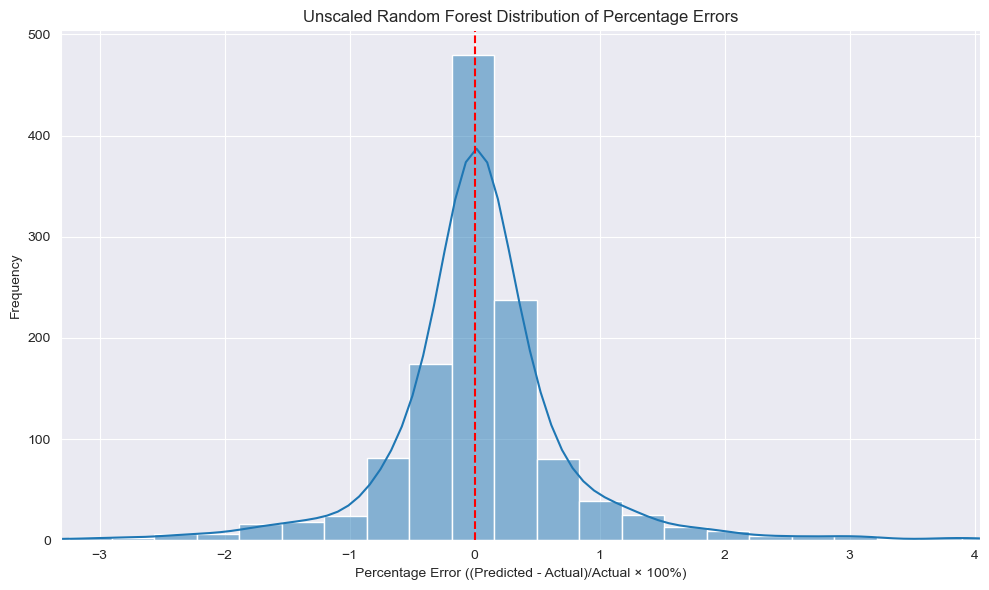

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
percentage_errors = 100 * (all_unscaled_y_pred_random_forest - all_unscaled_y_true_random_forest) / all_unscaled_y_true_random_forest
sns.histplot(percentage_errors, bins=50, kde=True, ax=ax)
ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
ax.set_ylabel('Frequency')
ax.set_title('Unscaled Random Forest Distribution of Percentage Errors')
# Set x-axis limits to focus on the main distribution
lower_bound = np.percentile(percentage_errors, 1)
upper_bound = np.percentile(percentage_errors, 99)
margin = (upper_bound - lower_bound) * 0.2
ax.set_xlim([lower_bound - margin, upper_bound + margin])
fig.tight_layout()

In [50]:
viirs_bands = ['M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
       'M12', 'M13', 'M14', 'M15', 'I5', 'M16']
all_dataset.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
       'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Scaled Shortwave Filtered',
       'Scaled Shortwave Unfiltered', 'Scaled Longwave Filtered',
       'Scaled Longwave Unfiltered'],
      dtype='object')

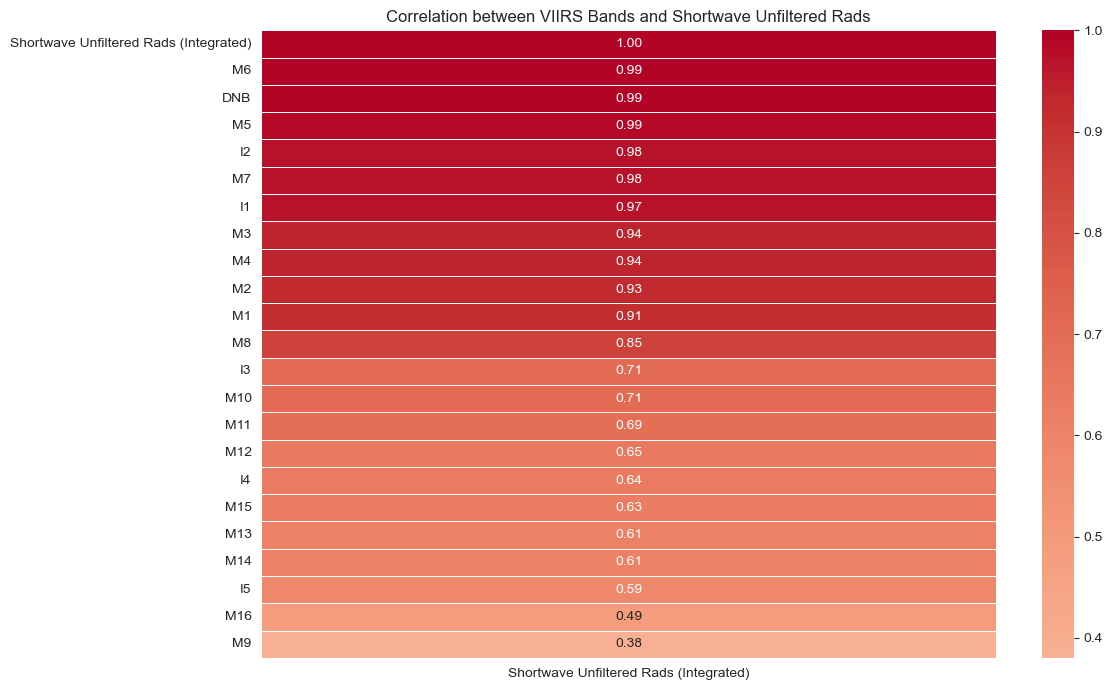

In [22]:
def create_correlation_heatmap(dataset: pd.DataFrame, cols: list):
    """
    Creates a correlation heatmap between VIIRS bands and Shortwave Unfiltered Rads.
    
    Args:
        dataset (pd.DataFrame): The input dataset containing VIIRS bands and Shortwave Unfiltered Rads
    """
    # Define VIIRS bands
    viirs_bands = ['M1', 'M2', 'M3', 'M4', 'I1',
                  'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
                  'M12', 'M13', 'M14', 'M15', 'I5', 'M16']
    target_column = 'Shortwave Unfiltered Rads (Integrated)'

    # Create a subset dataframe with just the columns we want
    correlation_data = dataset[viirs_bands + [target_column]]

    # Calculate correlation matrix
    correlation_matrix = correlation_data.corr()

    # Create the heatmap
    plt.figure(figsize=(12, 7))
    sns.heatmap(correlation_matrix[[target_column]].sort_values(by=target_column, ascending=False),
                annot=True, 
                cmap='coolwarm', 
                center=0,
                fmt='.2f',
                linewidths=0.5)
    plt.title('Correlation between VIIRS Bands and Shortwave Unfiltered Rads')
    plt.tight_layout()
    plt.show()
create_correlation_heatmap(all_dataset)

In [44]:
def engineer_viirs_features(data):
    """
    Create engineered features from VIIRS bands based on correlation analysis.
    
    Parameters:
    data (pd.DataFrame): DataFrame containing VIIRS bands
    
    Returns:
    pd.DataFrame: DataFrame with original and engineered features
    """
    # Create a copy to avoid modifying the original
    enhanced_data = data.copy()
    
    # 1. Group bands by correlation strength
    high_corr = ['M6', 'DNB', 'M5', 'I2', 'M7', 'I1', 'M3', 'M4', 'M2', 'M1']
    med_corr = ['M8', 'I3', 'M10', 'M11', 'M12', 'I4', 'M15', 'M13', 'M14']
    low_corr = ['I5', 'M16', 'M9']
    
    # 2. Create polynomial features for highest correlated bands
    for band in high_corr[:3]:  # Top 3 bands
        enhanced_data[f'{band}_squared'] = data[band] ** 2
    
    # 3. Create products between top correlated bands
    # These capture interaction effects between the strongest predictors
    for i, band1 in enumerate(high_corr[:5]):
        for band2 in high_corr[i+1:5]:  # Avoid duplicates
            enhanced_data[f'{band1}_x_{band2}'] = data[band1] * data[band2]
    
    # 4. Create band ratios between high and low correlated bands
    # These can help capture proportional relationships
    for high_band in high_corr[:3]:
        for low_band in low_corr:
            enhanced_data[f'{high_band}_to_{low_band}'] = data[high_band] / (data[low_band] + 1e-10)
    
    # 5. Create difference features
    # These can help detect specific spectral properties
    for high_band in high_corr[:3]:
        for low_band in low_corr:
            enhanced_data[f'{high_band}_minus_{low_band}'] = data[high_band] - data[low_band]
    
    # 6. Create aggregate features
    # Average of high correlation bands
    enhanced_data['high_corr_avg'] = data[high_corr].mean(axis=1)
    enhanced_data['med_corr_avg'] = data[med_corr].mean(axis=1)
    enhanced_data['low_corr_avg'] = data[low_corr].mean(axis=1)
    
    # 7. Create normalized band indices (similar to remote sensing indices)
    # These are common in VIIRS band analysis
    for i, band1 in enumerate(high_corr[:3]):
        for band2 in med_corr[:3]:
            enhanced_data[f'norm_diff_{band1}_{band2}'] = (data[band1] - data[band2]) / (data[band1] + data[band2] + 1e-10)
    
    return enhanced_data

In [45]:
def run_shortwave_viirs_model_feature_engineering(dataset: pd.DataFrame, v: bool, noised: bool, noise_level: float = 0.01, neurons: int = 100, tree_depth: int = 10):
    """
    takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param just_bands:
    :param dataset:
    :return all results (RMSE, RMSPE):
    """
    ret = {}
    base_model = None

    X, y = None, None

    columns_to_drop = ["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)", 
                      "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 
                      'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered', "Cloud"]

    
    X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    if v:
        print(f"Input Features {X.columns}, Prediction feature {y.columns}")

    X = engineer_viirs_features(X)


    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

    if noised:
        X_train = add_noise_to_features(X_train, noise_level)
        X_test = add_noise_to_features(X_test, noise_level)

    params = {'bootstrap': True,
        'max_depth': 12,
        'max_features': None,
        'max_samples': 0.8,
        'min_samples_leaf': 2,
        'min_samples_split': 5,
        'n_estimators': 100}
    
    regression_model = RandomForestRegressor(**params)
    regression_model.fit(X_train, y_train)

    importance = regression_model.feature_importances_
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance
    }).sort_values('Importance', ascending=False)


    y_pred = regression_model.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100

    ret["Mean_Absolute_Percentage_Error"] = mape
    ret["Root_Mean_Squared_Error"] = rmse
    ret["Mean_Absolute_Error"] = mae
    ret["Accuracy"] = 100 - mape
    # ret["MAEP"] = mae_percentage

    # tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    # ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(regression_model, X, y, cv=5, scoring="r2")
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["R_Squared"] = r2_score(y_test, y_pred)

    ret["Model"] = regression_model

    return [ret, y_pred, y_test, feature_importance]

In [46]:
viirs_feature_engineering_res = run_shortwave_viirs_model_feature_engineering(dataset=all_dataset, v=True, noised=False)
viirs_feature_engineering_res

Input Features Index(['SZA', 'VZA', 'RAZ', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6',
       'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14',
       'M15', 'I5', 'M16', 'Scaled Shortwave Filtered'],
      dtype='object'), Prediction feature Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')


[{'Mean_Absolute_Percentage_Error': 0.5253895813100316,
  'Root_Mean_Squared_Error': 1.417242882578057,
  'Mean_Absolute_Error': 0.40127438273863686,
  'Accuracy': 99.47461041868996,
  'Cross_Validated_Root_Mean_Squared_Error': array([5.74673173, 3.34939565, 0.68972941, 3.23576005, 3.08627281]),
  'Cross_Validated_R_Squared': array([0.99375222, 0.99890698, 0.99982982, 0.99844193, 0.99897845]),
  'R_Squared': 0.9997564972067406,
  'Model': RandomForestRegressor(max_depth=12, max_features=None, max_samples=0.8,
                        min_samples_leaf=2, min_samples_split=5)},
 array([ 50.55631496,  86.55818041, 348.83058079, ...,  20.71565634,
         16.81257981, 127.57658283]),
 array([[ 50.31396922],
        [ 86.83895218],
        [348.78264058],
        ...,
        [ 20.90997346],
        [ 16.7682088 ],
        [127.59956971]]),
                       Feature  Importance
 25  Scaled Shortwave Filtered    0.969532
 39                   M6_to_I5    0.001985
 54                M5_m

In [48]:
features = viirs_feature_engineering_res[-1]
features

,Feature,Importance
25,Scaled Shortwave Filtered,0.969532
39,M6_to_I5,0.001985
54,M5_minus_I5,0.001965
57,high_corr_avg,0.001936
23,I5,0.001695
...,...,...
59,low_corr_avg,0.000007
45,M5_to_I5,0.000006
66,norm_diff_M5_M8,0.000005
46,M5_to_M16,0.000002


In [90]:
all_unscaled_y_pred_viirs_engineering = np.squeeze(viirs_feature_engineering_res[1])
all_unscaled_y_true_viirs_engineering = np.squeeze(viirs_feature_engineering_res[2])
# all_unscaled_y_true_random_forest = all_unscaled_res_random_forest[2]["Shortwave Unfiltered Rads (Integrated)"]
all_unscaled_residuals_viirs_engineering = all_unscaled_y_pred_viirs_engineering - all_unscaled_y_true_viirs_engineering

np.shape(all_unscaled_y_pred_viirs_engineering), np.shape(all_unscaled_y_true_viirs_engineering), np.shape(all_unscaled_residuals_viirs_engineering)

NameError: name 'viirs_feature_engineering_res' is not defined

NameError: name 'all_unscaled_y_pred_viirs_engineering' is not defined

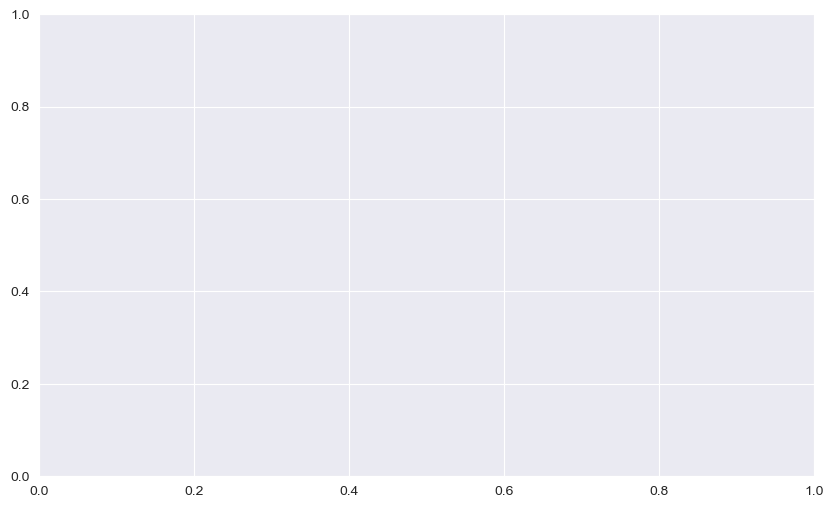

In [91]:
fig, ax = plt.subplots(figsize=(10, 6))
percentage_errors = 100 * (all_unscaled_y_pred_viirs_engineering - all_unscaled_y_true_viirs_engineering) / all_unscaled_y_true_viirs_engineering
sns.histplot(percentage_errors, bins=50, kde=True, ax=ax)
ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
ax.set_ylabel('Frequency')
ax.set_title('Unscaled Model w/ all VIIRS Bands and Feature Engineering Distribution of Percentage Errors')
# Set x-axis limits to focus on the main distribution
lower_bound = np.percentile(percentage_errors, 1)
upper_bound = np.percentile(percentage_errors, 99)
margin = (upper_bound - lower_bound) * 0.2
ax.set_xlim([lower_bound - margin, upper_bound + margin])
fig.tight_layout()

In [60]:
def apply_bias_correction(X_train, y_train, X_test, y_test, primary_model):
    """
    Implement bias correction for a trained model to center error distribution.
    
    Parameters:
    X_train, y_train: Training data
    X_test, y_test: Test data
    primary_model: Trained model (e.g., RandomForestRegressor)
    
    Returns:
    tuple: (corrected_predictions, bias_model)
    """
    # Step 1: Make predictions with the primary model on training data
    train_predictions = primary_model.predict(X_train)
    
    # Step 2: Calculate the errors (residuals) on training data
    train_errors = y_train - train_predictions
    
    print(f"Training errors statistics:")
    print(f"Mean error: {np.mean(train_errors):.4f}")
    print(f"Std deviation: {np.std(train_errors):.4f}")
    
    # Step 3: Train a bias correction model on these errors
    # Use the primary model's predictions as features
    # Various options for the bias model:
    
    # Option A: Simple linear regression (fastest, works for systematic bias)
    from sklearn.linear_model import LinearRegression
    bias_model = LinearRegression()
    bias_model.fit(train_predictions.reshape(-1, 1), train_errors)
    
    # Option B: More complex model for non-linear bias (uncomment if needed)
    # from sklearn.ensemble import GradientBoostingRegressor
    # bias_model = GradientBoostingRegressor(n_estimators=50, max_depth=3)
    # bias_model.fit(train_predictions.reshape(-1, 1), train_errors)
    
    # Step 4: Make predictions with primary model on test data
    test_predictions = primary_model.predict(X_test)
    
    # Step 5: Predict the expected errors using the bias model
    predicted_errors = bias_model.predict(test_predictions.reshape(-1, 1))
    
    # Step 6: Correct the primary model's predictions
    corrected_predictions = test_predictions - predicted_errors
    
    # Step 7: Calculate and compare errors before and after correction
    original_errors = y_test - test_predictions
    corrected_errors = y_test - corrected_predictions
    
    print("\nBefore bias correction:")
    print(f"Mean error: {np.mean(original_errors):.4f}")
    print(f"Mean absolute error: {np.mean(np.abs(original_errors)):.4f}")
    print(f"Error std deviation: {np.std(original_errors):.4f}")
    
    print("\nAfter bias correction:")
    print(f"Mean error: {np.mean(corrected_errors):.4f}")
    print(f"Mean absolute error: {np.mean(np.abs(corrected_errors)):.4f}")
    print(f"Error std deviation: {np.std(corrected_errors):.4f}")
    
    # Optional: Calculate percentage errors for plotting
    original_perc_errors = (test_predictions - y_test) / y_test * 100
    corrected_perc_errors = (corrected_predictions - y_test) / y_test * 100
    
    # Plot comparison of error distributions
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Original errors
    sns.histplot(original_perc_errors, kde=True, ax=ax1, color='skyblue')
    ax1.axvline(x=0, color='red', linestyle='--')
    ax1.set_title('Original Percentage Errors')
    ax1.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
    ax1.set_ylabel('Frequency')
    
    # Corrected errors
    sns.histplot(corrected_perc_errors, kde=True, ax=ax2, color='lightgreen')
    ax2.axvline(x=0, color='red', linestyle='--')
    ax2.set_title('Bias-Corrected Percentage Errors')
    ax2.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
    ax2.set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.savefig('bias_correction_comparison.png')
    
    return corrected_predictions, bias_model

# How to integrate this into your workflow:
def run_shortwave_regression_model_with_bias_correction(dataset,
                                                     viirs_bands=True, use_feature_engineering=False, 
                                                     apply_bias=True):
    # Your existing code for data preparation...
    ret = {}
    base_model = None

    X, y = None, None

    columns_to_drop = ["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)", 
                      "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 
                      'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered', "Cloud"]

    
    X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)

    # in y we should only have the unfiltered ground truth data
    y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                                'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                                'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                                'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                                'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)

    # if v:
    #     print(f"Input Features {X.columns}, Prediction feature {y.columns}")
    
    # Apply feature engineering if requested
    if use_feature_engineering and viirs_bands:
        X = engineer_viirs_features(X)
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    X_train, X_test = X_train.to_numpy(), X_test.to_numpy()
    y_train, y_test = y_train.to_numpy(), y_test.to_numpy()
    
    # Create and train the primary model
    
    regression_model = RandomForestRegressor(n_estimators=100, random_state=42, 
                                               max_depth=12, min_samples_leaf=2, 
                                               min_samples_split=5, max_samples=0.8,
                                               bootstrap=True)
    regression_model.fit(X_train, y_train)
    
    # Make predictions
    if apply_bias:
        y_pred, bias_model = apply_bias_correction(X_train, y_train, X_test, y_test, regression_model)
        print("Bias correction applied!")
    else:
        y_pred = regression_model.predict(X_test)
    
    # Calculate metrics and return results
    # [Rest of your evaluation code]
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100

    ret["Mean_Absolute_Percentage_Error"] = mape
    ret["Root_Mean_Squared_Error"] = rmse
    ret["Mean_Absolute_Error"] = mae
    ret["Accuracy"] = 100 - mape
    # ret["MAEP"] = mae_percentage

    # tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
    # ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100

    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(regression_model, X, y, cv=5, scoring="r2")
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["R_Squared"] = r2_score(y_test, y_pred)

    ret["Model"] = regression_model
    
    return [ret, y_pred, y_test, bias_model if apply_bias_correction else None]

In [61]:
model_error_res = run_shortwave_regression_model_with_bias_correction(all_dataset)
model_error_res

Training errors statistics:
Mean error: -0.0027
Std deviation: 125.3607


ValueError: operands could not be broadcast together with shapes (1239,) (1239,4956) 

In [63]:
X, y = None, None

columns_to_drop = ["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)", 
                    "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)", 
                    'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered', "Cloud"]


X = all_dataset.drop(columns=columns_to_drop).reset_index(drop=True)

# in y we should only have the unfiltered ground truth data
y = all_dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
                            'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
                            'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
                            'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
                            'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()

In [64]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_absolute_percentage_error

# custom scorer (negative because sklearn maximizes)
mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

# define the RF and the search space
rf = RandomForestRegressor(random_state=42)
param_dist = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
}

search_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=25,
    scoring=mape_scorer,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

# fit on your training data
search_rf.fit(X_train, y_train.ravel())

print("Best RF params:", search_rf.best_params_)
print("Best CV MAPE: {:.2f}%".format(-search_rf.best_score_ * 100))

# use the best model
best_rf = search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
print("Test MAPE: {:.2f}%".format(mean_absolute_percentage_error(y_test, y_pred_rf) * 100))


Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END bootstrap=False, max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=500; total time=   5.3s
[CV] END bootstrap=False, max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=500; total time=   5.4s
[CV] END bootstrap=False, max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=500; total time=   5.5s
[CV] END bootstrap=False, max_depth=30, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=500; total time=   5.6s
[CV] END bootstrap=False, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   1.1s
[CV] END bootstrap=False, max_depth=10, max_features=sqrt, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   1.0s
[CV] END bootstrap=True, max_depth=20, max_features=None, min_samples_leaf=1, min_samples_split=5, n_estimator

# TESTING XGBOOST MODEL

In [65]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

xgb_reg = xgb.XGBRegressor(random_state=42, objective="reg:squarederror", tree_method="hist")

param_dist_xgb = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 6, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 10, 100],
}

search_xgb = RandomizedSearchCV(
    estimator=xgb_reg,
    param_distributions=param_dist_xgb,
    n_iter=25,
    scoring=mape_scorer,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

search_xgb.fit(X_train, y_train.ravel())
print("Best XGB params:", search_xgb.best_params_)
print("Best CV MAPE: {:.2f}%".format(-search_xgb.best_score_ * 100))

best_xgb = search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
print("Test MAPE: {:.2f}%".format(mean_absolute_percentage_error(y_test, y_pred_xgb) * 100))


Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=300, reg_alpha=0, reg_lambda=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, n_estimators=100, reg_alpha=1, reg_lambda=1, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, n_estimators=100, reg_alpha=1, reg_lambda=1, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=300, reg_alpha=0, reg_lambda=100, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, n_estimators=100, reg_alpha=1, reg_lambda=1, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, n_estimators=100, reg_alpha=1, reg_lambda=1, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=6, n_estimators=100,

In [66]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(random_state=42)

param_dist_hgb = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_iter": [100, 300, 500],
    "max_depth": [None, 8, 16],
    "min_samples_leaf": [20, 50, 100],
    "l2_regularization": [0.0, 0.1, 1.0],
}

search_hgb = RandomizedSearchCV(
    estimator=hgb,
    param_distributions=param_dist_hgb,
    n_iter=20,
    scoring=mape_scorer,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

search_hgb.fit(X_train, y_train.ravel())
print("Best HGB params:", search_hgb.best_params_)
print("Best CV MAPE: {:.2f}%".format(-search_hgb.best_score_ * 100))

best_hgb = search_hgb.best_estimator_
y_pred_hgb = best_hgb.predict(X_test)
print("Test MAPE: {:.2f}%".format(mean_absolute_percentage_error(y_test, y_pred_hgb) * 100))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END l2_regularization=0.1, learning_rate=0.1, max_depth=8, max_iter=500, min_samples_leaf=100; total time=   0.4s
[CV] END l2_regularization=0.1, learning_rate=0.1, max_depth=8, max_iter=500, min_samples_leaf=100; total time=   0.4s
[CV] END l2_regularization=0.1, learning_rate=0.1, max_depth=8, max_iter=500, min_samples_leaf=100; total time=   0.4s
[CV] END l2_regularization=0.1, learning_rate=0.1, max_depth=8, max_iter=500, min_samples_leaf=100; total time=   0.4s
[CV] END l2_regularization=0.1, learning_rate=0.1, max_depth=8, max_iter=500, min_samples_leaf=100; total time=   0.4s
[CV] END l2_regularization=1.0, learning_rate=0.1, max_depth=8, max_iter=500, min_samples_leaf=50; total time=   0.5s
[CV] END l2_regularization=1.0, learning_rate=0.1, max_depth=8, max_iter=500, min_samples_leaf=50; total time=   0.5s
[CV] END l2_regularization=1.0, learning_rate=0.1, max_depth=8, max_iter=500, min_samples_leaf=50; total ti

In [67]:
all_unscaled_y_pred_random = np.squeeze(y_pred_rf)
all_unscaled_y_true_random = np.squeeze(y_test)
# all_unscaled_y_true_random_forest = all_unscaled_res_random_forest[2]["Shortwave Unfiltered Rads (Integrated)"]
all_unscaled_residuals_random = all_unscaled_y_pred_random - all_unscaled_y_true_random

np.shape(all_unscaled_y_pred_random), np.shape(all_unscaled_y_true_random), np.shape(all_unscaled_residuals_random)

((1239,), (1239,), (1239,))

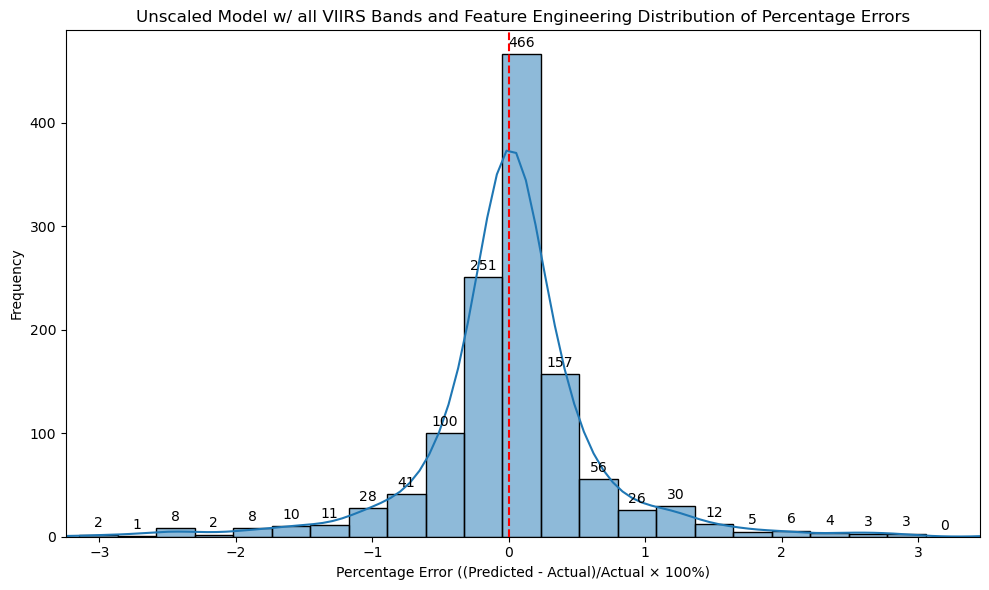

In [76]:
fig, ax = plt.subplots(figsize=(10, 6))
percentage_errors = 100 * (all_unscaled_y_pred_random - all_unscaled_y_true_random) / all_unscaled_y_true_random

# Create histogram and store the returned objects
hist = sns.histplot(percentage_errors, bins=50, kde=True, ax=ax)

# Get the bar containers from the histogram
bars = hist.containers[0]

# Add labels on top of each bar showing the count
ax.bar_label(bars, padding=3)

ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
ax.set_ylabel('Frequency')
ax.set_title('Unscaled Model w/ all VIIRS Bands and Feature Engineering Distribution of Percentage Errors')

# Set x-axis limits to focus on the main distribution
lower_bound = np.percentile(percentage_errors, 1)
upper_bound = np.percentile(percentage_errors, 99)
margin = (upper_bound - lower_bound) * 0.2
ax.set_xlim([lower_bound - margin, upper_bound + margin])

# Adjust the figure size to accommodate the labels
plt.tight_layout()

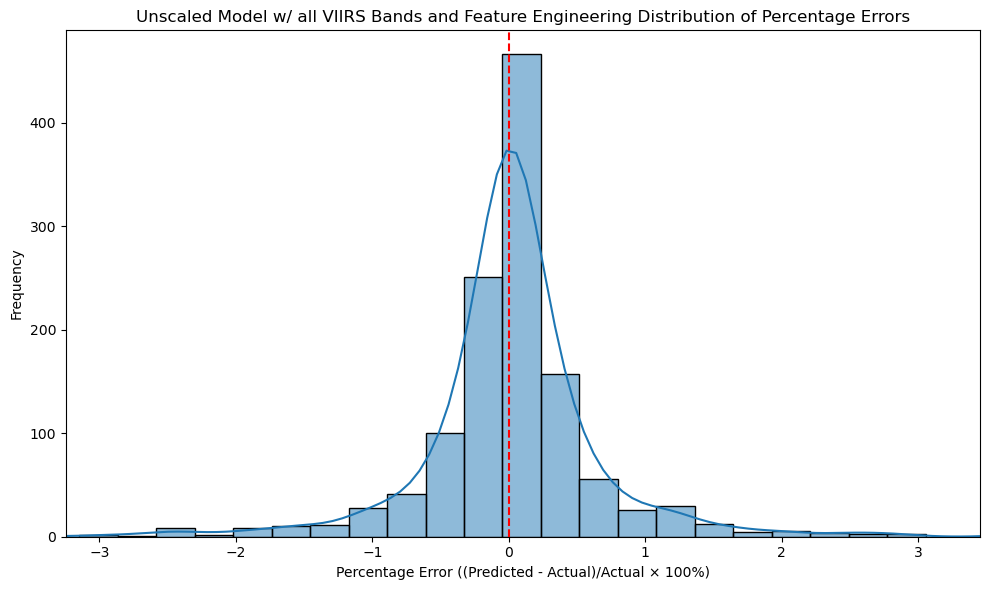

In [73]:
fig, ax = plt.subplots(figsize=(10, 6))
percentage_errors = 100 * (all_unscaled_y_pred_random - all_unscaled_y_true_random) / all_unscaled_y_true_random
sns.histplot(percentage_errors, bins=50, kde=True, ax=ax)
ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
ax.set_ylabel('Frequency')
ax.set_title('Unscaled Model w/ all VIIRS Bands and Feature Engineering Distribution of Percentage Errors')
# Set x-axis limits to focus on the main distribution
lower_bound = np.percentile(percentage_errors, 1)
upper_bound = np.percentile(percentage_errors, 99)
margin = (upper_bound - lower_bound) * 0.2
ax.set_xlim([lower_bound - margin, upper_bound + margin])
fig.tight_layout()

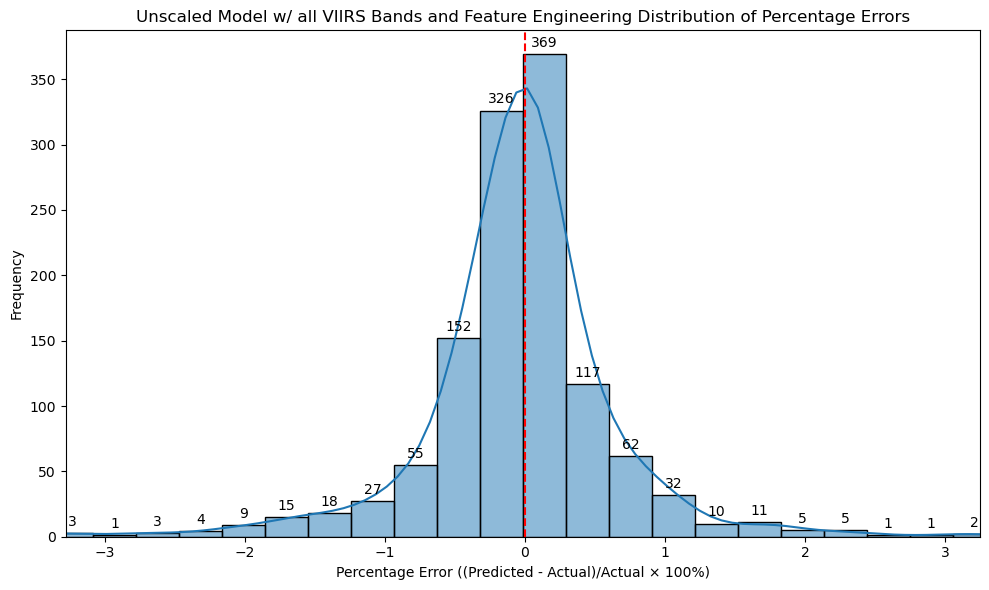

In [ ]:
# all_unscaled_y_pred_random = np.squeeze(y_pred_rf)
# all_unscaled_y_true_random = np.squeeze(y_test)
# # all_unscaled_y_true_random_forest = all_unscaled_res_random_forest[2]["Shortwave Unfiltered Rads (Integrated)"]
# all_unscaled_residuals_random = all_unscaled_y_pred_random - all_unscaled_y_true_random
# fig, ax = plt.subplots(figsize=(10, 6))
# percentage_errors = 100 * (all_unscaled_y_pred_random - all_unscaled_y_true_random) / all_unscaled_y_true_random
all_unscaled_y_pred_xgb = np.squeeze(y_pred_xgb)
all_unscaled_y_true_xgb = np.squeeze(y_test)
# all_unscaled_y_true_xgb = all_unscaled_res_xgb[2]["Shortwave Unfiltered Rads (Integrated)"]
all_unscaled_residuals_xgb = all_unscaled_y_pred_xgb - all_unscaled_y_true_xgb
fig, ax = plt.subplots(figsize=(10, 6))
percentage_errors = 100 * (all_unscaled_y_pred_xgb - all_unscaled_y_true_xgb) / all_unscaled_y_true_xgb
hist = sns.histplot(percentage_errors, bins=50, kde=True, ax=ax)

# Get the bar containers from the histogram
bars = hist.containers[0]

# Add labels on top of each bar showing the count
ax.bar_label(bars, padding=3)
ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
ax.set_ylabel('Frequency')
ax.set_title('Unscaled XGB Model w/ all VIIRS Bands and Feature Engineering Distribution of Percentage Errors')
# Set x-axis limits to focus on the main distribution
lower_bound = np.percentile(percentage_errors, 1)
upper_bound = np.percentile(percentage_errors, 99)
margin = (upper_bound - lower_bound) * 0.2
ax.set_xlim([lower_bound - margin, upper_bound + margin])
fig.tight_layout()

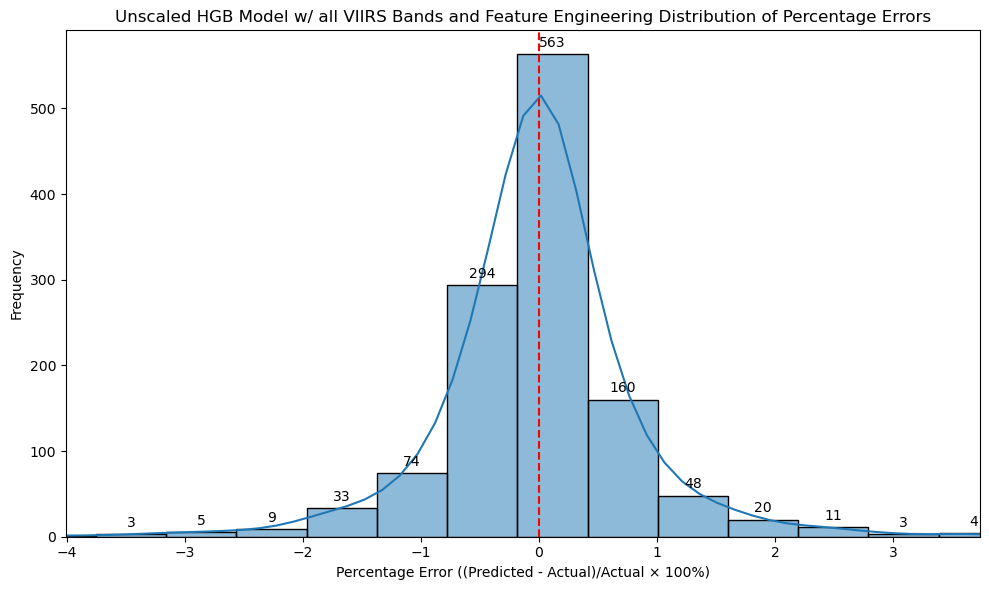

In [78]:
# all_unscaled_y_pred_xgb = np.squeeze(y_pred_xgb)
# all_unscaled_y_true_xgb = np.squeeze(y_test)
# # all_unscaled_y_true_xgb = all_unscaled_res_xgb[2]["Shortwave Unfiltered Rads (Integrated)"]
# all_unscaled_residuals_xgb = all_unscaled_y_pred_xgb - all_unscaled_y_true_xgb
# fig, ax = plt.subplots(figsize=(10, 6))
# percentage_errors = 100 * (all_unscaled_y_pred_xgb - all_unscaled_y_true_xgb) / all_unscaled_y_true_xgb
all_unscaled_y_pred_hgb = np.squeeze(y_pred_hgb)
all_unscaled_y_true_hgb = np.squeeze(y_test)
# all_unscaled_y_true_hgb = all_unscaled_res_hgb[2]["Shortwave Unfiltered Rads (Integrated)"]
all_unscaled_residuals_hgb = all_unscaled_y_pred_hgb - all_unscaled_y_true_hgb
fig, ax = plt.subplots(figsize=(10, 6))
percentage_errors = 100 * (all_unscaled_y_pred_hgb - all_unscaled_y_true_hgb) / all_unscaled_y_true_hgb
hist = sns.histplot(percentage_errors, bins=50, kde=True, ax=ax)

# Get the bar containers from the histogram
bars = hist.containers[0]

# Add labels on top of each bar showing the count
ax.bar_label(bars, padding=3)
ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
ax.set_ylabel('Frequency')
ax.set_title('Unscaled HGB Model w/ all VIIRS Bands and Feature Engineering Distribution of Percentage Errors')
# Set x-axis limits to focus on the main distribution
lower_bound = np.percentile(percentage_errors, 1)
upper_bound = np.percentile(percentage_errors, 99)
margin = (upper_bound - lower_bound) * 0.2
ax.set_xlim([lower_bound - margin, upper_bound + margin])
fig.tight_layout()

# NEW WORK

In [54]:
all_unscaled_res_random_forest_no_vbands = run_shortwave_regression_model_scaled(all_dataset, scaled=False, rf=True, v=True, viirs_bands=False, noised=False, neurons=100, tree_depth=10)

Input Features Index(['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)'], dtype='object'), Prediction feature Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')


In [55]:
all_unscaled_y_pred_random_forest_no_vbands = np.squeeze(all_unscaled_res_random_forest_no_vbands[1])
all_unscaled_y_true_random_forest_no_vbands = np.squeeze(all_unscaled_res_random_forest_no_vbands[2])
# all_unscaled_y_true_random_forest = all_unscaled_res_random_forest[2]["Shortwave Unfiltered Rads (Integrated)"]
all_unscaled_residuals_random_forest_no_vbands = all_unscaled_y_pred_random_forest_no_vbands - all_unscaled_y_true_random_forest_no_vbands

np.shape(all_unscaled_y_pred_random_forest_no_vbands), np.shape(all_unscaled_y_true_random_forest_no_vbands), np.shape(all_unscaled_residuals_random_forest_no_vbands)

((1239,), (1239,), (1239,))

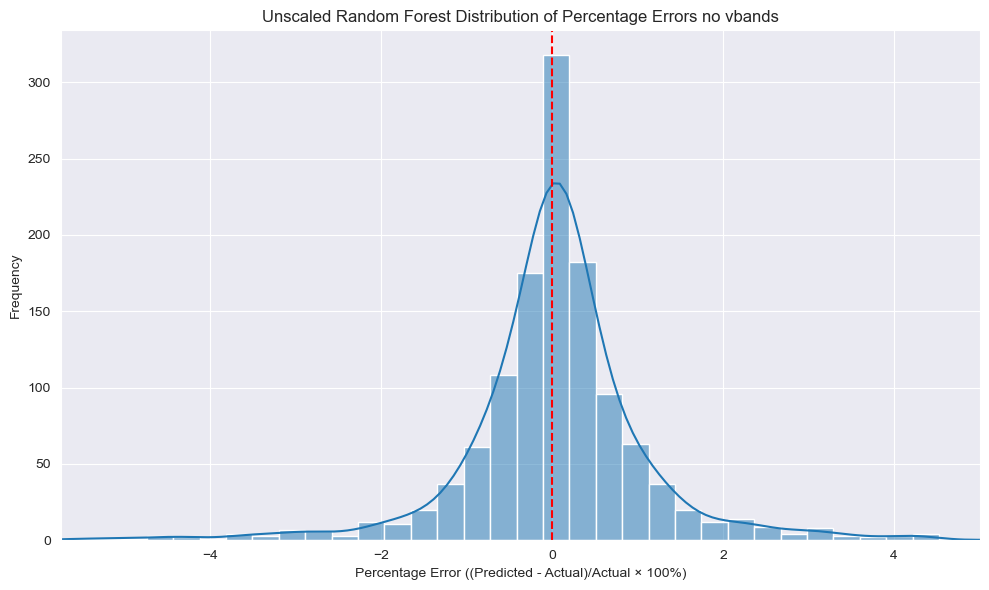

In [56]:
fig, ax = plt.subplots(figsize=(10, 6))
percentage_errors = 100 * (all_unscaled_y_pred_random_forest_no_vbands - all_unscaled_y_true_random_forest_no_vbands) / all_unscaled_y_true_random_forest_no_vbands
sns.histplot(percentage_errors, bins=50, kde=True, ax=ax)
ax.axvline(x=0, color='r', linestyle='--')
ax.set_xlabel('Percentage Error ((Predicted - Actual)/Actual × 100%)')
ax.set_ylabel('Frequency')
ax.set_title('Unscaled Random Forest Distribution of Percentage Errors no vbands')
# Set x-axis limits to focus on the main distribution
lower_bound = np.percentile(percentage_errors, 1)
upper_bound = np.percentile(percentage_errors, 99)
margin = (upper_bound - lower_bound) * 0.2
ax.set_xlim([lower_bound - margin, upper_bound + margin])
fig.tight_layout()

In [25]:
best_model = all_unscaled_res_random_forest[0]["Model"]

In [23]:
a41

{'Snow': <tp7.tp7.Tape7 at 0x16c5cae10>,
 'Land': <tp7.tp7.Tape7 at 0x326aa30d0>,
 'Clear Ocean': <tp7.tp7.Tape7 at 0x31e3abf50>,
 'Deep Convective Cloud': <tp7.tp7.Tape7 at 0x16ae73690>,
 'Cloudy Ocean': <tp7.tp7.Tape7 at 0x124a69510>}

In [26]:
land_a41 = a41["Land"]
test_df = land_a41.describer_df
test_df

,Scene,SZA,VZA,RAZ,Cloud,Run #,Shortwave Unfiltered Rads (Integrated),Longwave Unfiltered Rads (Integrated),Shortwave Filtered Rads (Integrated),Longwave Filtered Rads (Integrated),...,I3,M10,M11,I4,M12,M13,M14,M15,I5,M16
0,Land,41.4,0.000,0.0,0,0,75.634869,98.435211,56.053981,62.879096,...,3.055594,3.055594,0.658032,0.384365,0.194932,0.100106,0.001927,0.002084,0.002485,0.000801
1,Land,41.4,0.000,0.0,1,1,79.798190,69.392563,58.041074,45.058373,...,0.581493,0.581493,0.233670,0.006437,0.003273,0.001451,0.000058,0.000068,0.000175,0.000114
2,Land,41.4,0.000,0.0,1,2,120.430528,60.644071,87.805467,39.547043,...,0.183248,0.183248,0.096987,0.003241,0.001647,0.000629,0.000049,0.000058,0.000165,0.000111
3,Land,41.4,0.000,0.0,1,3,183.597556,93.578192,134.203175,59.989697,...,4.376058,4.376058,0.779609,0.299124,0.164866,0.084113,0.003810,0.002616,0.003100,0.000710
4,Land,41.4,0.000,0.0,1,4,238.104153,86.650362,173.797273,55.813000,...,3.412519,3.412519,0.437161,0.192198,0.105858,0.047403,0.004520,0.004434,0.006011,0.002268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
625,Land,31.4,79.914,172.5,0,625,76.680411,58.907521,54.570532,38.290031,...,1.193021,1.193021,0.076045,0.019613,0.014381,0.001370,0.000069,0.000375,0.000459,0.000199
626,Land,31.4,79.914,172.5,1,626,90.578004,46.597853,64.909921,30.533421,...,0.355098,0.355098,0.105072,0.006452,0.003591,0.000950,0.000077,0.000123,0.000312,0.000235
627,Land,31.4,79.914,172.5,1,627,110.669036,44.111623,79.706207,28.924237,...,0.297768,0.297768,0.097123,0.006542,0.003555,0.001043,0.000080,0.000124,0.000315,0.000235
628,Land,31.4,79.914,172.5,1,628,150.575561,58.372399,109.442847,37.965469,...,3.470613,3.470613,0.554175,0.123196,0.095438,0.009001,0.001371,0.002441,0.002879,0.001021


In [27]:
matt_test_data = test_df[
    (test_df["SZA"].between(41, 60) &
     test_df["VZA"].between(15, 30) &
     test_df["RAZ"].between(15, 60) &
     test_df["Cloud"] == 1)
]
matt_test_data = matt_test_data[['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Shortwave Unfiltered Rads (Integrated)', 'Longwave Filtered Rads (Integrated)','Longwave Unfiltered Rads (Integrated)']]
matt_test_data

,SZA,VZA,RAZ,Shortwave Filtered Rads (Integrated),M1,M2,M3,M4,I1,M5,...,I4,M12,M13,M14,M15,I5,M16,Shortwave Unfiltered Rads (Integrated),Longwave Filtered Rads (Integrated),Longwave Unfiltered Rads (Integrated)
61,41.805,29.49001,37.5,61.165962,4.934811,5.437113,5.910939,5.467984,18.253184,4.881756,...,0.006908,0.003524,0.001504,0.000074,0.000088,0.000228,0.000152,83.960730,44.417802,68.370089
62,41.805,29.49001,37.5,92.257045,7.582463,8.480751,9.136672,8.236948,27.238925,7.226458,...,0.004544,0.002312,0.000885,0.000070,0.000084,0.000232,0.000157,126.242860,39.262312,60.196657
63,41.805,29.49001,37.5,133.577522,11.819763,13.459199,14.627185,13.022716,40.109773,10.849059,...,0.298435,0.164480,0.083522,0.003745,0.002596,0.003059,0.000705,182.442010,59.176626,92.288501
64,41.805,29.49001,37.5,171.410551,15.180478,17.317722,18.818809,16.792817,52.868159,14.080756,...,0.202375,0.111730,0.049580,0.004755,0.004696,0.006359,0.002422,234.427895,55.225056,85.729909
66,41.805,29.49001,37.5,53.033611,4.700871,4.936417,5.032877,4.337735,14.406901,3.981098,...,0.006651,0.003393,0.001438,0.000074,0.000088,0.000228,0.000152,73.274499,44.292866,68.156401
67,41.805,29.49001,37.5,88.266835,7.460655,8.222681,8.685391,7.655184,25.253851,6.758450,...,0.004544,0.002312,0.000885,0.000070,0.000084,0.000232,0.000157,120.973156,39.260386,60.193325
68,41.805,29.49001,37.5,132.626809,11.793591,13.404321,14.531137,12.898418,39.689183,10.747986,...,0.298400,0.164461,0.083509,0.003745,0.002596,0.003060,0.000705,181.198003,59.145076,92.234396
69,41.805,29.49001,37.5,171.409917,15.180436,17.317665,18.818693,16.792717,52.867885,14.080669,...,0.202375,0.111730,0.049580,0.004755,0.004696,0.006359,0.002422,234.427035,55.225056,85.729909
71,41.805,29.49001,37.5,61.912639,4.744734,5.059056,5.277653,4.431456,13.826562,3.762117,...,0.005514,0.002829,0.001116,0.000068,0.000082,0.000219,0.000149,84.738256,43.512874,66.888730
72,41.805,29.49001,37.5,92.615103,7.485137,8.285688,8.792859,7.623837,24.752157,6.618534,...,0.004563,0.002316,0.000889,0.000070,0.000083,0.000231,0.000156,126.514819,38.708688,59.300763


In [28]:
X_mtest_data = matt_test_data[['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']]
sw_input = matt_test_data[['Shortwave Filtered Rads (Integrated)']].to_numpy()
lw_input = matt_test_data[['Longwave Filtered Rads (Integrated)']].to_numpy()
Y_mtest_true_data = matt_test_data[['Shortwave Unfiltered Rads (Integrated)']].to_numpy().ravel()

In [29]:
Y_mtest_pred_data = best_model.predict(X_mtest_data)
Y_mtest_true_data.ravel()
mtest_pe = ( (Y_mtest_pred_data - Y_mtest_true_data) / Y_mtest_true_data) * 100
mtest_pe

array([ 0.31979234,  0.05322613, -0.07524965,  0.04727989, -0.02476695,
       -0.16300748, -0.04923301,  0.03895272,  0.28627898,  0.01917852,
        0.08948036, -0.05519382, -0.34469955,  0.09941663,  0.03772682,
        0.02288939, -0.12842645,  0.08131229, -0.05123129,  0.0190511 ,
        0.18228856, -0.01341485, -0.09074437, -0.02098377])

In [28]:
sw_input

array([[ 61.16596183],
       [ 92.25704479],
       [133.57752207],
       [171.41055136],
       [ 53.03361097],
       [ 88.26683487],
       [132.62680924],
       [171.40991675],
       [ 61.91263855],
       [ 92.61510306],
       [136.23735191],
       [174.27748984],
       [ 43.9119979 ],
       [ 84.06190456],
       [137.748519  ],
       [178.76468497],
       [ 46.47771395],
       [ 85.145948  ],
       [138.00977982],
       [178.76469006],
       [ 55.84404772],
       [ 89.4738033 ],
       [144.57606725],
       [178.77432922]])

In [29]:
Y_mtest_pred_data

array([ 84.20467824, 126.30715948, 182.25356348, 234.56240334,
        73.15570145, 120.69712332, 181.19950561, 234.56240334,
        85.00949817, 126.61059203, 185.45295756, 237.80064803,
        61.20382251, 115.37186712, 187.08878264, 243.56578728,
        64.58321484, 116.97130493, 187.19535325, 243.56047252,
        76.66585192, 122.20632877, 195.59258935, 243.30592041])

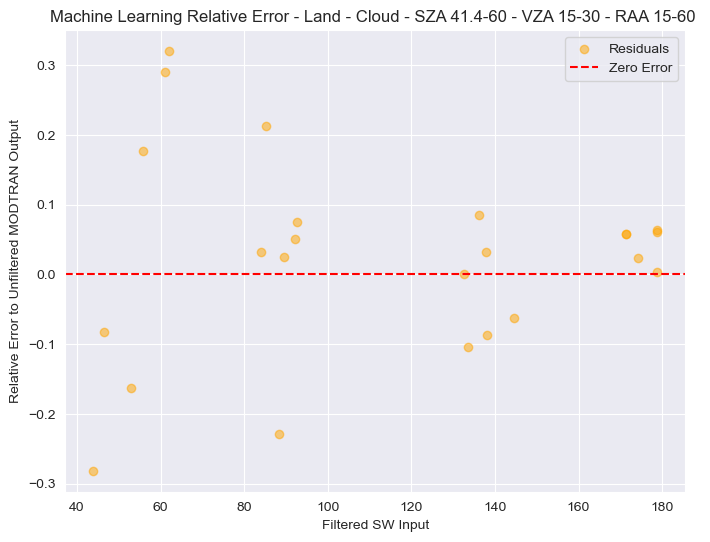

In [45]:
plt.figure(figsize=(8, 6))
plt.scatter(sw_input, mtest_pe, alpha=0.5, color='orange', label='Residuals')
plt.axhline(0, color='red', linestyle='--', label='Zero Error')
plt.title("Machine Learning Relative Error - Land - Cloud - SZA 41.4-60 - VZA 15-30 - RAA 15-60 ")
plt.ylabel("Relative Error to Unfiltered MODTRAN Output")
plt.xlabel("Filtered SW Input")
plt.legend()
plt.show()

1

In [16]:
a41

{'Snow': <tp7.tp7.Tape7 at 0x339d4f490>,
 'Land': <tp7.tp7.Tape7 at 0x321330090>,
 'Clear Ocean': <tp7.tp7.Tape7 at 0x329c4bd10>,
 'Deep Convective Cloud': <tp7.tp7.Tape7 at 0x177b4ba50>,
 'Cloudy Ocean': <tp7.tp7.Tape7 at 0x32bb57b90>}

In [25]:
land_41 = a41["Land"]
land_41.describer_df.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
       'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object')

In [26]:
land_41.describer_df.shape

(630, 32)

In [26]:
unfilt_sw_radiance = land_41.describer_df[['Shortwave Unfiltered Rads (Integrated)']].to_numpy()
filt_sw_radiance = land_41.describer_df[['Shortwave Filtered Rads (Integrated)']]

In [27]:
unfilt_sw_radiance

array([[ 75.6348686 ],
       [ 79.79818981],
       [120.43052834],
       [183.59755555],
       [238.10415308],
       [ 57.97132149],
       [ 68.40354575],
       [114.65397487],
       [182.23097014],
       [238.10338028],
       [ 72.26184217],
       [ 80.33420823],
       [120.82661658],
       [186.47410368],
       [241.52343091],
       [ 32.39189899],
       [ 55.23360666],
       [108.44366444],
       [187.85176452],
       [247.22712302],
       [ 39.24882491],
       [ 58.72529977],
       [109.96781228],
       [188.21509218],
       [247.22712302],
       [ 58.36494936],
       [ 71.44069084],
       [115.98441511],
       [196.49059669],
       [246.95196039],
       [ 74.08534982],
       [ 83.90900034],
       [126.13860048],
       [181.99223517],
       [233.86038363],
       [ 56.79435032],
       [ 73.24836208],
       [120.88199104],
       [180.75121955],
       [233.85951877],
       [ 71.02088445],
       [ 84.68816174],
       [126.41011765],
       [184

In [18]:
land_41.rads.shape

(630, 3, 4000)

In [35]:
wavelengths = land_41.rads[0, 0, :]
sw_radience = land_41.rads[0, 1, :]
land_41_rads = land_41.rads

In [37]:
interpolated_sw_srf = np.interp(x=wavelengths, xp=tot_wvln, fp=sw_srf)
# rads = (run_num, wv, measurement)
run = land_41_rads[0]
run.shape, run[0], run[1], interpolated_sw_srf.shape
# shortwave_unfiltered = [integrate.simpson(y=run[1], x=run[0]) for run in self.rads]
#
# shortwave_filtered = [integrate.simpson(y=(run[1] * interpolated_sw_srf), x=run[0]) for run in self.rads]

((3, 4000),
 array([2.50000000e-01, 2.50062516e-01, 2.50125063e-01, ...,
        3.33333333e+02, 5.00000000e+02, 1.00000000e+03]),
 array([1.57356800e-02, 1.48277833e-02, 1.51157529e-02, ...,
        3.70215000e-21, 1.80776000e-22, 9.69352280e-25]),
 (4000,))

In [30]:
land_sza_41_runs = load_all_runs_from_tp7("./data/Modtran_Unfiltering_Tape7s_SZA41/lnd_sz41L.tp7", header_lines=12)

In [82]:
all_runs_df = pd.concat(land_sza_41_runs, ignore_index=True)
all_runs_df

{}

In [31]:
vzas = []
szas = []
raas = []
cfs = []
for i in range(len(land_sza_41_runs)):
    vzas.append(land_sza_41_runs[i].attrs["VZA"])
    szas.append(land_sza_41_runs[i].attrs["SZA"])
    raas.append(land_sza_41_runs[i].attrs["RAA"])
    cfs.append(land_sza_41_runs[i].attrs["CloudFraction"])
vzas = np.array(vzas)
szas = np.array(szas)
raas = np.array(raas)
cfs = np.array(cfs)

found_runs = []
first_found = -1
for i in range(len(land_sza_41_runs)):
    if 15 <= vzas[i] <= 30:
        if 41.4 <= szas[i] <= 60:
            if 15 <= raas[i] <= 60:
                if cfs[i] == 1:
                    found_runs.append(land_sza_41_runs[i])
                    if first_found == -1:
                        first_found = i
                    j=i

pandas.core.frame.DataFrame

In [38]:
# unfiltered_sw = []
# filtered_sw = []
# filtered_ssw = []
# rows = []
#
# for i, run in enumerate(found_runs):
#     sw_radiance = np.where(
#         (wavelengths >= 0.35) & (wavelengths < 4.5),
#         run.TotalRadianceWatts,
#         0
#     )
#
#     # filtered_ssw.append(np.trapz(sw_radiance*ssw_filter, wavelengths))
#
#     row = {
#         "Run": i,
#         "Unfiltered_SW": np.trapz(sw_radiance, wavelengths),
#         "Filtered_SW": np.trapz(sw_radiance * interpolated_sw_srf, wavelengths),
#         # if you want SSW later, just uncomment:
#         # "Filtered_SSW": np.trapz(sw_radiance * ssw_filter, wavelengths),
#         "SZA": run.attrs["SZA"],
#         "VZA": run.attrs["VZA"],
#         "RAA": run.attrs["RAA"],
#         "CloudFraction": run.attrs["CloudFraction"]
#     }
#
#     rows.append(row)
#
#     unfiltered_sw.append(np.trapz(sw_radiance, wavelengths))
#     # filtered_sw.append(np.trapz(sw_radiance*sw_filter, wavelengths))
#     # filtered_ssw.append(np.trapz(sw_radiance*ssw_filter, wavelengths))
#
# matt_df = pd.DataFrame(rows)
#
# filtered_sw = np.array(filtered_sw)
# # filtered_ssw = np.array(filtered_ssw)
# unfiltered_sw = np.array(unfiltered_sw)
unfiltered_sw = []
filtered_sw = []
filtered_ssw = []

for i in range(len(found_runs)):
    sw_radiance = np.where(
        (wavelengths >= 0.35) & (wavelengths < 4.5),
        found_runs[i].TotalRadianceWatts,
        0
    )
    unfiltered_sw.append(np.trapz(sw_radiance, wavelengths))
    filtered_sw.append(np.trapz(sw_radiance*interpolated_sw_srf, wavelengths))
    # filtered_ssw.append(np.trapz(sw_radiance*ssw_filter, wavelengths))

filtered_sw = np.array(filtered_sw)
# filtered_ssw = np.array(filtered_ssw)
unfiltered_sw = np.array(unfiltered_sw)

In [100]:
matt_df.columns

Index(['Run', 'Unfiltered_SW', 'Filtered_SW', 'SZA', 'VZA', 'RAA',
       'CloudFraction'],
      dtype='object')

In [101]:
matt_test_data.columns

Index(['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16',
       'Shortwave Unfiltered Rads (Integrated)'],
      dtype='object')

In [39]:
fit = np.polynomial.polynomial.Polynomial.fit(filtered_sw, unfiltered_sw, 2)
estimated = fit(filtered_sw)
r2_score(unfiltered_sw, estimated)
print(f"r^2 Value: {r2_score(unfiltered_sw, estimated)}")
print(f"Mean Squared Error: {mean_squared_error(unfiltered_sw, estimated)}")

quad_relative_error = (unfiltered_sw-estimated)/unfiltered_sw*100

r^2 Value: 0.9999758134781928
Mean Squared Error: 0.09220770753637221


In [40]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

input = filtered_sw.reshape(-1, 1)
output = unfiltered_sw

poly_model = PolynomialFeatures(degree=2)
poly_x = poly_model.fit_transform(input)

poly_model.fit(poly_x, output)

regression = LinearRegression()
regression.fit(poly_x, output)

predicted = regression.predict(poly_x)
print(f"r^2 Value: {r2_score(unfiltered_sw, predicted)}")
print(f"Mean Squared Error: {mean_squared_error(unfiltered_sw, predicted)}")

mv_relative_error = (unfiltered_sw - predicted) / unfiltered_sw * 100

r^2 Value: 0.9999758134781928
Mean Squared Error: 0.09220770753637435


In [68]:
filtered_sw

array([ 61.03283371,  92.03583137, 133.38978364, 171.08428167,
        52.89907504,  88.04703742, 132.4379297 , 171.08365733,
        61.76680678,  92.39077953, 136.03401167, 173.93908478,
        43.75921543,  83.83376311, 137.51051183, 178.3920934 ,
        46.32157146,  84.91718851, 137.77110729, 178.39210103,
        55.67987909,  89.24189307, 144.294146  , 178.38695576])

In [72]:
filtered_sw

array([ 61.03283371,  92.03583137, 133.38978364, 171.08428167,
        52.89907504,  88.04703742, 132.4379297 , 171.08365733,
        61.76680678,  92.39077953, 136.03401167, 173.93908478,
        43.75921543,  83.83376311, 137.51051183, 178.3920934 ,
        46.32157146,  84.91718851, 137.77110729, 178.39210103,
        55.67987909,  89.24189307, 144.294146  , 178.38695576])

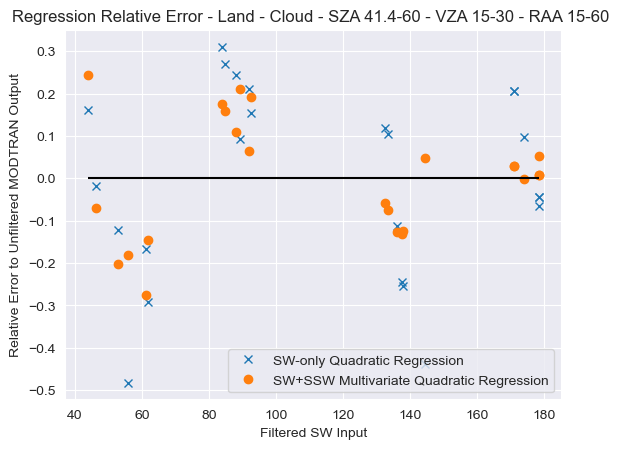

In [44]:
filtered_sw1 = np.loadtxt('filtered_sw.csv', delimiter=',')
mv_relative_error1 = np.loadtxt('mv_relative_error.csv', delimiter=',')
quad_relative_error1 = np.loadtxt('quad_relative_error.csv', delimiter=',')
plt.plot(filtered_sw1, quad_relative_error1 ,"x", label="SW-only Quadratic Regression")
plt.plot(filtered_sw1, mv_relative_error1 ,"o", label="SW+SSW Multivariate Quadratic Regression")
# plt.plot(filtered_sw1, mtest_pe, "*", label='Random Forest ML Error')
plt.hlines(0, filtered_sw1.min(), filtered_sw1.max(), colors="k")
plt.title("Regression Relative Error - Land - Cloud - SZA 41.4-60 - VZA 15-30 - RAA 15-60 ")
plt.ylabel("Relative Error to Unfiltered MODTRAN Output")
plt.xlabel("Filtered SW Input")
plt.legend(loc = "lower right")

## Final Steps
1. Get all the models from the list below
    * Old school single variable regression
    * multivariate regression
    * Best model = All viirs bands + longwave and shortwave + geo
    * Libera only model = shortwave + longwave VIIRS bands + all libera channels + geo
    * No VIIRS bands model = shortwave + longwave + geo
    * shortwave only + geo
2. Compare all results with the PE/relative errors like the graphs above

In [27]:
best_model = all_unscaled_res_random_forest[0]["Model"]

In [30]:
all_unscaled_res_random_forest[0]["Cross_Validated_Root_Mean_Squared_Error"], all_unscaled_res_random_forest[0]["Cross_Validated_Root_Mean_Squared_Error"].mean(), all_unscaled_res_random_forest[0]["Cross_Validated_Root_Mean_Squared_Error"].std()

(array([5.52891559, 2.82289525, 0.662506  , 3.35394433, 3.57993217]),
 3.1896386655651416,
 1.5602847258073784)

Input Features Index(['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16'],
      dtype='object'), Prediction feature Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')

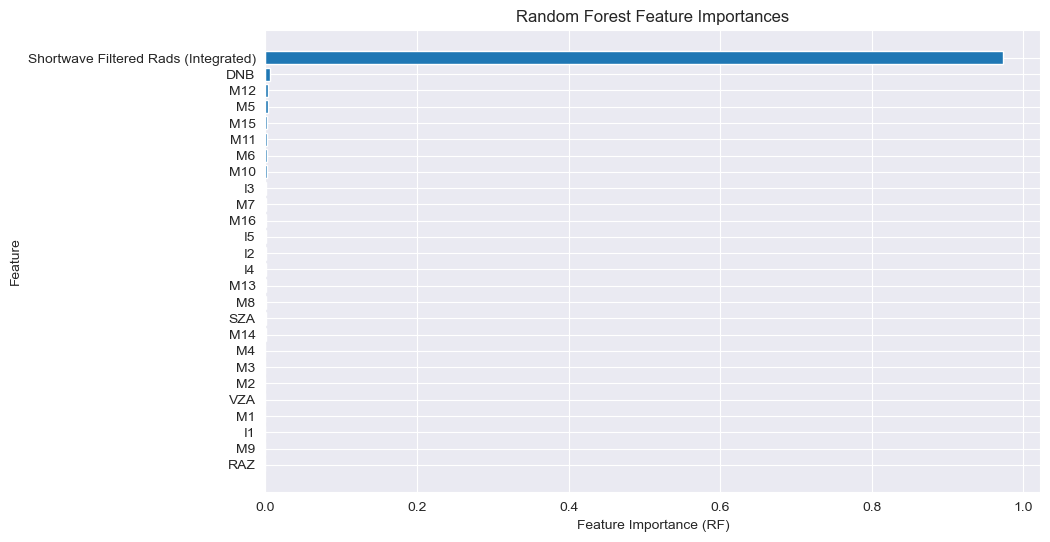

In [24]:
importances = best_model.feature_importances_
features = ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']  # or list of your feature names
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Plot as heatmap or bar chart
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance (RF)")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
["DNB", "M12", "M5", "M15", "M11", "M6", "M10"]

In [26]:
sorted(importances)

[1.3298297366188652e-06,
 2.6498894036175756e-05,
 4.774121623627641e-05,
 7.353193211069833e-05,
 7.76541012170469e-05,
 8.645415896182658e-05,
 0.00011291350444928656,
 0.00011532234393902786,
 0.0001706260217015887,
 0.00020816053141790131,
 0.00027866063790324663,
 0.0004824280631530782,
 0.0005766984421733005,
 0.0007767437866162427,
 0.0008084856724847171,
 0.0008584254050904617,
 0.0009008940888917693,
 0.0009794905131231277,
 0.0016254156179755298,
 0.002009856189832712,
 0.0021935226560649886,
 0.002200818792097539,
 0.003083461708315662,
 0.0032527142521665744,
 0.005412414735686504,
 0.973639736904618]

In [32]:
no_bands_res_unscaled_rf = run_shortwave_regression_model_scaled(all_dataset, scaled=False, rf=True, v=True, viirs_bands=False, noised=False, neurons=100, tree_depth=10)
no_bands_model = no_bands_res_unscaled_rf[0]['Model']

Input Features Index(['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)'], dtype='object'), Prediction feature Index(['Shortwave Unfiltered Rads (Integrated)'], dtype='object')


In [33]:
X_mtest_no_bands_data = matt_test_data[['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)']]
sw_input = matt_test_data[['Shortwave Filtered Rads (Integrated)']].to_numpy()
Y_mtest_true_data = matt_test_data[['Shortwave Unfiltered Rads (Integrated)']].to_numpy().ravel()
Y_mtest_pred_data_no_bands = no_bands_model.predict(X_mtest_no_bands_data)
Y_mtest_true_data.ravel()
mtest_no_bands_pe = ( (Y_mtest_pred_data_no_bands - Y_mtest_true_data) / Y_mtest_true_data) * 100
mtest_no_bands_pe

array([ 0.13787737,  0.07789246, -0.08469551, -0.03366614, -0.75814639,
        0.01072789,  0.12516302, -0.02471819,  0.43158183,  0.0580642 ,
        0.22184966, -0.00473598, -0.67968039,  0.01635407,  0.25561809,
       -0.0137318 ,  0.00606229,  0.07731285,  0.25565392, -0.01373454,
       -0.56811075,  0.3962681 ,  0.48300629,  0.03398505])

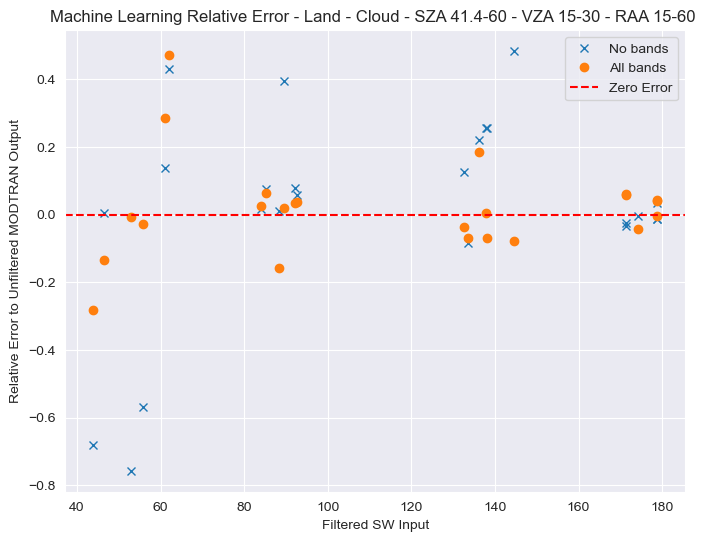

In [38]:
plt.figure(figsize=(8, 6))
plt.plot(sw_input, mtest_no_bands_pe, "x", label='No bands')
plt.plot(sw_input, mtest_pe, "o", label='All bands')
plt.axhline(0, color='red', linestyle='--', label='Zero Error')
plt.title("Machine Learning Relative Error - Land - Cloud - SZA 41.4-60 - VZA 15-30 - RAA 15-60 ")
plt.ylabel("Relative Error to Unfiltered MODTRAN Output")
plt.xlabel("Filtered SW Input")
plt.legend()
plt.show()

In [30]:
# def run_shortwave_regression_model_scaled(dataset: pd.DataFrame, v: bool, viirs_bands: bool, neurons: int = 100, tree_depth: int = 10):
#     """
#     takes in a dataset, runs random forest regressor on the dataset and returns all results
#     :param just_bands:
#     :param dataset:
#     :return all results (RMSE, RMSPE):
#     """
#     ret = {}
#     base_model = None
#
#     X, y = None, None
#
#     columns_to_drop = ["Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",
#                       "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)",
#                       'Scaled Longwave Unfiltered', 'Scaled Longwave Filtered', 'Scaled Shortwave Unfiltered', "Cloud",
#                        'Scaled Shortwave Filtered',]
#
#     # print(dataset.columns)
#
#     if not viirs_bands:
#         columns_to_drop.extend(['M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9',
#                               'I3', 'M10', 'M11', 'I4', 'M1', 'M2', 'M3', 'M4', 'I1'])
#
#
#     X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)
#
#     # in y we should only have the unfiltered ground truth data
#     y = dataset.drop(columns=["Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
#                                'Shortwave Filtered Rads (Integrated)', "Longwave Unfiltered Rads (Integrated)", 'Scaled Longwave Unfiltered',
#                                'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'Scaled Longwave Filtered',
#                                'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'Scaled Shortwave Unfiltered', 'Scaled Shortwave Filtered',
#                                'M12', 'M13', 'M14', 'M15', 'I5', 'M16']).reset_index(drop=True)
#
#     if v:
#         print(f"Input Features {X.columns}, Prediction feature {y.columns}")
#
#
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
#     X_train, X_test, y_train, y_test = X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()
#
#     params = {'bootstrap': True,
#             'max_depth': 12,
#             'max_features': None,
#             'max_samples': 0.8,
#             'min_samples_leaf': 2,
#             'min_samples_split': 5,
#             'n_estimators': 100}
#
#
#     regression_model = RandomForestRegressor(**params)
#     regression_model.fit(X_train, y_train)
#     y_pred = regression_model.predict(X_test)
#     rmse = root_mean_squared_error(y_test, y_pred)
#     mae = mean_absolute_error(y_test, y_pred)
#     mape = mean_absolute_percentage_error(y_test, y_pred) * 100
#     # mae_percentage = (1 - (mae / np.mean(y_pred))) * 100
#     ret["Mean_Absolute_Percentage_Error"] = mape
#     ret["Root_Mean_Squared_Error"] = rmse
#     ret["Mean_Absolute_Error"] = mae
#     ret["Accuracy"] = 100 - mape
#     # ret["MAEP"] = mae_percentage
#
#     # tg_range_sw = max(y_test["Shortwave Unfiltered Rads (Integrated)"]) - min(y_test["Shortwave Unfiltered Rads (Integrated)"])
#     # ret["Shortwave MSPE"] = (1.0 - (rmse / tg_range_sw)) * 100
#
#     cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
#     cv_scores_r2 = cross_val_score(regression_model, X, y, cv=5, scoring="r2")
#     ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
#     ret["Cross_Validated_R_Squared"] = cv_scores_r2
#     ret["R_Squared"] = r2_score(y_test, y_pred)
#
#     ret["Model"] = regression_model
#
#     return [ret, y_pred, y_test]
def test_viirs_bands(
    dataset: pd.DataFrame,
    v: bool,
    viirs_bands: bool,
    is_sw: bool = True,
    selected_viirs_bands: list[str] | None = None
):
    """
    Takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param dataset: input DataFrame
    :param v: verbose flag
    :param viirs_bands: whether to include *all* VIIRS bands
    :param neurons: (unused here, but kept for future NN extension)
    :param tree_depth: (unused here, but kept for consistency)
    :param selected_viirs_bands: list of specific VIIRS band column names to include
    :return: [results dict, y_pred, y_test]
    """
    ret = {}
    base_model = None

    if is_sw:
        columns_to_drop = [
        "Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",
        "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)",
        "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
        "Scaled Shortwave Unfiltered", "Cloud", "Scaled Shortwave Filtered",
    ]
    else:
        columns_to_drop = [
            "Run #", "Scene", "Longwave Unfiltered Rads (Integrated)",
            "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)",
            "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered", "Cloud", "Scaled Shortwave Filtered",
        ]

    # All VIIRS bands in your dataset
    all_viirs_bands = [
        'M1','M2','M3','M4','I1',
        'M5','DNB','M6','I2','M7','M8','M9','I3','M10','M11','I4',
        'M12','M13','M14','M15','I5','M16'
    ]

    # Handle VIIRS band selection
    if not viirs_bands:
        # Drop all VIIRS bands
        columns_to_drop.extend(all_viirs_bands)
    elif selected_viirs_bands is not None:
        # Drop only VIIRS bands not in the selected list
        bands_to_drop = [b for b in all_viirs_bands if b not in selected_viirs_bands]
        columns_to_drop.extend(bands_to_drop)
        if v:
            print(f"Using selected VIIRS bands: {selected_viirs_bands}")
    else:
        # viirs_bands=True and no specific list → keep all bands
        if v:
            print("Using all VIIRS bands")

    # Define X (inputs) and y (targets)
    X = dataset.drop(columns=columns_to_drop).reset_index(drop=True)
    if is_sw:
        y = dataset.drop(columns=[
            "Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
            "Shortwave Filtered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)",
            "Scaled Longwave Unfiltered", "Longwave Filtered Rads (Integrated)",
            "Scaled Longwave Filtered", "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered"
        ] + all_viirs_bands).reset_index(drop=True)
    else:
        y = dataset.drop(columns=[
            "Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
            "Shortwave Filtered Rads (Integrated)", "Shortwave Unfiltered Rads (Integrated)",
            "Scaled Longwave Unfiltered", "Longwave Filtered Rads (Integrated)",
            "Scaled Longwave Filtered", "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered"
        ] + all_viirs_bands).reset_index(drop=True)

    if v:
        print(f"Input Features: {list(X.columns)}")
        print(f"Prediction Feature(s): {list(y.columns)}")

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=True
    )

    # Convert to numpy arrays
    X_train, X_test, y_train, y_test = (
        X_train.to_numpy(), X_test.to_numpy(), y_train.to_numpy(), y_test.to_numpy()
    )

    # Random Forest model
    params = {
        'max_depth': 16,
        'max_features': 'log2',
        'max_samples': None,
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'n_estimators': 600
    }

    regression_model = RandomForestRegressor(**params)
    regression_model.fit(X_train, y_train)
    y_pred = regression_model.predict(X_test)

    # Metrics
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    ret["Mean_Absolute_Percentage_Error"] = mape
    ret["Root_Mean_Squared_Error"] = rmse
    ret["Mean_Absolute_Error"] = mae
    ret["Accuracy"] = 100 - mape

    # Cross-validation
    cv_scores = cross_val_score(regression_model, X, y, cv=5, scoring="neg_root_mean_squared_error")
    cv_scores_r2 = cross_val_score(regression_model, X, y, cv=5, scoring="r2")
    ret["Cross_Validated_Root_Mean_Squared_Error"] = -cv_scores
    ret["Cross_Validated_R_Squared"] = cv_scores_r2
    ret["R_Squared"] = r2_score(y_test, y_pred)
    ret["Model"] = regression_model

    return [ret, y_pred, y_test]

from typing import List, Optional, Dict, Any, Tuple
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, r2_score
)



In [157]:
def calculate_pe(dataset, input_features, model, is_sw = True):
    X_test_data = dataset[input_features]
    if is_sw:
        Y_test_true_data = dataset[['Shortwave Unfiltered Rads (Integrated)']].to_numpy().ravel()
    else:
        Y_test_true_data = dataset[['Longwave Unfiltered Rads (Integrated)']].to_numpy().ravel()
    Y_test_pred_data = model.predict(X_test_data)
    Y_test_true_data.ravel()
    test_pe = ( (Y_test_pred_data - Y_test_true_data) / Y_test_true_data) * 100
    print(np.shape(test_pe), test_pe)
    return test_pe

def display_pe(sw_input, pe1, pe2, pe1_label, pe2_label):
    plt.figure(figsize=(8, 6))
    plt.plot(sw_input, pe1, "x", label=pe1_label)
    plt.plot(sw_input, pe2, "o", label=pe2_label)
    plt.axhline(0, color='red', linestyle='--', label='Zero Error')
    plt.title("Machine Learning Relative Error - Land - Cloud - SZA 41.4-60 - VZA 15-30 - RAA 15-60 ")
    plt.ylabel("Relative Error to Unfiltered MODTRAN Output")
    plt.xlabel("Filtered SW Input")
    plt.legend()
    plt.show()

Using selected VIIRS bands: ['DNB']
Input Features: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'DNB']
Prediction Feature(s): ['Shortwave Unfiltered Rads (Integrated)']
(24,) [ 0.25804902  0.07944558 -0.03959525  0.00760786 -0.08473115 -0.12012111
 -0.01020318 -0.00291986  0.31490613  0.12787366  0.09424686  0.00576647
 -0.23092478  0.04041929  0.06006333  0.05159956  0.03197826  0.08224276
 -0.01115579  0.05159681 -0.40114757  0.06676432  0.0278626   0.04839667]


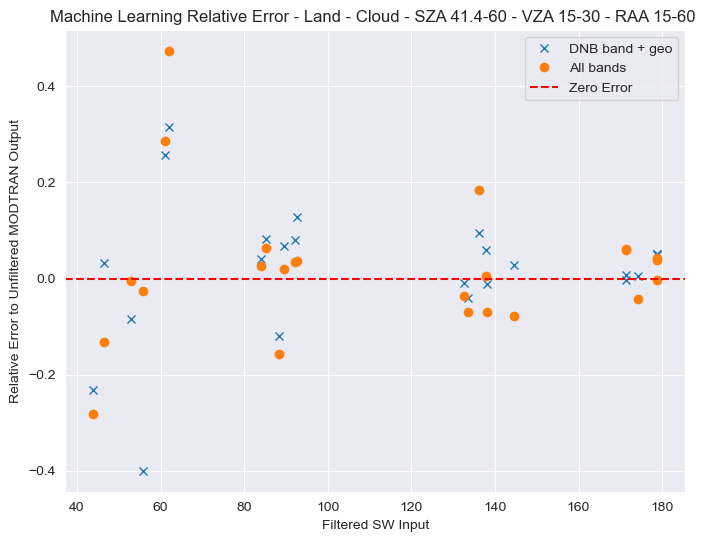

In [45]:
bands_dnb_res = test_viirs_bands(all_dataset, v=True, viirs_bands=True, neurons=100, tree_depth=10, selected_viirs_bands=['DNB'])
dnb_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'DNB'], bands_dnb_res[0]['Model'])
display_pe(sw_input, dnb_pe, mtest_pe, "DNB band + geo", "All bands")

Using selected VIIRS bands: ['DNB', 'M12']
Input Features: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'DNB', 'M12']
Prediction Feature(s): ['Shortwave Unfiltered Rads (Integrated)']
(24,) [ 3.71024466e-01  1.18294213e-01 -5.73174149e-02  7.34182014e-03
 -2.73504146e-03 -1.52121933e-01  7.86876103e-02 -3.01374781e-04
  3.44284508e-01  1.36311643e-01  5.20809529e-02  8.05547782e-02
 -3.05949380e-01  3.53593092e-02  8.63666541e-03 -4.15425741e-03
 -1.44311481e-01  6.96902584e-02  3.45468107e-02 -4.15699614e-03
 -1.59510816e-01  1.07416979e-01  3.16384659e-02  2.33074544e-02]


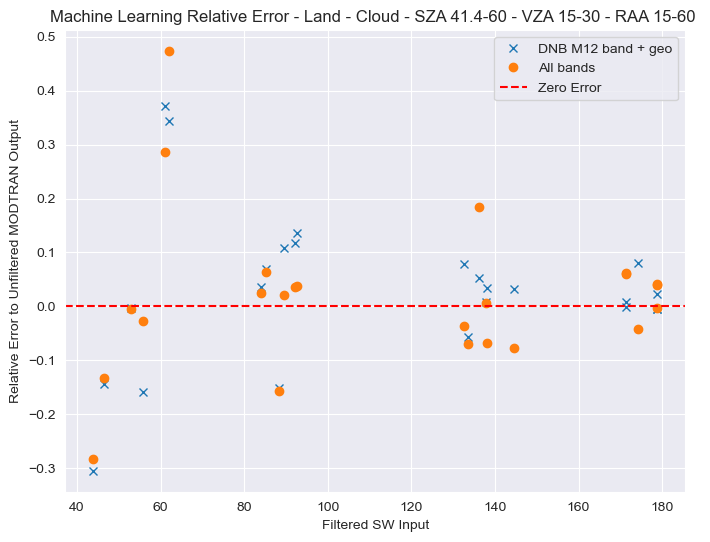

In [46]:
bands_dnb_m12_res = test_viirs_bands(all_dataset, v=True, viirs_bands=True, neurons=100, tree_depth=10, selected_viirs_bands=['DNB', "M12"])
dnb_m12_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'DNB', "M12"], bands_dnb_m12_res[0]['Model'])
display_pe(sw_input, dnb_m12_pe, mtest_pe, "DNB M12 band + geo", "All bands")

In [ ]:
, selected_viirs_bands=["DNB", "M12", "M5", "M15", "M11", "M6", "M10"]

Using all VIIRS bands
Input Features: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']
Prediction Feature(s): ['Shortwave Unfiltered Rads (Integrated)']
(24,) [ 0.12722998  0.09879035 -0.02703032  0.01591574  0.23876641 -0.09096766
 -0.00119571  0.01617729  0.31708219  0.03017139  0.07879664  0.05808893
  0.05750778  0.05937351 -0.00866024  0.01270075  0.04142303 -0.26190547
 -0.07585864  0.01269847 -0.05486143 -0.47768952 -0.20067235 -0.08353322]


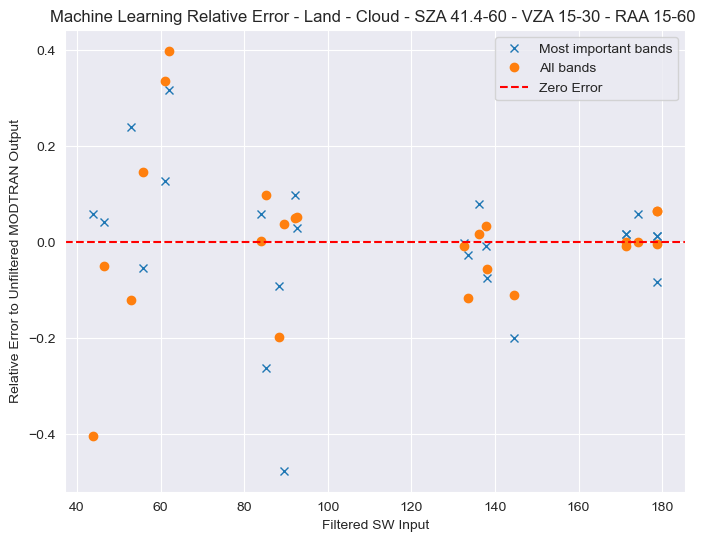

In [70]:
bands_all_important_res = test_viirs_bands(all_dataset, v=True, viirs_bands=True)
bands_all_important_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1','M2','M3','M4','I1',
        'M5','DNB','M6','I2','M7','M8','M9','I3','M10','M11','I4',
        'M12','M13','M14','M15','I5','M16'], bands_all_important_res[0]['Model'])
display_pe(sw_input, bands_all_important_pe, mtest_pe, "Most important bands", "All bands")

Input Features: ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)']
Prediction Feature(s): ['Longwave Unfiltered Rads (Integrated)']
(24,) [-3.60073334e-05  1.20097598e-02  4.07658105e-05  8.24750064e-06
 -7.91660135e-05  1.31718520e-03  1.55884493e-04  8.24750064e-06
 -3.21239096e-05 -6.70676770e-06  1.75411791e-03 -4.66610485e-06
 -9.35570315e-06  5.55698482e-05 -4.15941856e-06 -9.29709570e-07
  4.33895550e-03  3.38277241e-06  1.29699053e-05 -9.03861551e-07
  2.55415376e-03  5.84352862e-06 -1.66940331e-04 -9.32794187e-04]


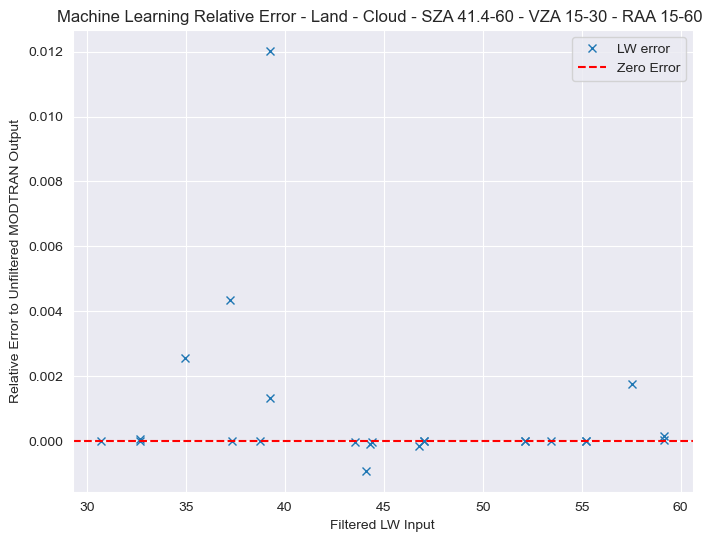

In [78]:
lw_res = test_viirs_bands(all_dataset, v=True, viirs_bands=True, neurons=100, tree_depth=10)
lw_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16'], lw_res[0]['Model'], False)
plt.figure(figsize=(8, 6))
plt.plot(lw_input, lw_pe, "x", label="LW error")
# plt.plot(sw_input, pe2, "o", label=pe2_label)
plt.axhline(0, color='red', linestyle='--', label='Zero Error')
plt.title("Machine Learning Relative Error - Land - Cloud - SZA 41.4-60 - VZA 15-30 - RAA 15-60 ")
plt.ylabel("Relative Error to Unfiltered MODTRAN Output")
plt.xlabel("Filtered LW Input")
plt.legend()
plt.show()

In [76]:
lw_res

[{'Mean_Absolute_Percentage_Error': 0.008211583655933084,
  'Root_Mean_Squared_Error': 0.05276688767699262,
  'Mean_Absolute_Error': 0.006510336769812372,
  'Accuracy': 99.99178841634406,
  'Cross_Validated_Root_Mean_Squared_Error': array([0.09990586, 0.04911124, 0.01108888, 0.01170657, 0.94625003]),
  'Cross_Validated_R_Squared': array([0.99978407, 0.99998852, 0.99999945, 0.99999963, 0.9973489 ]),
  'R_Squared': 0.9999902989942409,
  'Model': RandomForestRegressor(max_depth=12, max_features=None, max_samples=0.8,
                        min_samples_leaf=2, min_samples_split=5)},
 array([57.2024136 , 66.88873384, 67.87631693, ..., 58.87382867,
        90.46841941, 90.48798685]),
 array([[57.20237885],
        [66.88871998],
        [67.89105662],
        ...,
        [58.8714234 ],
        [90.46842516],
        [90.48799797]])]

(24,) [ 0.28688864  0.0349984  -0.06921149  0.06235953 -0.00554671 -0.15610348
 -0.03641416  0.0591793   0.47296167  0.03687131  0.18433624 -0.04173799
 -0.28275183  0.02539971  0.00635739  0.03967357 -0.1324241   0.063379
 -0.06881181  0.04216078 -0.02640547  0.02056006 -0.07803112 -0.00293353]


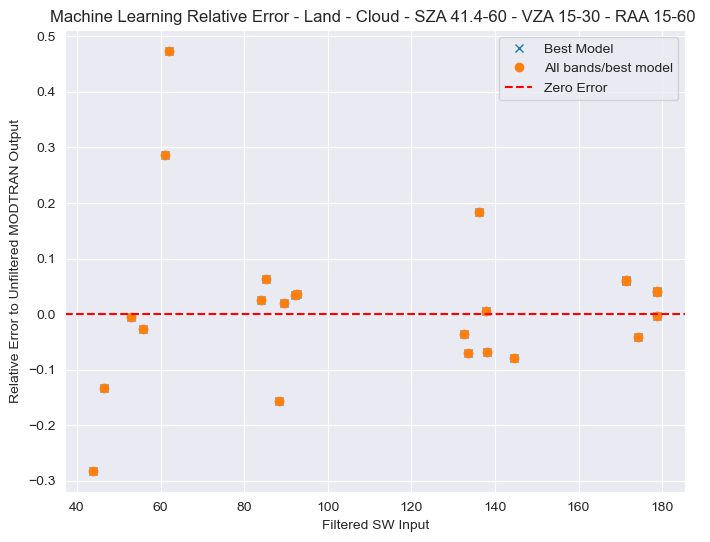

In [84]:
best_model = all_unscaled_res_random_forest[0]["Model"]
best_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16'], best_model)
display_pe(sw_input, best_pe, mtest_pe, "Best Model", "All bands/best model")

Using selected VIIRS bands: ['M5']
Input Features: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M5']
Prediction Feature(s): ['Shortwave Unfiltered Rads (Integrated)']
(24,) [ 0.21151295  0.09721783 -0.15052985  0.03065319 -0.56883599 -0.06436823
 -0.09803126  0.02753174  0.45300213  0.03001114  0.28224515 -0.02298447
 -0.73366388 -0.02048094  0.1159088  -0.02614372  0.09701625  0.12558407
  0.00295458 -0.02614646 -0.16121055  0.23008988 -0.13195585 -0.02837477]


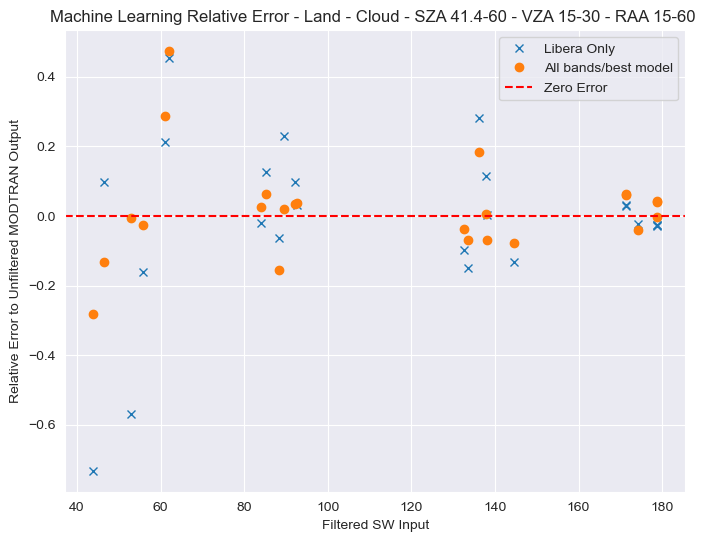

In [82]:
libera_only_sw_model = test_viirs_bands(all_dataset, v=True, viirs_bands=True, neurons=100, tree_depth=10, is_sw=True, selected_viirs_bands=["M5"])
libera_only_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M5'], libera_only_sw_model[0]['Model'])
display_pe(sw_input, libera_only_pe, mtest_pe, "Libera Only", "All bands/best model")

Using selected VIIRS bands: ['M5']
Input Features: ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)', 'M5']
Prediction Feature(s): ['Longwave Unfiltered Rads (Integrated)']
(24,) [-3.37986843e-05  5.92249417e-03  4.67722515e-05  5.58956575e-06
 -7.83813940e-05  1.23613186e-03  1.46091211e-04  5.58956575e-06
 -3.68346324e-05 -5.23818798e-06  7.34272720e-05 -3.73094607e-06
  8.44198181e-07  5.25942187e-05 -6.25509522e-06 -1.07530446e-06
  4.04670472e-03  4.73108442e-06  2.22213114e-05 -1.04945645e-06
  7.69421570e-03  7.71424325e-06 -1.51229166e-04 -1.85606970e-03]


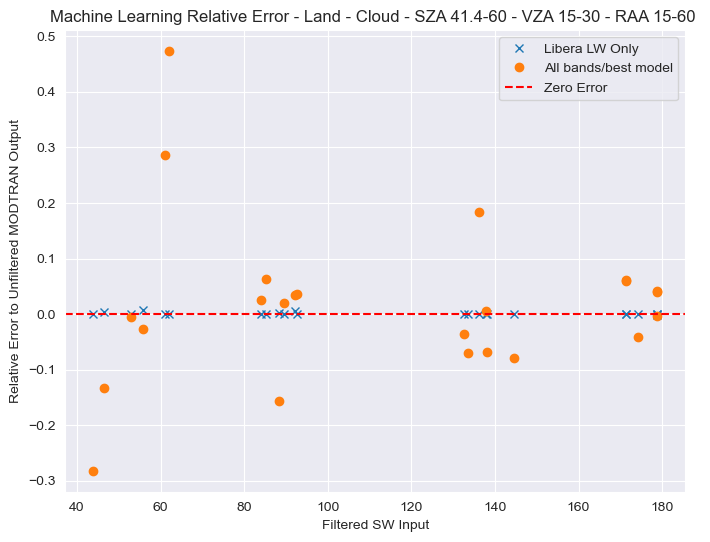

In [86]:
libera_only_lw_model = test_viirs_bands(all_dataset, v=True, viirs_bands=True, neurons=100, tree_depth=10, is_sw=False, selected_viirs_bands=["M5"])
libera_only_lw_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ', 'Longwave Filtered Rads (Integrated)', 'M5'], libera_only_lw_model[0]['Model'], is_sw=False)
display_pe(sw_input, libera_only_lw_pe, mtest_pe, "Libera LW Only", "All bands/best model")

Using all VIIRS bands
Input Features: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']
Prediction Feature(s): ['Shortwave Unfiltered Rads (Integrated)']
(24,) [ 0.17767094  0.05809341 -0.0214659   0.00426584  0.35221746 -0.13795997
 -0.03665702  0.00453834  0.22839458  0.05687855  0.04710094  0.06697814
 -0.03868402  0.04143319 -0.02855612  0.00958701  0.01408844 -0.24569504
 -0.09708425  0.00958464  0.04455732 -0.43671133 -0.1243559  -0.09374565]


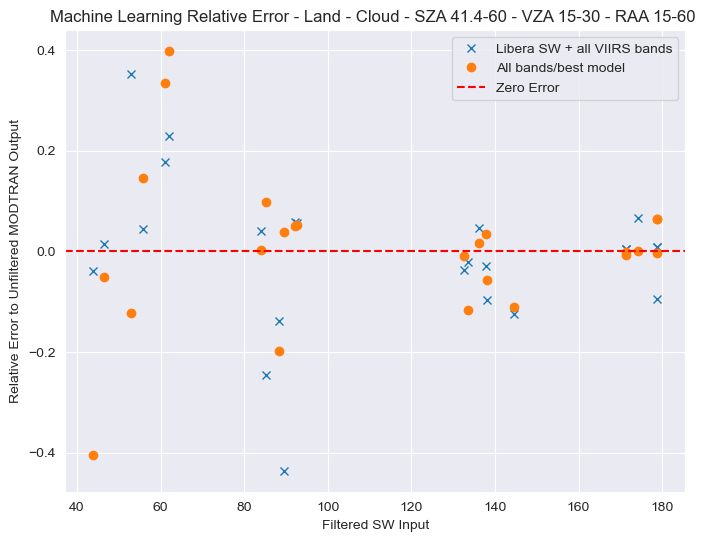

In [72]:
libera_sw_all_bands_model = test_viirs_bands(all_dataset, v=True, viirs_bands=True, is_sw=True)
libera_sw_all_bands_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16'], libera_sw_all_bands_model[0]['Model'])
display_pe(sw_input, libera_sw_all_bands_pe, mtest_pe, "Libera SW + all VIIRS bands", "All bands/best model")

In [73]:
libera_sw_all_bands_model[0]["Cross_Validated_Root_Mean_Squared_Error"]

array([6.18111174, 2.89574577, 1.27708104, 3.15286148, 2.96752029])

In [32]:
all_dataset.shape

(6195, 36)

In [158]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, GroupKFold
from scipy.stats import randint, uniform

def random_grid_search(
    dataset: pd.DataFrame,
    v: bool,
    viirs_bands: bool,
    is_sw: bool = True,
    selected_viirs_bands: list[str] | None = None
):
    """
    Takes in a dataset, runs random forest regressor on the dataset and returns all results
    :param dataset: input DataFrame
    :param v: verbose flag
    :param viirs_bands: whether to include *all* VIIRS bands
    :param neurons: (unused here, but kept for future NN extension)
    :param tree_depth: (unused here, but kept for consistency)
    :param selected_viirs_bands: list of specific VIIRS band column names to include
    :return: [results dict, y_pred, y_test]
    """
    ret = {}
    base_model = None

    if is_sw:
        columns_to_drop = [ "SZA", "VZA", "RAZ",
        "Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",
        "Longwave Unfiltered Rads (Integrated)", "Longwave Filtered Rads (Integrated)",
        "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
        "Scaled Shortwave Unfiltered", "Cloud", "Scaled Shortwave Filtered",
    ]
    else:
        columns_to_drop = [
            "Run #", "Scene", "Longwave Unfiltered Rads (Integrated)",
            "Shortwave Unfiltered Rads (Integrated)", "Shortwave Filtered Rads (Integrated)",
            "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered", "Cloud", "Scaled Shortwave Filtered",
        ]

    # All VIIRS bands in your dataset
    all_viirs_bands = [
        'M1','M2','M3','M4','I1',
        'M5','DNB','M6','I2','M7','M8','M9','I3','M10','M11','I4',
        'M12','M13','M14','M15','I5','M16'
    ]

    # Handle VIIRS band selection
    if not viirs_bands:
        # Drop all VIIRS bands
        columns_to_drop.extend(all_viirs_bands)
    elif selected_viirs_bands is not None:
        # Drop only VIIRS bands not in the selected list
        bands_to_drop = [b for b in all_viirs_bands if b not in selected_viirs_bands]
        columns_to_drop.extend(bands_to_drop)
        if v:
            print(f"Using selected VIIRS bands: {selected_viirs_bands}")
    else:
        # viirs_bands=True and no specific list → keep all bands
        if v:
            print("Using all VIIRS bands")

    # Define X (inputs) and y (targets)
    dataset_ = dataset.reset_index(drop=True)
    X = dataset_.drop(columns=columns_to_drop)
    if is_sw:
        y = dataset_.drop(columns=[
            "Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
            "Shortwave Filtered Rads (Integrated)", "Longwave Unfiltered Rads (Integrated)",
            "Scaled Longwave Unfiltered", "Longwave Filtered Rads (Integrated)",
            "Scaled Longwave Filtered", "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered"
        ] + all_viirs_bands)
    else:
        y = dataset_.drop(columns=[
            "Run #", "Scene", 'SZA', 'VZA', 'RAZ', 'Cloud',
            "Shortwave Filtered Rads (Integrated)", "Shortwave Unfiltered Rads (Integrated)",
            "Scaled Longwave Unfiltered", "Longwave Filtered Rads (Integrated)",
            "Scaled Longwave Filtered", "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered"
        ] + all_viirs_bands)

    if v:
        print(f"Input Features: {list(X.columns)}")
        print(f"Prediction Feature(s): {list(y.columns)}")

    cv = GroupKFold(n_splits=5)
    # groups = dataset_["Run #"]
    groups = dataset_["Scene"].astype(str) + "|" + dataset_["Run #"].astype(str)

    base = RandomForestRegressor(random_state=42, bootstrap=True, oob_score=True)
    rand_params = {
        "n_estimators": [25, 50, 100, 200, 400, 500, 600],           # 150–650
        "max_depth":    [None, 8, 12, 16, 24, 32],
        "min_samples_split": [2,4,6,8,10,12,14,16,18,20,22],         # 2–20
        "min_samples_leaf":  [1,2,3,4,5,6,7,8,9,10,11],         # 1–10
        "max_features": ["sqrt", "log2", 0.3, 0.5],  # avoid None (== all features)
        "max_samples":  [None, 0.7, 0.8, 0.9],       # only used if bootstrap=True
    }
    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae":  "neg_mean_absolute_error",
        "r2":   "r2",
    }
    rs = RandomizedSearchCV(
        estimator=base,
        param_distributions=rand_params,
        n_iter=60,                # adjust if you want broader/narrower
        cv=cv,
        scoring=scoring,
        refit="rmse",
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
        random_state=42,
    )
    # groups = your grouping Series, e.g., dataset["Run #"] or scene/geometry bins
    rs.fit(X, y, groups=groups)

    ret["rand_best_params"] = rs.best_params_
    ret["rand_cv_rmse"] = -rs.best_score_

    best = rs.best_params_
    grid = {
        "n_estimators": [max(100, best["n_estimators"]//2),
                         best["n_estimators"],
                         best["n_estimators"]*2, 600, 800, 1000],
        "max_depth": list({best["max_depth"], None, 8, 12, 16, 24}) if best["max_depth"] is not None else [None, 12, 16, 24],
        "min_samples_split": sorted({max(2, best["min_samples_split"]-2),
                                     best["min_samples_split"],
                                     best["min_samples_split"]+2}),
        "min_samples_leaf":  sorted({max(1, best["min_samples_leaf"]-1),
                                     best["min_samples_leaf"],
                                     best["min_samples_leaf"]+1}),
        "max_features": [best["max_features"]] if best["max_features"] in ["sqrt","log2"] else ["sqrt", best["max_features"]],
        "max_samples":  [best.get("max_samples", None)],
    }
    gs = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42, bootstrap=True, oob_score=True),
        param_grid=grid,
        cv=cv,
        scoring=scoring,
        refit="rmse",
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )
    gs.fit(X, y, groups=groups)

    ret["grid_best_params"] = gs.best_params_
    ret["grid_cv_rmse"] = -gs.best_score_

    return ret

In [24]:
gridsearch_sw = random_grid_search(all_dataset, v=True, viirs_bands=True, is_sw=True)

Using all VIIRS bands
Input Features: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']
Prediction Feature(s): ['Shortwave Unfiltered Rads (Integrated)']
Fitting 5 folds for each of 60 candidates, totalling 300 fits


/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

Fitting 5 folds for each of 270 candidates, totalling 1350 fits


/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/envs/test/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Pleas

In [25]:
gridsearch_sw

{'rand_best_params': {'n_estimators': 200,
  'min_samples_split': 4,
  'min_samples_leaf': 2,
  'max_samples': None,
  'max_features': 'log2',
  'max_depth': 16},
 'rand_cv_rmse': 1.3073357285675402,
 'grid_best_params': {'max_depth': 16,
  'max_features': 'log2',
  'max_samples': None,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 600},
 'grid_cv_rmse': 1.1631802925494614}

{'best_params': {'max_depth': None,
  'max_features': 0.5,
  'max_samples': 0.9,
  'min_samples_leaf': 1,
  'min_samples_split': 3,
  'n_estimators': 25},
 'cv_rmse': 1.0970572158778877}

rand_params = {
    "n_estimators": randint(150, 650),           # 150–650
    "max_depth":    [None, 8, 12, 16, 24, 32],
    "min_samples_split": randint(2, 21),         # 2–20
    "min_samples_leaf":  randint(1, 11),         # 1–10
    "max_features": ["sqrt", "log2", 0.3, 0.5],  # avoid None (== all features)
    "max_samples":  [None, 0.7, 0.8, 0.9],       # only used if bootstrap=True
}

{'best_params': {'n_estimators': 200,
  'min_samples_split': 4,
  'min_samples_leaf': 2,
  'max_samples': None,
  'max_features': 'log2',
  'max_depth': 16},
 'cv_rmse': 1.3073357285675402}

rand_params = {
        "n_estimators": [25, 50, 100, 200, 400, 500, 600],           # 150–650
        "max_depth":    [None, 8, 12, 16, 24, 32],
        "min_samples_split": [2,4,6,8,10,12,14,16,18,20,22],         # 2–20
        "min_samples_leaf":  [1,2,3,4,5,6,7,8,9,10,11],         # 1–10
        "max_features": ["sqrt", "log2", 0.3, 0.5],  # avoid None (== all features)
        "max_samples":  [None, 0.7, 0.8, 0.9],       # only used if bootstrap=True
    }


{'rand_best_params': {'n_estimators': 200,
  'min_samples_split': 4,
  'min_samples_leaf': 2,
  'max_samples': None,
  'max_features': 'log2',
  'max_depth': 16},
 'rand_cv_rmse': 1.3073357285675402,
 'grid_best_params': {'max_depth': 16,
  'max_features': 'log2',
  'max_samples': None,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 600},
 'grid_cv_rmse': 1.1631802925494614}


In [57]:
all_dataset["Run #"]

0        0
1        1
2        2
3        3
4        4
      ... 
142    142
143    143
144    144
145    145
146    146
Name: Run #, Length: 6195, dtype: int64

In [203]:
from sklearn.linear_model import LinearRegression

def test_viirs_bands(
    dataset: pd.DataFrame,
    v: bool,
    viirs_bands: bool,
    is_sw: bool = True,
    selected_viirs_bands: list[str] | None = None,
    best_params: dict | None = None,
    use_groups: bool = True,         # <- IMPORTANT: use grouped CV by default
    n_splits: int = 5
):
    ret = {}
    dataset_ = dataset.reset_index(drop=True)

    target_col = "Shortwave Unfiltered Rads (Integrated)" if is_sw else "Longwave Unfiltered Rads (Integrated)"
    filtered_sw = "Shortwave Filtered Rads (Integrated)"
    filtered_lw = "Longwave Filtered Rads (Integrated)"

    # Base columns to drop from X (do NOT include the target here)
    if is_sw:
        columns_to_drop = [
            "Run #", "Scene", "Shortwave Unfiltered Rads (Integrated)",
            "Longwave Unfiltered Rads (Integrated)", filtered_lw,
            "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered",
            "Cloud"
        ]
    else:
        columns_to_drop = [
            "Run #", "Scene",
            "Shortwave Unfiltered Rads (Integrated)", filtered_sw,
            "Scaled Longwave Unfiltered", "Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered", "Scaled Shortwave Filtered",
            "Cloud"
        ]

    all_viirs_bands = [ 'SZA', 'VZA', 'RAZ',
        'M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9',
        'I3','M10','M11','I4','M12','M13','M14','M15','I5','M16'
    ]

    # Handle VIIRS band selection for X
    if not viirs_bands:
        columns_to_drop.extend(all_viirs_bands)
    elif selected_viirs_bands is not None:
        columns_to_drop.extend([b for b in all_viirs_bands if b not in selected_viirs_bands])
        if v: print(f"Using selected VIIRS bands: {selected_viirs_bands}")
    else:
        if v: print("Using all VIIRS bands.")

    # --- Build X, y, groups from the SAME frame (no extra resets) ---
    X = dataset_.drop(columns=columns_to_drop, errors="ignore")
    y = dataset_[target_col]            # 1-D Series (robust)
    sza = pd.cut(dataset_["SZA"], [0,15,30,45,60,75,90], right=False, include_lowest=True)
    vza = pd.cut(dataset_["VZA"], [0,15,30,45,60,75,90], right=False, include_lowest=True)
    raz = pd.cut(dataset_["RAZ"], [0,60,120,180], right=False, include_lowest=True)
    groups = dataset_["Scene"].astype(str) + "|" + dataset_["Run #"].astype(str)

    R = dataset_[target_col] / dataset_["Shortwave Filtered Rads (Integrated)"]
    lr = LinearRegression().fit(dataset_[["SZA","VZA","RAZ"]], R)
    print("R^2 ratio ~ angles:", lr.score(dataset_[["SZA","VZA","RAZ"]], R))

    if v:
        print(f"Target: {target_col}")
        print(f"X shape: {X.shape}, y shape: {y.shape}")
        print(f"Features: {list(X.columns)}")

    # Holdout metrics (optional) — keep if you want a quick sanity check
    from sklearn.model_selection import train_test_split
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


    # Use your tuned params; add defaults that grid didn’t include explicitly
    params = best_params or {
        'max_depth': 16,
        'max_features': 'log2',
        'max_samples': None,
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'n_estimators': 600
    }
    # ensure deterministic fit behavior
    params.setdefault("random_state", 42)
    params.setdefault("bootstrap", True)  # RF default, but make explicit

    model = RandomForestRegressor(**params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    rmse = root_mean_squared_error(y_te, y_pred)
    mae  = mean_absolute_error(y_te, y_pred)
    mape = mean_absolute_percentage_error(y_te, y_pred) * 100.0
    r2   = r2_score(y_te, y_pred)

    ret["Holdout_RMSE"] = rmse
    ret["Holdout_MAE"]  = mae
    ret["Holdout_MAPE%"] = mape
    ret["Holdout_R2"]   = r2

    # --- Cross-validation: FREEZE the folds and use groups (identical to search) ---
    if use_groups:
        splitter = GroupKFold(n_splits=n_splits)
        folds = list(splitter.split(X, y, groups))
    else:
        # if you *really* want plain KFold:
        from sklearn.model_selection import KFold
        folds = list(KFold(n_splits=n_splits, shuffle=True, random_state=42).split(X, y))

    cv_scores_neg = cross_val_score(
        RandomForestRegressor(**params),
        X, y, cv=folds,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    fold_rmses = -cv_scores_neg

    ret["CV_Fold_RMSEs"] = fold_rmses
    ret["CV_RMSE_mean"] = float(np.mean(fold_rmses))
    ret["CV_RMSE_std"]  = float(np.std(fold_rmses, ddof=1)) if len(fold_rmses) > 1 else 0.0
    ret["Params_Used"]  = params
    ret["Model"] = model

    return ret


In [204]:
best = {'max_depth': 16, 'max_features': 'log2', 'max_samples': None,
        'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 800}

rep = test_viirs_bands(all_dataset, v=True, viirs_bands=True, is_sw=True, best_params=best, use_groups=True)
print(rep["CV_Fold_RMSEs"], rep["CV_RMSE_mean"], rep["CV_RMSE_std"])

Using all VIIRS bands.
R^2 ratio ~ angles: 0.05956706063329931
Target: Shortwave Unfiltered Rads (Integrated)
X shape: (6195, 26), y shape: (6195,)
Features: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']
[0.8350788  1.13153024 1.09011411 1.17194396 0.92464987] 1.0306633946418293 0.14418816407806762


Groups Geom : CV Fold RMSEs, RMSE mean/std[3.48916216 0.90654177 6.63378085 1.4664296  0.90208765] 2.679600405399626 2.4528557429896076
Groups : : CV Fold RMSEs, RMSE mean/std [0.83438134 1.13045302 1.09032072 1.18875297 0.94326342] 1.0374342925621334 0.1452974988325347

Using selected VIIRS bands: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']
R^2 ratio ~ angles: 0.05956706063329931
Target: Shortwave Unfiltered Rads (Integrated)
X shape: (6195, 26), y shape: (6195,)
Features: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']
(24,) [ 0.15840458  0.09922388 -0.0101015   0.01204999  0.19974649  0.00354421
 -0.03557182  0.01231946  0.16829289 -0.00390476  0.05882337  0.05517553
 -0.10618248  0.04370847 -0.02652612  0.00347285 -0.01026278 -0.22130886
 -0.0897199   0.0034706  -0.26351741 -0.31125827 -0.16535482 -0.05688342]


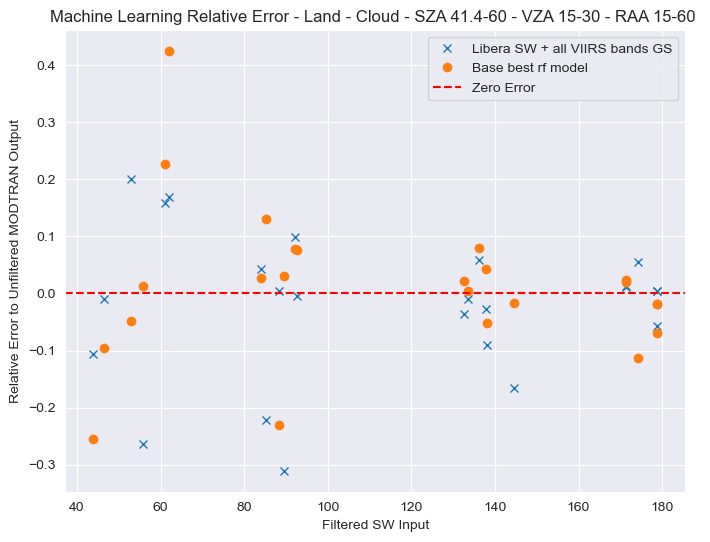

In [205]:
best_model_gs = test_viirs_bands(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 selected_viirs_bands=['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14',
                                                       'M15', 'I5', 'M16'],  best_params=best, use_groups=True)

best_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16'], best_model_gs['Model'])

display_pe(sw_input, best_pe, mtest_pe, "Libera SW + all VIIRS bands GS", "Base best rf model")

In [206]:
best_model_gs

{'Holdout_RMSE': 1.0431794337042184,
 'Holdout_MAE': 0.4257860327920878,
 'Holdout_MAPE%': 0.6038259919948685,
 'Holdout_R2': 0.9998680730838059,
 'CV_Fold_RMSEs': array([0.8350788 , 1.13153024, 1.09011411, 1.17194396, 0.92464987]),
 'CV_RMSE_mean': 1.0306633946418293,
 'CV_RMSE_std': 0.14418816407806762,
 'Params_Used': {'max_depth': 16,
  'max_features': 'log2',
  'max_samples': None,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 800,
  'random_state': 42,
  'bootstrap': True},
 'Model': RandomForestRegressor(max_depth=16, max_features='log2', n_estimators=800,
                       random_state=42)}

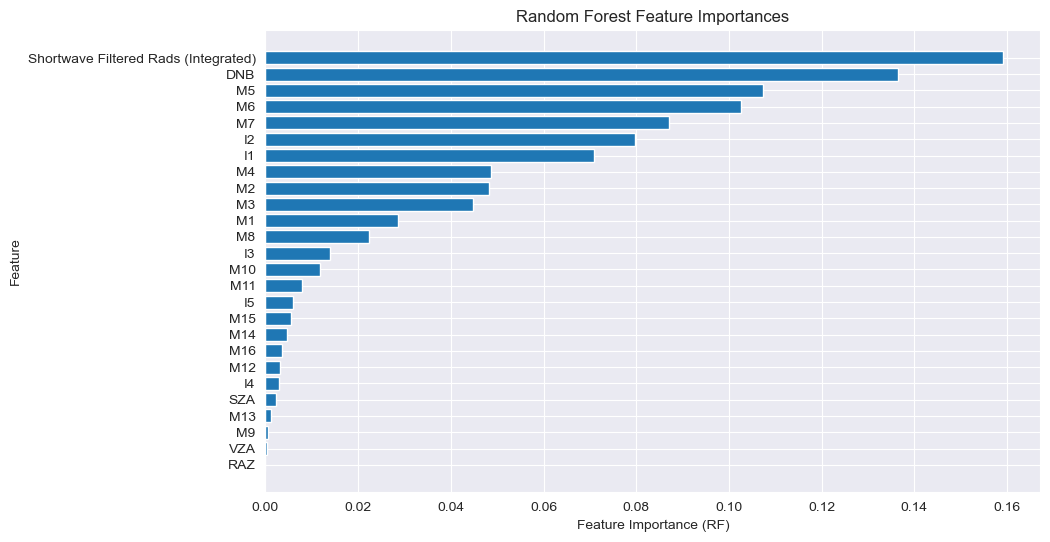

In [129]:
importances = best_model_gs["Model"].feature_importances_
features = best_model_gs["Model"].feature_names_in_
importance_df = (
    pd.Series(importances, index=features)
      .sort_values(ascending=False)
      .rename_axis("Feature")
      .reset_index(name="Importance")
)

# Plot as heatmap or bar chart
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance (RF)")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()

Using selected VIIRS bands: ['Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
R^2 ratio ~ angles: 0.05956706063329931
Target: Shortwave Unfiltered Rads (Integrated)
X shape: (6195, 16), y shape: (6195,)
Features: ['Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
(24,) [ 0.10133259  0.05501955 -0.00446134  0.03473879  0.1654656  -0.12963932
 -0.09142563  0.03500239  0.2269449   0.06424732  0.07076394  0.06970737
 -0.08199949  0.05052657 -0.03090946  0.02246802  0.0074382  -0.10090132
 -0.10012917  0.0224658  -0.01426808 -0.11643633 -0.15263136 -0.05359175]


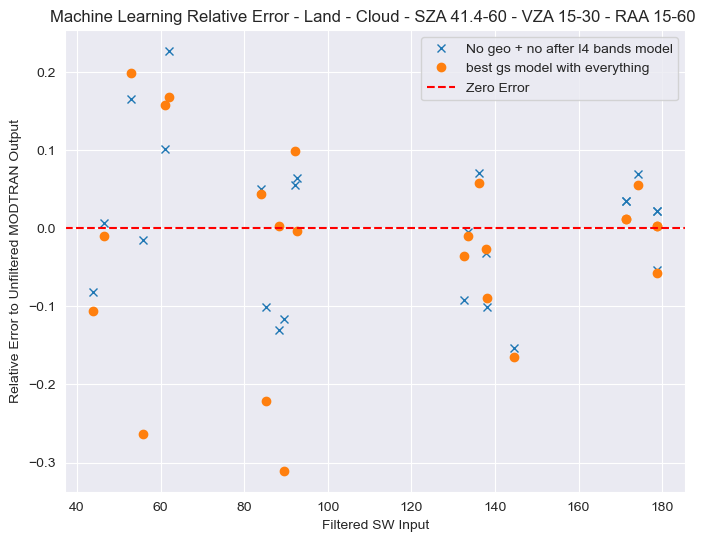

In [207]:
gs_no_geo_no_i4_model = test_viirs_bands(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 selected_viirs_bands=['Shortwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=best, use_groups=True)

gs_no_geo_no_i4_pe = calculate_pe(matt_test_data, ['Shortwave Filtered Rads (Integrated)',
                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                        'M8', 'M9', 'I3', 'M10', 'M11'], gs_no_geo_no_i4_model['Model'])

display_pe(sw_input, gs_no_geo_no_i4_pe, best_pe, "No geo + no after I4 bands model", "best gs model with everything")

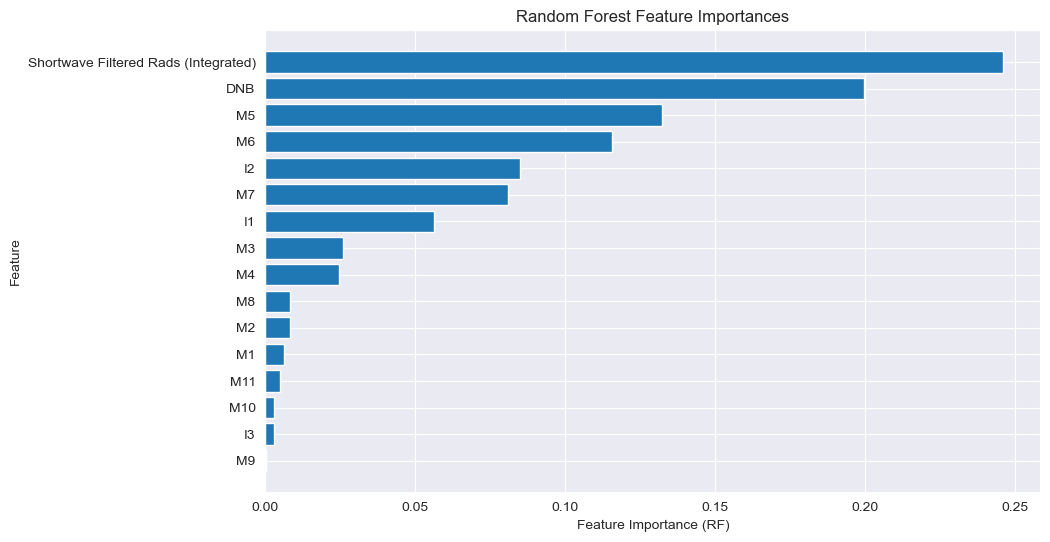

In [92]:
importances = gs_no_geo_no_i4_model["Model"].feature_importances_
features = gs_no_geo_no_i4_model["Model"].feature_names_in_
importance_df = (
    pd.Series(importances, index=features)
      .sort_values(ascending=False)
      .rename_axis("Feature")
      .reset_index(name="Importance")
)

# Plot as heatmap or bar chart
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance (RF)")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()

Using selected VIIRS bands: ['Shortwave Filtered Rads (Integrated)', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7']
R^2 ratio ~ angles: 0.05956706063329931
Target: Shortwave Unfiltered Rads (Integrated)
X shape: (6195, 7), y shape: (6195,)
Features: ['Shortwave Filtered Rads (Integrated)', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7']
(24,) [ 0.13172822  0.09405181  0.03825779  0.0413289   0.31924168 -0.15852633
 -0.12611704  0.04157587  0.30421875  0.1295101   0.04105439  0.05238976
 -0.19723985  0.02706807 -0.0521307   0.00690879  0.06625144  0.06011052
 -0.07951648  0.0069065   0.19030155  0.00860873 -0.20077274 -0.0177017 ]


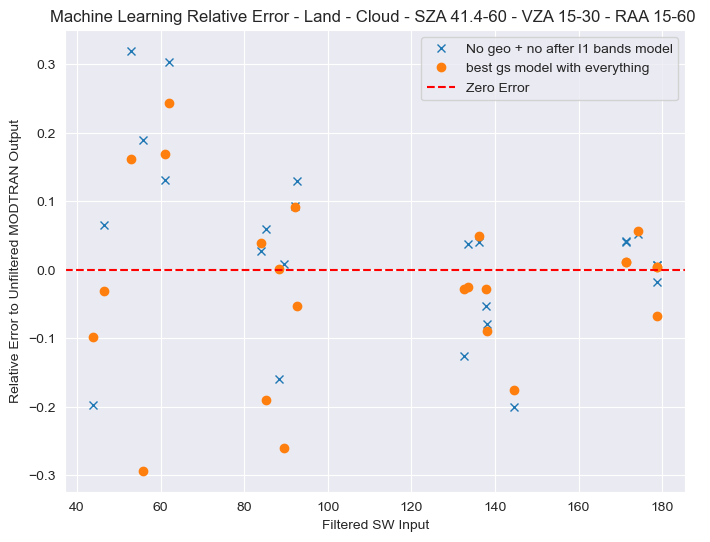

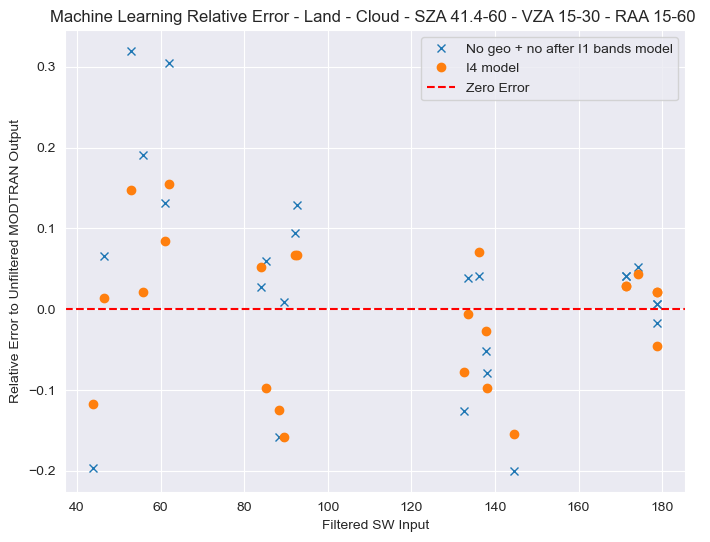

In [93]:
gs_no_geo_no_i1_model = test_viirs_bands(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 selected_viirs_bands=['Shortwave Filtered Rads (Integrated)',
                                                       'I1', 'M5', 'DNB', 'M6', 'I2', 'M7'],  best_params=best, use_groups=True)

gs_no_geo_no_i1_pe = calculate_pe(matt_test_data, ['Shortwave Filtered Rads (Integrated)',
                                                       'I1', 'M5', 'DNB', 'M6', 'I2', 'M7'], gs_no_geo_no_i1_model['Model'])

display_pe(sw_input, gs_no_geo_no_i1_pe, best_pe, "No geo + no after I1 bands model", "best gs model with everything")
display_pe(sw_input, gs_no_geo_no_i1_pe, gs_no_geo_no_i4_pe, "No geo + no after I1 bands model", "I4 model")

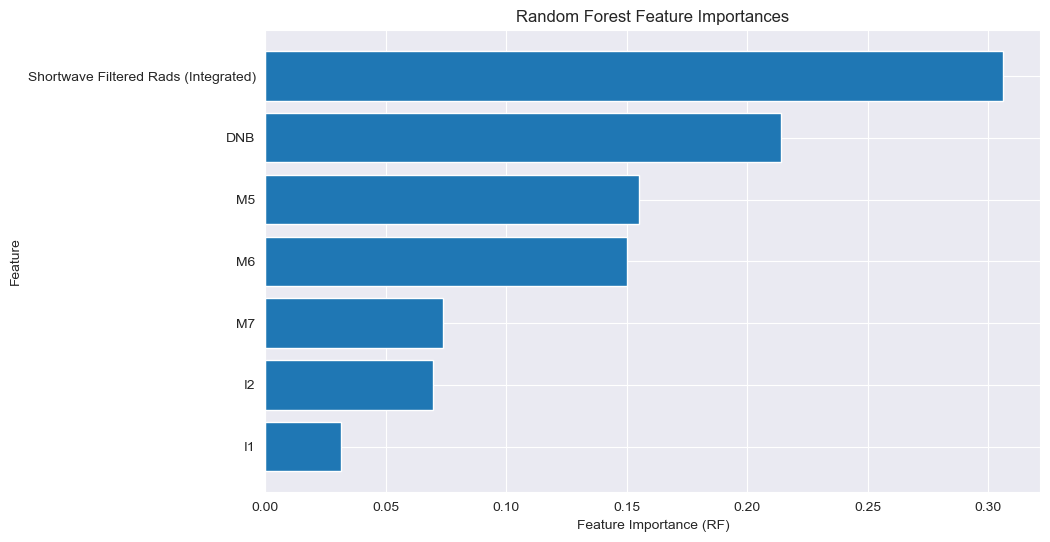

In [94]:
importances = gs_no_geo_no_i1_model["Model"].feature_importances_
features = gs_no_geo_no_i1_model["Model"].feature_names_in_
importance_df = (
    pd.Series(importances, index=features)
      .sort_values(ascending=False)
      .rename_axis("Feature")
      .reset_index(name="Importance")
)

# Plot as heatmap or bar chart
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance (RF)")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_filtered_vs_geometry(
    df: pd.DataFrame,
    scene: str,                 # e.g. "Land", "Ocean Clear", "Snow"
    geom: str,                  # "SZA" | "VZA" | "RAZ" (accepts "RZA" too)
    spectrum: str = "sw",       # "sw" or "lw" → which filtered column to plot
    bins: int = 16,             # number of equal-width bins for trend
    point_alpha: float = 0.35,
    figsize=(7,5),
    title: str | None = None,
):
    """
    Plot filtered radiance vs a chosen geometry for a given Scene.
    Adds a binned trend (bin-centers vs bin-means) and prints Pearson/Spearman r.
    """

    # --- column names (robust to "RZA" vs "RAZ") ---
    geom = geom.upper()
    geom_col = {"SZA":"SZA","VZA":"VZA","RAZ":"RAZ","RZA":"RAZ"}.get(geom, None)
    if geom_col is None or geom_col not in df.columns:
        raise ValueError(f"geom must be one of ['SZA','VZA','RAZ']; got '{geom}'")

    filt_col = ("Shortwave Filtered Rads (Integrated)"
                if spectrum.lower()=="sw" else
                "Longwave Filtered Rads (Integrated)")
    if filt_col not in df.columns:
        raise ValueError(f"Filtered column '{filt_col}' not found in df")

    if "Scene" not in df.columns:
        raise ValueError("df must contain a 'Scene' column")

    # --- subset & clean ---
    d = df.loc[df["Scene"].astype(str).str.lower()==scene.lower(),
               [geom_col, filt_col, "Scene"]].dropna()
    if d.empty:
        raise ValueError(f"No rows for scene '{scene}' after filtering/NaN drop")

    x = d[geom_col].to_numpy()
    y = d[filt_col].to_numpy()

    # --- quick stats ---
    # protect against constant vectors
    pearson = np.corrcoef(x, y)[0,1] if np.std(x)>0 and np.std(y)>0 else np.nan
    spearman = pd.Series(x).corr(pd.Series(y), method="spearman")

    # --- binned trend (mean per bin) ---
    binedges = np.linspace(x.min(), x.max(), bins+1)
    binidx = np.clip(np.digitize(x, binedges)-1, 0, bins-1)
    bin_centers = 0.5*(binedges[:-1] + binedges[1:])
    bin_means = np.array([y[binidx==k].mean() if np.any(binidx==k) else np.nan
                          for k in range(bins)])

    # --- plot ---
    plt.figure(figsize=figsize)
    plt.scatter(x, y, s=12, alpha=point_alpha)
    # binned line (skip NaN bins)
    mask = ~np.isnan(bin_means)
    plt.plot(bin_centers[mask], bin_means[mask], linewidth=2)

    ttl = title or f"{spectrum.upper()} Filtered vs {geom_col} — Scene: {scene}"
    plt.title(ttl)
    plt.xlabel(geom_col)
    plt.ylabel(filt_col)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()

    print(f"{scene} | {spectrum.upper()} | {geom_col}  —  "
          f"Pearson r = {pearson:.3f}, Spearman ρ = {spearman:.3f},  n = {len(d)}")


Snow | SW | SZA  —  Pearson r = -0.807, Spearman ρ = -0.887,  n = 1575
Land | SW | SZA  —  Pearson r = -0.483, Spearman ρ = -0.634,  n = 3150
Deep Convective Cloud | SW | SZA  —  Pearson r = -0.700, Spearman ρ = -0.860,  n = 315
Cloudy Ocean | SW | SZA  —  Pearson r = -0.520, Spearman ρ = -0.642,  n = 420
Clear Ocean | SW | SZA  —  Pearson r = -0.003, Spearman ρ = -0.281,  n = 735


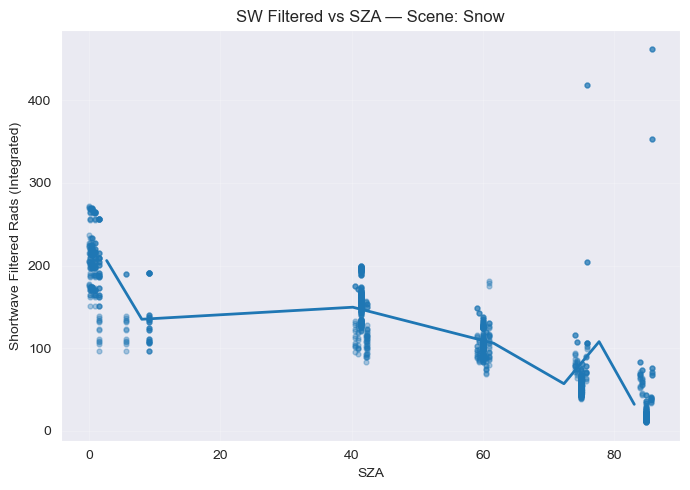

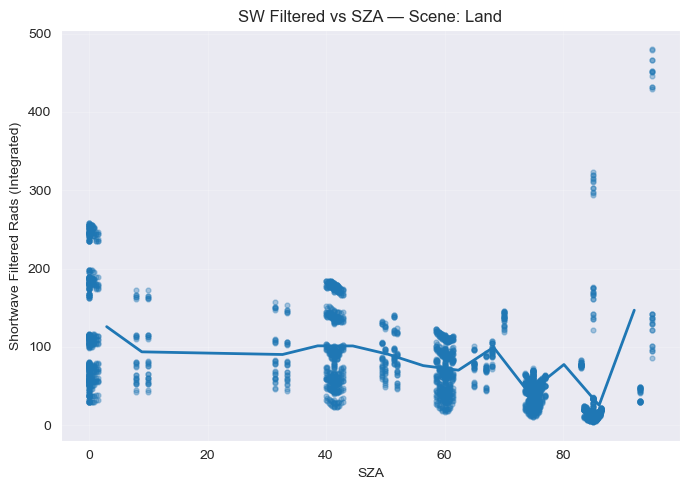

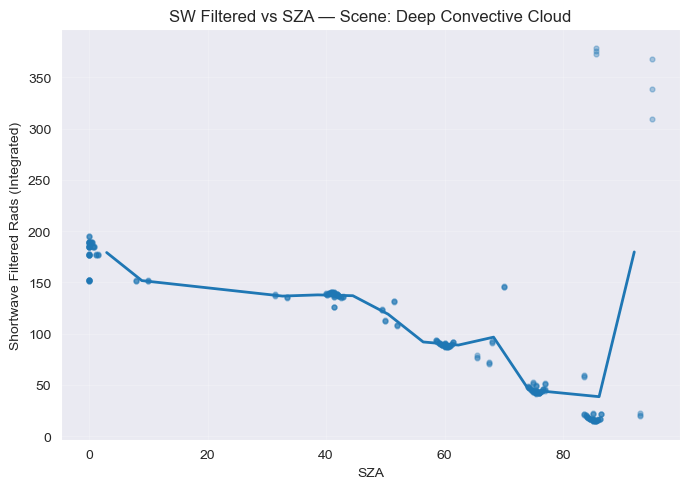

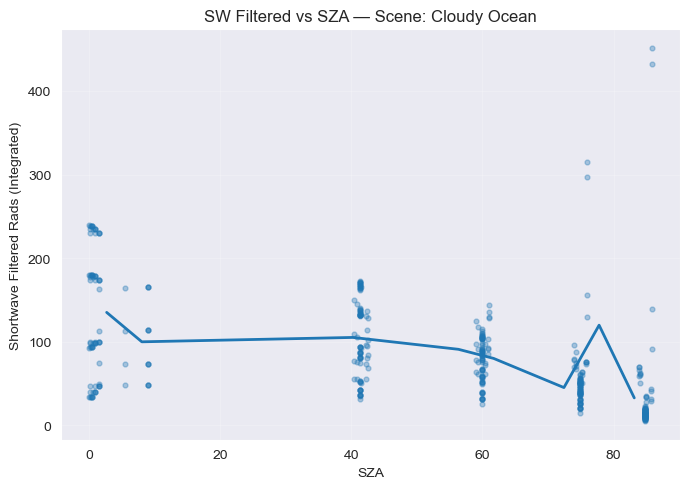

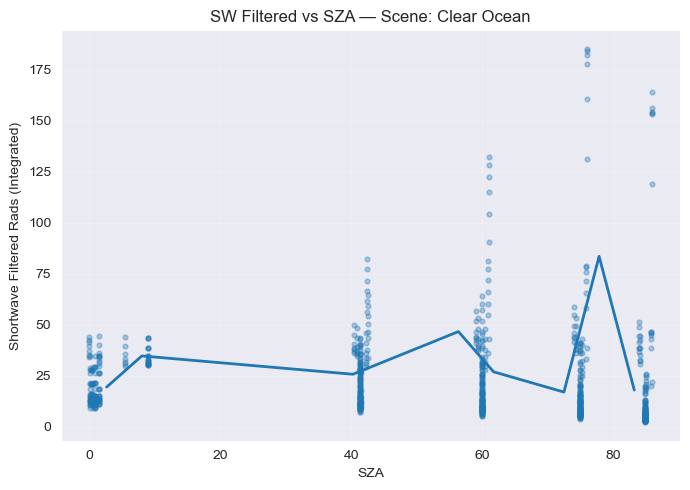

In [112]:
# SW filtered vs SZA
scenes = all_dataset["Scene"].unique()
for scene in scenes:
    plot_filtered_vs_geometry(all_dataset, scene=scene, geom="SZA", spectrum="sw")

Snow | SW | VZA  —  Pearson r = -0.009, Spearman ρ = 0.010,  n = 1575
Land | SW | VZA  —  Pearson r = 0.139, Spearman ρ = 0.226,  n = 3150
Deep Convective Cloud | SW | VZA  —  Pearson r = 0.135, Spearman ρ = 0.123,  n = 315
Cloudy Ocean | SW | VZA  —  Pearson r = 0.155, Spearman ρ = 0.227,  n = 420
Clear Ocean | SW | VZA  —  Pearson r = 0.576, Spearman ρ = 0.664,  n = 735


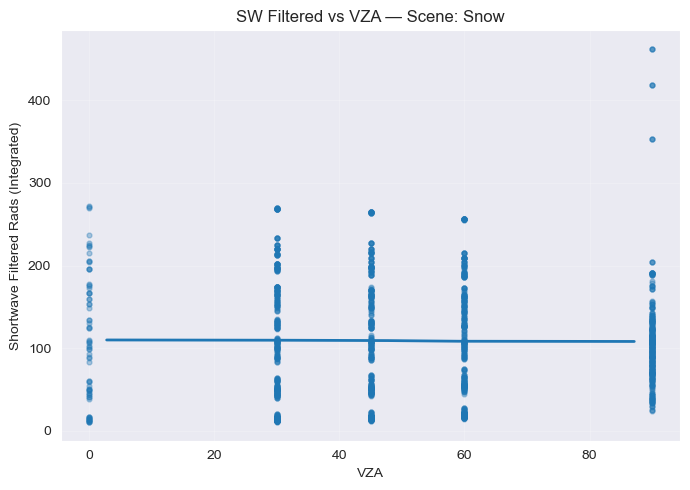

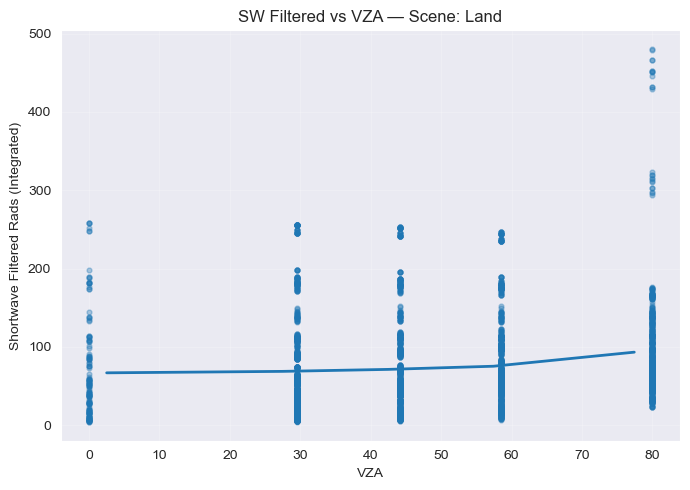

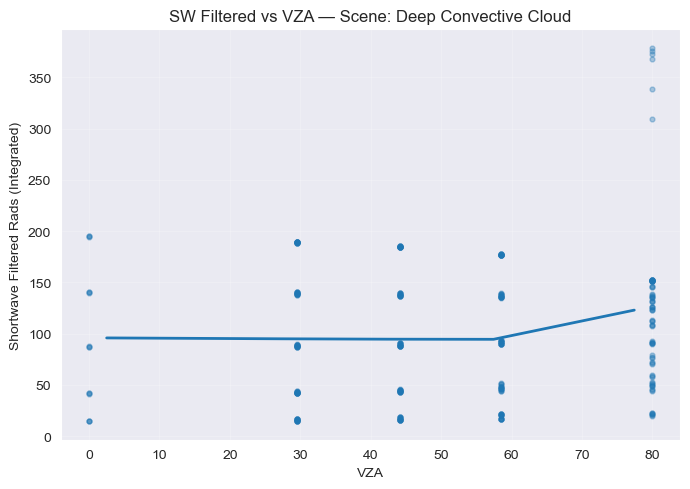

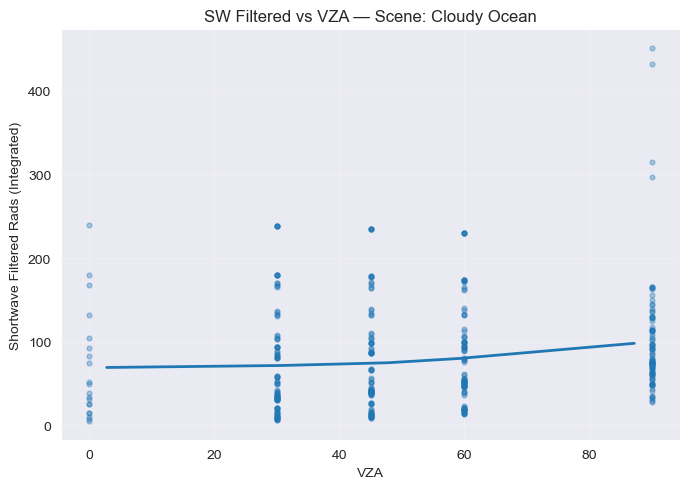

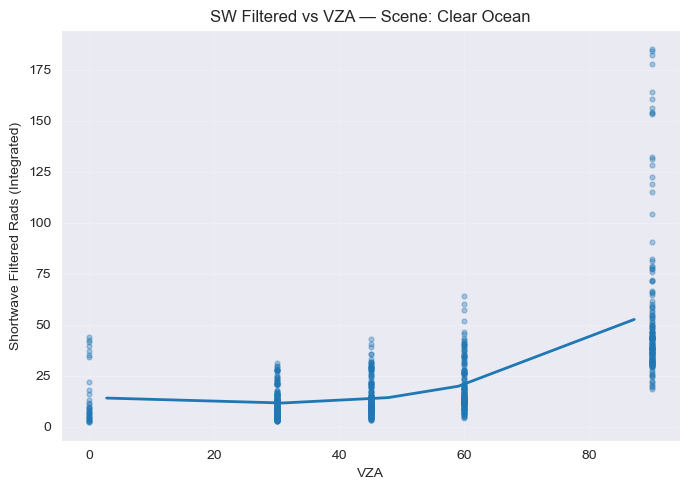

In [113]:
for scene in scenes:
    plot_filtered_vs_geometry(all_dataset, scene=scene, geom="VZA", spectrum="sw")

Snow | SW | RAZ  —  Pearson r = -0.027, Spearman ρ = 0.001,  n = 1575
Land | SW | RAZ  —  Pearson r = -0.063, Spearman ρ = -0.015,  n = 3150
Deep Convective Cloud | SW | RAZ  —  Pearson r = -0.093, Spearman ρ = -0.002,  n = 315
Cloudy Ocean | SW | RAZ  —  Pearson r = -0.056, Spearman ρ = 0.001,  n = 420
Clear Ocean | SW | RAZ  —  Pearson r = -0.180, Spearman ρ = -0.046,  n = 735


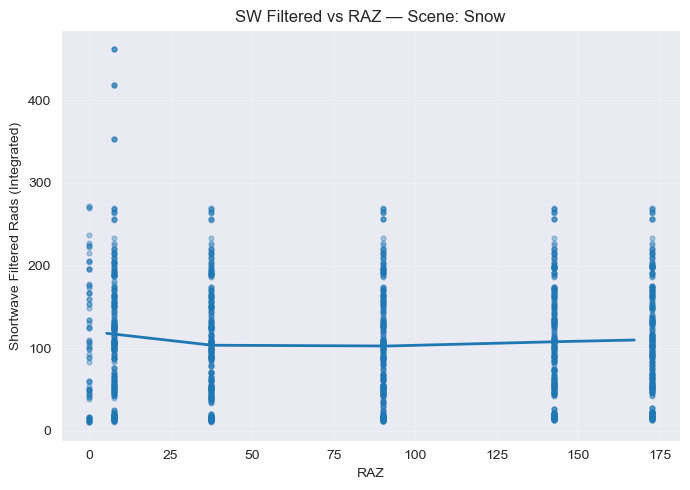

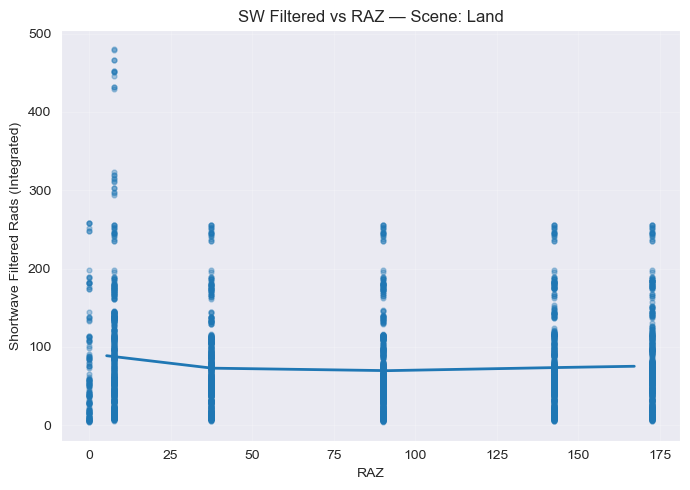

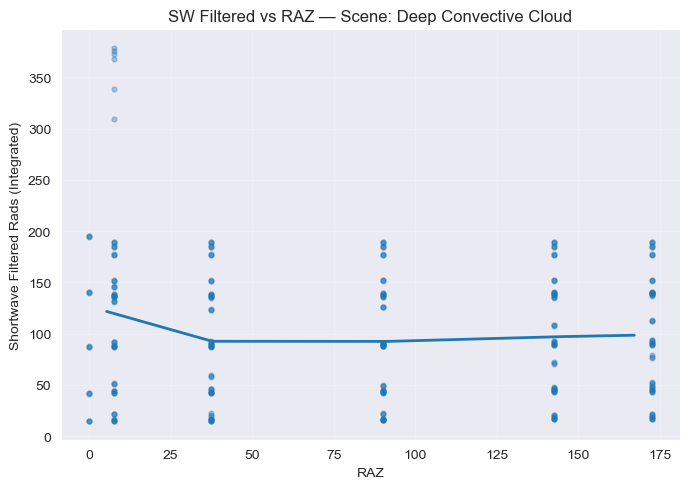

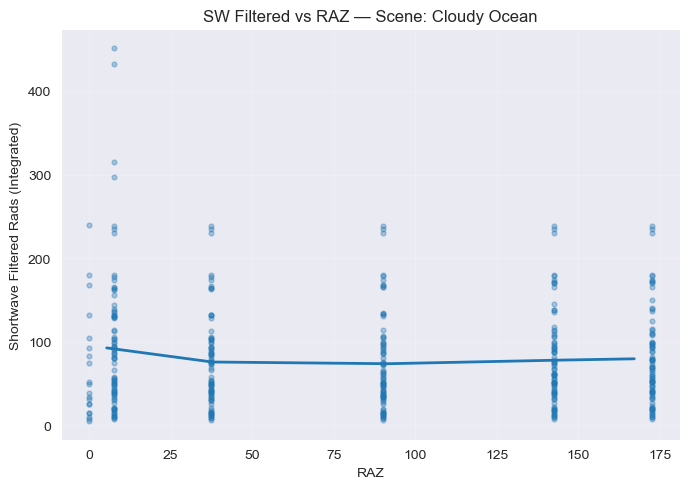

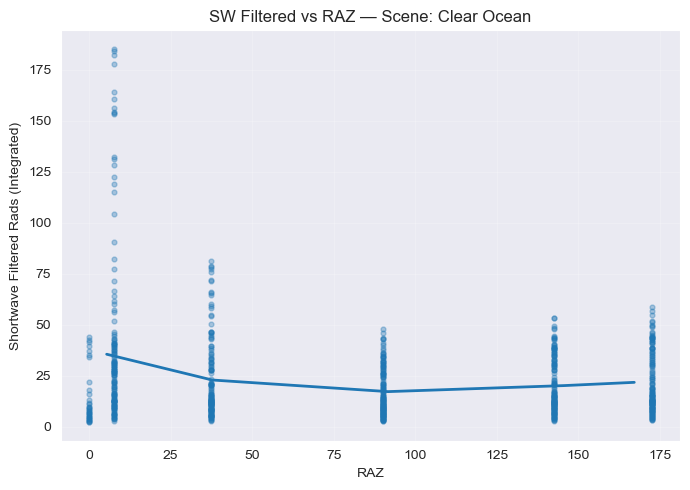

In [114]:
for scene in scenes:
    plot_filtered_vs_geometry(all_dataset, scene=scene, geom="RAZ", spectrum="sw")

In [160]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def correlations_with_filtered(
    df: pd.DataFrame,
    cols: list[str],
    spectrum: str = "sw",     # "sw" or "lw"
    scene: str | None = None, # optionally subset by scene
    plot: bool = True,        # make scatter+trend plots
    bins: int = 20,           # bins for trend line
    figsize: tuple = (6, 4)
) -> pd.DataFrame:
    """
    Compute Pearson & Spearman correlations of given columns
    against filtered radiance (SW or LW). Optionally plot scatter+trend.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset containing geometry and filtered radiance columns.
    cols : list of str
        Column names to compute correlations for.
    spectrum : {"sw","lw"}
        Which filtered radiance column to use.
    scene : str or None
        If given, subset DataFrame to this scene type.
    plot : bool
        Whether to make scatter+trend plots for each feature.
    bins : int
        Number of bins for the trend line.
    figsize : tuple
        Figure size for plots.

    Returns
    -------
    pd.DataFrame
        Table with Feature, Pearson, Spearman, N
    """

    filt_col = ("Shortwave Filtered Rads (Integrated)"
                if spectrum.lower() == "sw"
                else "Longwave Filtered Rads (Integrated)")
    if filt_col not in df.columns:
        raise ValueError(f"Filtered column '{filt_col}' not found in dataset")

    # Optional scene filtering
    data = df.copy()
    if scene is not None:
        data = data[data["Scene"].astype(str).str.lower() == scene.lower()]
        if data.empty:
            raise ValueError(f"No rows for scene '{scene}'")

    results = []

    for c in cols:
        if c not in data.columns:
            continue

        sub = data[[c, filt_col]].dropna()
        if sub.empty:
            continue

        pearson = sub[c].corr(sub[filt_col], method="pearson")
        spearman = sub[c].corr(sub[filt_col], method="spearman")

        results.append({
            "Feature": c,
            "Pearson": pearson,
            "Spearman": spearman,
            "N": len(sub)
        })

        if plot:
            x = sub[c].to_numpy()
            y = sub[filt_col].to_numpy()

            # bin centers & means for trend
            edges = np.linspace(x.min(), x.max(), bins+1)
            idx = np.clip(np.digitize(x, edges)-1, 0, bins-1)
            centers = 0.5*(edges[:-1] + edges[1:])
            means = np.array([y[idx==k].mean() if np.any(idx==k) else np.nan for k in range(bins)])

            plt.figure(figsize=figsize)
            plt.scatter(x, y, alpha=0.3, s=12, label="points")
            plt.plot(centers, means, color="red", lw=2, label="binned mean")
            ttl = f"{spectrum.upper()} Filtered vs {c}"
            if scene: ttl += f" — Scene: {scene}"
            plt.title(ttl)
            plt.xlabel(c)
            plt.ylabel(filt_col)
            plt.grid(alpha=0.2)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return pd.DataFrame(results).sort_values("Pearson", key=abs, ascending=False).reset_index(drop=True)


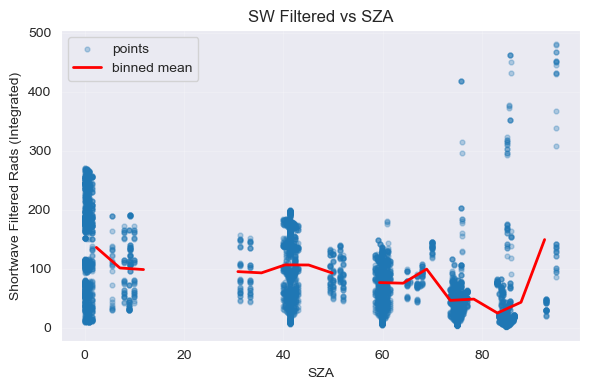

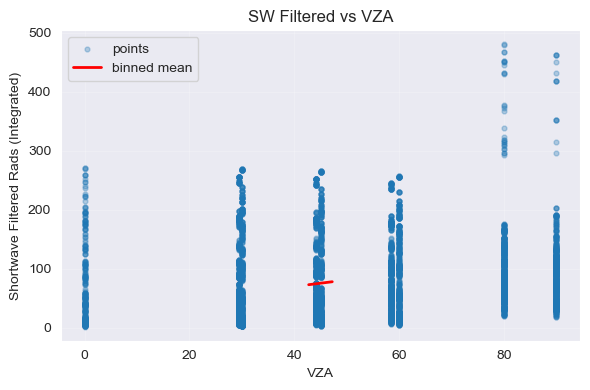

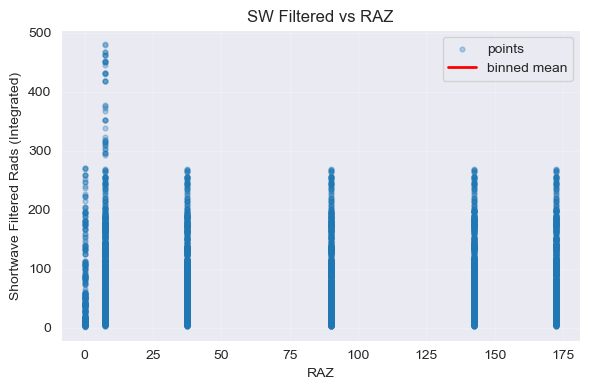

  Feature   Pearson  Spearman     N
0     SZA -0.516053 -0.602121  6195
1     VZA  0.105782  0.177401  6195
2     RAZ -0.053547 -0.016408  6195


In [162]:
corrs_all = correlations_with_filtered(all_dataset, ["SZA","VZA","RAZ"], spectrum="sw", plot=True)
print(corrs_all)

In [262]:
# def create_correlation_heatmap(dataset: pd.DataFrame, bands: bool = True) -> pd.DataFrame:
#     """
#     Creates a correlation heatmap between VIIRS bands and Shortwave Unfiltered Rads.
#
#     Args:
#         dataset (pd.DataFrame): The input dataset containing VIIRS bands and Shortwave Unfiltered Rads
#     """
#     # Define VIIRS bands
#     viirs_bands = ['M1', 'M2', 'M3', 'M4', 'I1',
#                   'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
#                   'M12', 'M13', 'M14', 'M15', 'I5', 'M16']
#     geometries = ["SZA", "VZA", "RAZ"]
#     cols = []
#     if bands:
#         cols = viirs_bands
#     else:
#         cols = geometries
#
#     target_column = 'Shortwave Filtered Rads (Integrated)'
#
#     # Create a subset dataframe with just the columns we want
#     correlation_data = dataset[cols + [target_column]]
#
#     # Calculate correlation matrix
#     correlation_matrix = correlation_data.corr()
#
#     # Create the heatmap
#     plt.figure(figsize=(12, 7))
#     sns.heatmap(correlation_matrix[[target_column]].sort_values(by=target_column, ascending=False),
#                 annot=True,
#                 cmap='coolwarm',
#                 center=0,
#                 fmt='.2f',
#                 linewidths=0.5)
#     plt.title('Correlation between VIIRS Bands and Shortwave Filtered Rads')
#     plt.tight_layout()
#     plt.show()
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def create_correlation_heatmap(dataset: pd.DataFrame, bands: bool = True) -> pd.DataFrame:
    """
    Creates a correlation heatmap between VIIRS bands (or geometry angles)
    and Shortwave Unfiltered Radiances. Also returns Pearson & Spearman
    correlation tables for reference.

    Args:
        dataset (pd.DataFrame): The input dataset containing features + target
        bands (bool): If True, compute correlations for VIIRS bands;
                      if False, compute correlations for SZA/VZA/RAZ.

    Returns:
        pd.DataFrame: Table of Pearson & Spearman correlations with target.
    """
    # Define VIIRS bands & geometries
    # viirs_bands = [
    #     'M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9',
    #     'I3','M10','M11','I4','M12','M13','M14','M15','I5','M16'
    # ]
    viirs_bands = [
        'M1 0.402 - 0.422 μm',
       'M2 0.436 - 0.454 μm', 'M3 0.478 - 0.488 μm', 'M4 0.545 - 0.565 μm',
       'I1 0.60 - 0.68 μm', 'M5 0.662 - 0.682 μm', 'DNB 0.50 - 0.90 μm',
       'M6 0.739 - 0.754 μm', 'I2 0.85 - 0.88 μm', 'M7 0.846 - 0.885 μm',
       'M8 1.23 - 1.25 μm', 'M9 1.371 - 1.386 μm', 'I3 1.58 - 1.64 μm',
       'M10 1.58 - 1.64 μm', 'M11 2.23 - 2.28 μm', 'I4 3.55 - 3.93 μm',
       'M11 3.61 - 3.79 μm', 'M13 3.97 - 4.13 μm', 'M14 8.4 - 8.7 μm',
       'M15 10.26 - 11.26 μm', 'I5 10.5 - 12.4 μm', 'M16 11.54 - 12.49 μm'
    ]
    geometries = ["SZA", "VZA", "RAZ"]

    cols = viirs_bands if bands else geometries
    target_column = 'Shortwave Unfiltered Rads (Integrated)'

    # Subset DataFrame
    correlation_data = dataset[cols + [target_column]].dropna()

    # --- Pearson correlation ---
    # Pearson = linear correlation coefficient (sensitive to linear trends)
    pearson_corr = correlation_data.corr(method="pearson")[[target_column]]

    # --- Spearman correlation ---
    # Spearman = rank correlation (captures monotonic but non-linear trends)
    spearman_corr = correlation_data.corr(method="spearman")[[target_column]]

    # --- Heatmap (Pearson by default) ---
    plt.figure(figsize=(12, 7))
    sns.heatmap(
        pearson_corr.sort_values(by=target_column, ascending=False),
        annot=True,
        cmap="coolwarm",
        center=0,
        fmt=".2f",
        linewidths=0.5
    )
    if bands:
        plt.title("Pearson Correlation: VIIRS Bands vs Shortwave Unfiltered Rads")
    else:
        plt.title("Pearson Correlation: Geometry vs Shortwave Unfiltered Rads")
    plt.tight_layout()
    plt.show()

    # --- Combine results into one table ---
    out = pd.DataFrame({
        "Feature": pearson_corr.index,
        "Pearson": pearson_corr[target_column].values,
        "Spearman": spearman_corr[target_column].values
    }).reset_index(drop=True).sort_values("Pearson", key=abs, ascending=False)

    return out

In [263]:
all_ds_named = rename_bands(all_dataset)
all_ds_named.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)', 'M1 0.402 - 0.422 μm',
       'M2 0.436 - 0.454 μm', 'M3 0.478 - 0.488 μm', 'M4 0.545 - 0.565 μm',
       'I1 0.60 - 0.68 μm', 'M5 0.662 - 0.682 μm', 'DNB 0.50 - 0.90 μm',
       'M6 0.739 - 0.754 μm', 'I2 0.85 - 0.88 μm', 'M7 0.846 - 0.885 μm',
       'M8 1.23 - 1.25 μm', 'M9 1.371 - 1.386 μm', 'I3 1.58 - 1.64 μm',
       'M10 1.58 - 1.64 μm', 'M11 2.23 - 2.28 μm', 'I4 3.55 - 3.93 μm',
       'M11 3.61 - 3.79 μm', 'M13 3.97 - 4.13 μm', 'M14 8.4 - 8.7 μm',
       'M15 10.26 - 11.26 μm', 'I5 10.5 - 12.4 μm', 'M16 11.54 - 12.49 μm',
       'Scaled Shortwave Filtered', 'Scaled Shortwave Unfiltered',
       'Scaled Longwave Filtered', 'Scaled Longwave Unfiltered'],
      dtype='object')

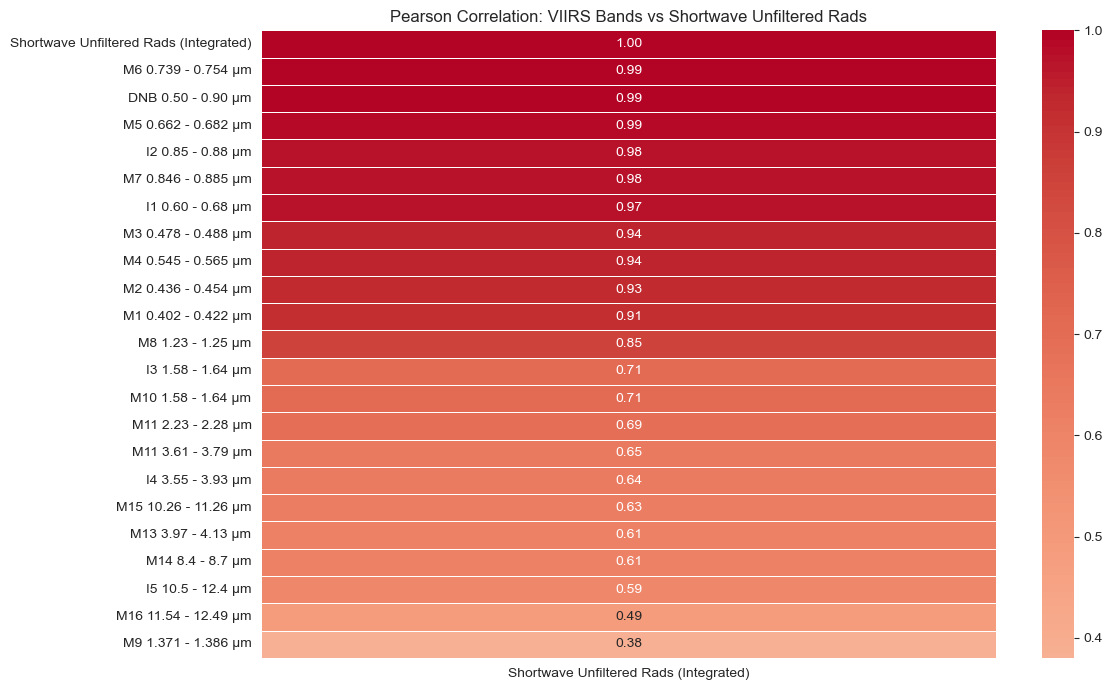

In [264]:
corrs_bands = create_correlation_heatmap(all_ds_named)

In [172]:
corrs_bands

,Feature,Pearson,Spearman
22,Shortwave Unfiltered Rads (Integrated),1.000000,1.000000
7,M6,0.992024,0.992676
6,DNB,0.991674,0.998488
5,M5,0.986615,0.988853
8,I2,0.975324,0.988142
9,M7,0.975324,0.988142
4,I1,0.972014,0.989443
2,M3,0.943816,0.982807
3,M4,0.939956,0.985192
1,M2,0.927684,0.974421


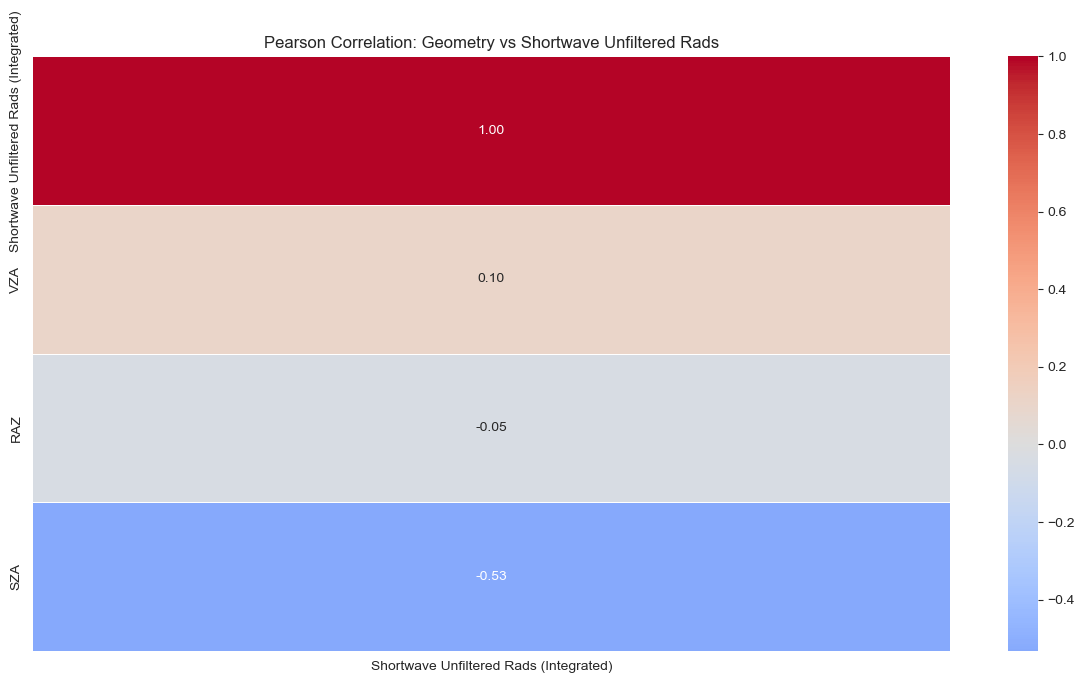

In [173]:
corrs_geos = create_correlation_heatmap(all_dataset, False)

In [176]:
corrs_geos

,Feature,Pearson,Spearman
3,Shortwave Unfiltered Rads (Integrated),1.000000,1.000000
0,SZA,-0.532318,-0.615014
1,VZA,0.102886,0.180116
2,RAZ,-0.047044,-0.010785


In [255]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_cdf_correlations(df, spectrum="sw"):
    """
    Plot CDF of per-scene correlations between geometries and unfiltered radiance.
    """
    target_col = "Shortwave Unfiltered Rads (Integrated)" if spectrum=="sw" else "Longwave Unfiltered Rads (Integrated)"
    geom_cols = ["SZA","VZA","RAZ"]

    corr_by_scene = {g: [] for g in geom_cols}

    for scene, d in df.groupby("Scene"):
        for g in geom_cols:
            if d[g].nunique() > 1:  # avoid degenerate
                corr = d[[g, target_col]].corr(method="pearson").iloc[0,1]
                corr_by_scene[g].append(corr)

    # Plot empirical CDFs
    plt.figure(figsize=(7,5))
    for g, vals in corr_by_scene.items():
        vals = np.sort(vals)
        cdf = np.arange(1, len(vals)+1) / len(vals)
        plt.step(vals, cdf, where="post", label=g)

    plt.title("CDF of Per-Scene Pearson Correlations with SW Unfiltered")
    plt.xlabel("Correlation coefficient")
    plt.ylabel("Cumulative probability")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return corr_by_scene


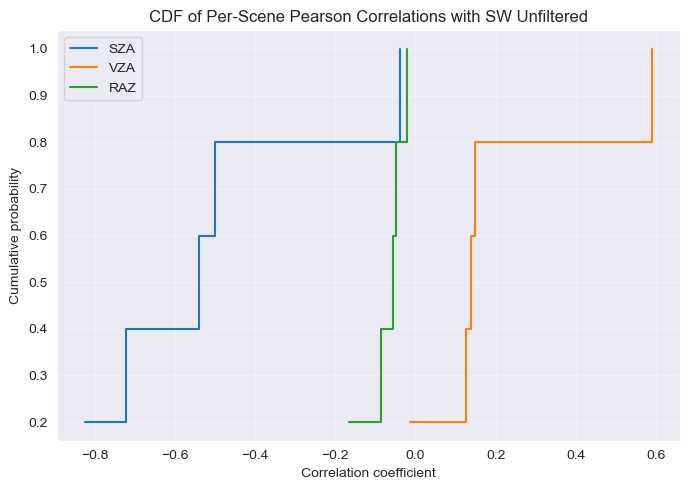

{'SZA': [-0.03915317355139841,
  -0.539042287240855,
  -0.7212288304083986,
  -0.49935570014888186,
  -0.8233047970727847],
 'VZA': [0.5890942910276844,
  0.14963110465222879,
  0.12713967937798393,
  0.13731433690216482,
  -0.01361293112355381],
 'RAZ': [-0.1656701345208709,
  -0.04915560270126653,
  -0.08622052612810897,
  -0.05551061823360459,
  -0.021432739513053026]}

In [265]:
plot_cdf_correlations(all_dataset)

In [266]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_radiance_cdfs_by_geometry(
    df: pd.DataFrame,
    geom: str = "SZA",
    spectrum: str = "sw",
    n_bins: int = 6,
    scene: str | None = None
):
    """
    Plot empirical CDFs of unfiltered radiance values,
    stratified by geometry bins (e.g. SZA bins).

    Args:
        df: dataframe with geometry + radiances.
        geom: which geometry column to bin ["SZA","VZA","RAZ"].
        spectrum: "sw" (shortwave) or "lw" (longwave).
        n_bins: number of bins for geometry.
        scene: optional, filter by a single scene.
    """
    target_col = (
        "Shortwave Unfiltered Rads (Integrated)" if spectrum == "sw"
        else "Longwave Unfiltered Rads (Integrated)"
    )

    data = df.copy()
    if scene is not None:
        data = data[data["Scene"] == scene]

    # Define bins
    bins = np.linspace(data[geom].min(), data[geom].max(), n_bins + 1)
    bin_labels = [f"{int(bins[i])}–{int(bins[i+1])}" for i in range(len(bins)-1)]
    data["geom_bin"] = pd.cut(data[geom], bins=bins, labels=bin_labels, include_lowest=True)

    # Plot CDFs
    plt.figure(figsize=(8,6))
    for label, subset in data.groupby("geom_bin"):
        vals = np.sort(subset[target_col].dropna().values)
        if len(vals) == 0:
            continue
        cdf = np.arange(1, len(vals)+1) / len(vals)
        plt.step(vals, cdf, where="post", label=f"{geom} {label} (n={len(vals)})")

    plt.title(f"CDF of {spectrum.upper()} Unfiltered Radiance by {geom} bins"
              + (f" — {scene}" if scene else ""))
    plt.xlabel("Unfiltered Radiance")
    plt.ylabel("Cumulative Probability")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


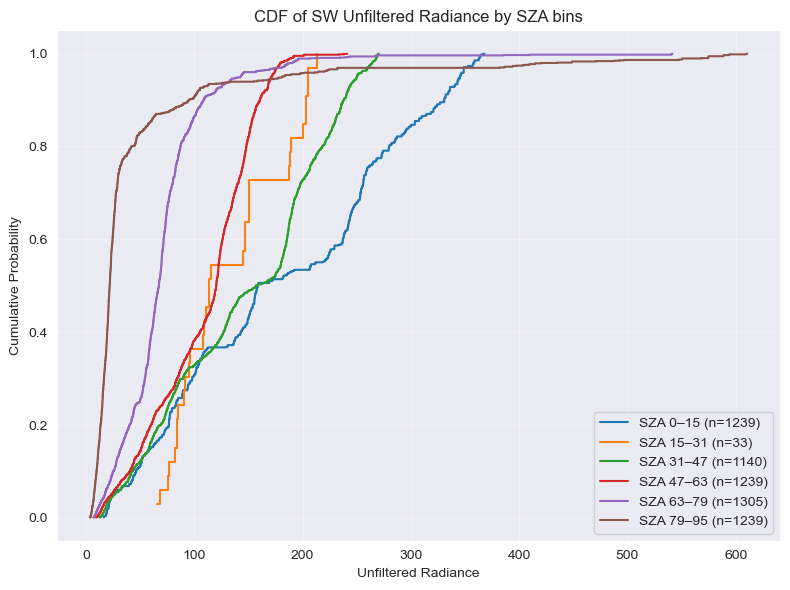

In [267]:
plot_radiance_cdfs_by_geometry(all_dataset, geom="SZA", spectrum="sw", n_bins=6)

In [189]:
from sklearn.model_selection import GroupShuffleSplit

def grouped_train_val_test_split(
    df: pd.DataFrame,
    target_col: str,
    feature_drop: list[str],
    train_size: float = 0.8,
    val_size: float = 0.1,
    random_state: int = 42
):
    """Custom split grouped by Scene+Run # to avoid leakage."""
    group_keys = df["Scene"].astype(str) + "|" + df["Run #"].astype(str)

    X_full = df.drop(columns=feature_drop)
    y_full = df[target_col]

    # 1) Train vs temp (val+test)
    gss1 = GroupShuffleSplit(n_splits=1, train_size=train_size, random_state=random_state)
    tr_idx, temp_idx = next(gss1.split(X_full, y_full, groups=group_keys))

    # 2) Val vs test from temp
    gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=random_state+1)
    val_rel, test_rel = next(gss2.split(
        X_full.iloc[temp_idx], y_full.iloc[temp_idx], groups=group_keys.iloc[temp_idx]
    ))
    val_idx = temp_idx[val_rel]
    test_idx = temp_idx[test_rel]

    def pack(idxs):
        return (
            X_full.iloc[idxs].drop(columns=["Scene", "Run #"], errors="ignore"),
            y_full.iloc[idxs],
            df.iloc[idxs][["Scene", "Run #"]]  # keep metadata
        )

    return pack(tr_idx), pack(val_idx), pack(test_idx)


In [235]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import (
    root_mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, r2_score
)
import numpy as np
import pandas as pd

def test_viirs_bands_refit(
    dataset: pd.DataFrame,
    v: bool,
    viirs_bands: bool,
    is_sw: bool = True,
    selected_viirs_bands: list[str] | None = None,
    best_params: dict | None = None,
    use_groups: bool = True,
    n_splits: int = 5,
    refit_on_val: bool = True  # <-- NEW FLAG
):
    """
    Train a RandomForest model, validate on held-out data, and optionally refit
    on train+val before evaluating on the test set.
    """
    ret = {}
    dataset_ = dataset.reset_index(drop=True)

    # --- target col setup ---
    target_col = "Shortwave Unfiltered Rads (Integrated)" if is_sw else "Longwave Unfiltered Rads (Integrated)"
    filtered_sw = "Shortwave Filtered Rads (Integrated)"
    filtered_lw = "Longwave Filtered Rads (Integrated)"

    # --- columns to drop ---
    if is_sw:
        columns_to_drop = [
            "Run #","Scene", "Shortwave Unfiltered Rads (Integrated)",
            "Longwave Unfiltered Rads (Integrated)", filtered_lw,
            "Scaled Longwave Unfiltered","Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered","Scaled Shortwave Filtered","Cloud"
        ]
    else:
        columns_to_drop = [
            "Run #","Scene",
            "Shortwave Unfiltered Rads (Integrated)", filtered_sw,
            "Scaled Longwave Unfiltered","Scaled Longwave Filtered",
            "Scaled Shortwave Unfiltered","Scaled Shortwave Filtered","Cloud"
        ]

    all_viirs_bands = ['SZA','VZA','RAZ','M1','M2','M3','M4','I1','M5','DNB','M6','I2','M7','M8','M9',
                       'I3','M10','M11','I4','M12','M13','M14','M15','I5','M16']

    if not viirs_bands:
        columns_to_drop.extend(all_viirs_bands)
    elif selected_viirs_bands is not None:
        columns_to_drop.extend([b for b in all_viirs_bands if b not in selected_viirs_bands])
        if v: print(f"Using selected VIIRS bands: {selected_viirs_bands}")
    else:
        if v: print("Using all VIIRS bands.")

    # --- custom split grouped by Scene|Run ---
    (X_tr, y_tr, meta_tr), (X_val, y_val, meta_val), (X_te, y_te, meta_te) = grouped_train_val_test_split(
        dataset_,
        target_col=target_col,
        feature_drop=columns_to_drop,
        train_size=0.8,
        val_size=0.1,
        random_state=42
    )

    if v:
        print(f"Train {X_tr.shape}, Val {X_val.shape}, Test {X_te.shape}")
        print("Train scenes:", meta_tr["Scene"].unique())

    # --- params ---
    params = best_params or {
        'max_depth': 16,
        'max_features': 'log2',
        'max_samples': None,
        'min_samples_leaf': 1,
        'min_samples_split': 2,
        'n_estimators': 600,
        'random_state': 42,
        'bootstrap': True
    }

    # --- model training on train only ---
    model = RandomForestRegressor(**params)
    model.fit(X_tr, y_tr)
    y_val_pred = model.predict(X_val)

    # --- validation metrics ---
    ret["Val_RMSE"] = root_mean_squared_error(y_val, y_val_pred)
    ret["Val_MAE"]  = mean_absolute_error(y_val, y_val_pred)
    ret["Val_MAPE%"] = mean_absolute_percentage_error(y_val, y_val_pred) * 100
    ret["Val_R2"]   = r2_score(y_val, y_val_pred)

    # --- cross-validation (on training set) ---
    if use_groups:
        groups = dataset_["Scene"].astype(str) + "|" + dataset_["Run #"].astype(str)
        splitter = GroupKFold(n_splits=n_splits)
        folds = list(splitter.split(X_tr, y_tr, groups.loc[y_tr.index]))
    else:
        from sklearn.model_selection import KFold
        folds = list(KFold(n_splits=n_splits, shuffle=True, random_state=42).split(X_tr, y_tr))

    cv_scores_neg = cross_val_score(
        RandomForestRegressor(**params),
        X_tr, y_tr, cv=folds,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    ret["CV_Fold_RMSEs"] = -cv_scores_neg
    ret["CV_RMSE_mean"]  = float(np.mean(-cv_scores_neg))
    ret["CV_RMSE_std"]   = float(np.std(-cv_scores_neg, ddof=1))

    # --- optional refit ---
    if refit_on_val:
        X_trval = pd.concat([X_tr, X_val], axis=0)
        y_trval = pd.concat([y_tr, y_val], axis=0)
        final_model = RandomForestRegressor(**params)
        final_model.fit(X_trval, y_trval)
        y_test_pred = final_model.predict(X_te)
        ret["Test_RMSE"] = root_mean_squared_error(y_te, y_test_pred)
        ret["Test_MAE"]  = mean_absolute_error(y_te, y_test_pred)
        ret["Test_MAPE%"] = mean_absolute_percentage_error(y_te, y_test_pred) * 100
        ret["Test_R2"]   = r2_score(y_te, y_test_pred)
        ret["Final_Model"] = final_model
    else:
        ret["Final_Model"] = model  # just the train-only fit

    # --- return useful data too ---
    ret["Params_Used"] = params
    ret["Train_data"] = {"X_tr": X_tr, "y_tr": y_tr, "meta_tr": meta_tr}
    ret["Validation_data"] = {"X_val": X_val, "y_val": y_val, "meta_val": meta_val}
    ret["Test_data"] = {"X_test": X_te, "y_test": y_te, "meta_test": meta_te}

    return ret


Using selected VIIRS bands: ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16']
Train (4955, 26), Val (620, 26), Test (620, 26)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']
(24,) [ 7.34187844e-02  8.26303841e-02  2.26499920e-02  5.10650160e-02
  2.84607895e-01 -3.39077317e-02 -1.32426119e-02  5.14317707e-02
  1.77523190e-01  1.78944620e-02  8.53497039e-02  8.97608113e-02
 -2.02119692e-01  6.75768736e-02 -1.18080389e-02 -2.36532521e-04
  6.21846285e-02 -2.07003760e-01 -1.28494114e-01 -2.38809181e-04
  1.96127205e-02 -9.26383160e-02 -2.66463159e-02 -1.10835603e-01]


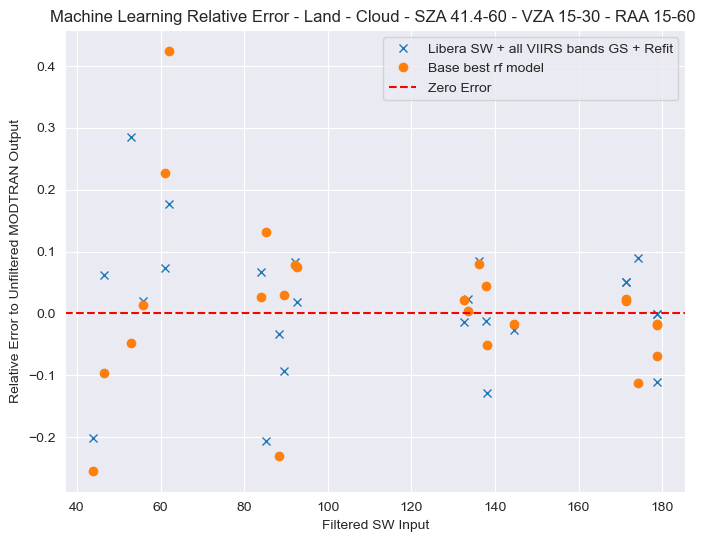

In [193]:
test_refit = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 selected_viirs_bands=['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11', 'I4', 'M12', 'M13', 'M14',
                                                       'M15', 'I5', 'M16'],  best_params=best, use_groups=True)

test_refit_pe = calculate_pe(matt_test_data, ['SZA', 'VZA', 'RAZ', 'Shortwave Filtered Rads (Integrated)', 'M1', 'M2',
       'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3',
       'M10', 'M11', 'I4', 'M12', 'M13', 'M14', 'M15', 'I5', 'M16'], test_refit['Final_Model'])

display_pe(sw_input, test_refit_pe, mtest_pe, "Libera SW + all VIIRS bands GS + Refit", "Base best rf model")

Using selected VIIRS bands: ['Shortwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11']
Train (4955, 16), Val (620, 16), Test (620, 16)
Train scenes: ['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']
(24,) [ 0.14124401  0.02119778 -0.02041353  0.06519291  0.13863569 -0.07096458
 -0.02723481  0.06555971  0.05601917  0.0427568   0.07117716  0.04594108
 -0.16677795  0.0359046  -0.03437175  0.01066604  0.01131796 -0.12865852
 -0.14192511  0.01066383 -0.08161929 -0.09731911 -0.0314718  -0.06908994]


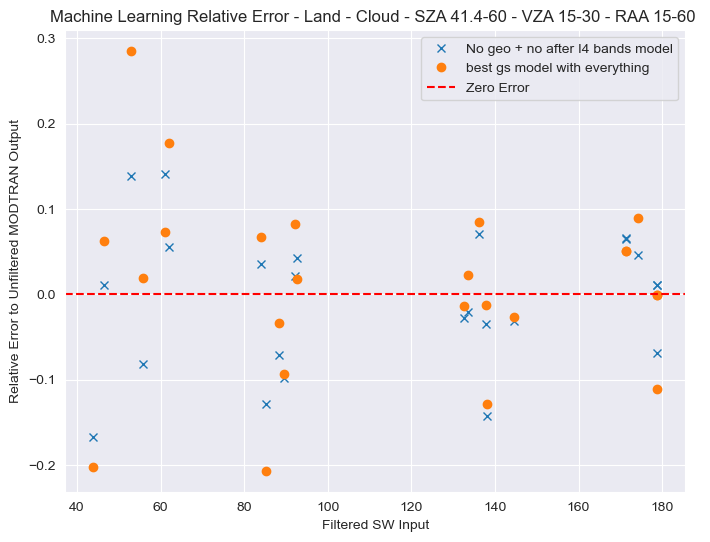

In [236]:
gs_no_geo_no_i4_refit = test_viirs_bands_refit(all_dataset, v=True, viirs_bands=True, is_sw=True,
                                 selected_viirs_bands=['Shortwave Filtered Rads (Integrated)',
                                                       'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                                       'M8', 'M9', 'I3', 'M10', 'M11'],  best_params=best, use_groups=True)

gs_no_geo_no_i4_refit_pe = calculate_pe(matt_test_data, ['Shortwave Filtered Rads (Integrated)',
                                        'M1', 'M2','M3', 'M4', 'I1', 'M5', 'DNB', 'M6', 'I2', 'M7',
                                        'M8', 'M9', 'I3', 'M10', 'M11'], gs_no_geo_no_i4_refit['Final_Model'])

display_pe(sw_input, gs_no_geo_no_i4_refit_pe, test_refit_pe, "No geo + no after I4 bands model", "best gs model with everything")

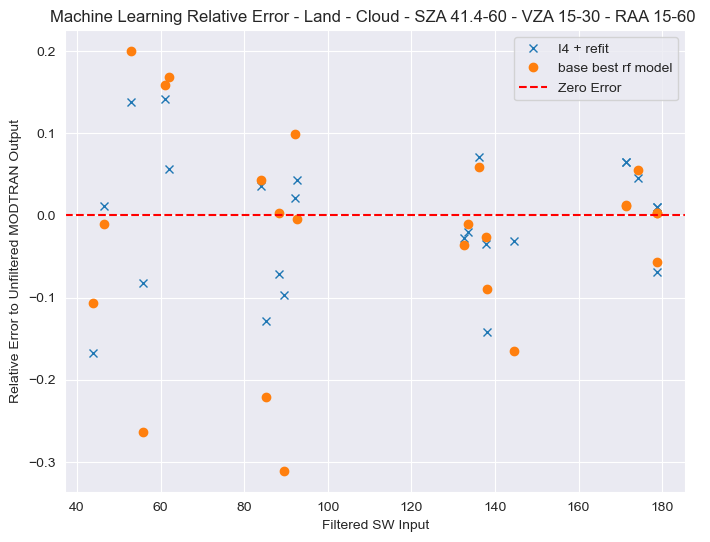

In [237]:
display_pe(sw_input, gs_no_geo_no_i4_refit_pe, best_pe, "I4 + refit", "base best rf model")

In [202]:
gs_no_geo_no_i4_refit

{'Val_RMSE': 1.24747689421744,
 'Val_MAE': 0.44409360540954557,
 'Val_MAPE%': 0.5325401007800983,
 'Val_R2': 0.9998164492249034,
 'CV_Fold_RMSEs': array([1.03662663, 0.80073733, 0.88285114, 3.7581768 , 2.08497497]),
 'CV_RMSE_mean': 1.7126733724126904,
 'CV_RMSE_std': 1.254986476308777,
 'Test_RMSE': 1.0387147743954042,
 'Test_MAE': 0.4029656394113209,
 'Test_MAPE%': 0.5502907418749249,
 'Test_R2': 0.9998867351815842,
 'Final_Model': RandomForestRegressor(max_depth=16, max_features='log2', n_estimators=800,
                       random_state=42),
 'Params_Used': {'max_depth': 16,
  'max_features': 'log2',
  'max_samples': None,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 800,
  'random_state': 42,
  'bootstrap': True},
 'Validation_data': {'X_val':       Shortwave Filtered Rads (Integrated)         M1         M2         M3  \
  0                               223.024942  21.443231  24.114170  25.615469   
  17                              213.475352  21.031630

In [241]:
i4_refit = gs_no_geo_no_i4_refit
i4_refit_test_data = i4_refit["Test_data"]
i4_refit_train_data = i4_refit["Train_data"]
i4_refit_val_data = i4_refit["Validation_data"]
i4_refit_val_data

{'X_val':       Shortwave Filtered Rads (Integrated)         M1         M2         M3  \
 0                               223.024942  21.443231  24.114170  25.615469   
 17                              213.475352  21.031630  23.773298  25.386043   
 24                              224.609416  20.813868  23.611391  25.237435   
 28                              267.873111  21.105985  23.878326  25.609600   
 39                              224.621636  20.816517  23.613908  25.239554   
 ...                                    ...        ...        ...        ...   
 6141                              5.231525   0.943652   0.975021   0.891759   
 6185                             38.516932   5.260011   5.710107   5.517593   
 6186                             42.305323   5.381911   5.885973   5.753478   
 6190                             38.615647   6.065742   6.494510   6.150808   
 6192                             44.649744   6.241160   6.751958   6.494851   
 
              M4         I1  

In [242]:
def combine_split(X, y, meta, target_name):
    """Combine features, target, and metadata into one DataFrame."""
    df = X.copy()
    df[target_name] = y.values
    for col in meta.columns:
        df[col] = meta[col].values
    return df
test_i4_df = combine_split(
    i4_refit_test_data["X_test"],
    i4_refit_test_data["y_test"],
    i4_refit_test_data["meta_test"],
    target_name="Shortwave Unfiltered Rads (Integrated)"  # or LW if is_sw=False
)
train_i4_df = combine_split(
    i4_refit_train_data["X_tr"],
    i4_refit_train_data["y_tr"],
    i4_refit_train_data["meta_tr"],
    target_name="Shortwave Unfiltered Rads (Integrated)"  # or LW if is_sw=False
)
val_i4_df = combine_split(
    i4_refit_val_data["X_val"],
    i4_refit_val_data["y_val"],
    i4_refit_val_data["meta_val"],
    target_name="Shortwave Unfiltered Rads (Integrated)"  # or LW if is_sw=False
)
test_i4_df["Scene"].unique()

array(['Snow', 'Land', 'Deep Convective Cloud', 'Cloudy Ocean',
       'Clear Ocean'], dtype=object)

In [231]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def evaluate_pe_by_scene(
    val_df: pd.DataFrame,
    model,
    input_features: list[str],
    is_sw: bool = True,
    max_scenes: int | None = None
):
    """
    Evaluate relative prediction error (PE) across scenes in the validation set
    and plot scatter plots for each scene.

    Args:
        val_df (pd.DataFrame): Validation dataset (must include 'Scene').
        model: Trained model (e.g., RandomForest).
        input_features (list): Feature column names to use as inputs.
        is_sw (bool): True → predict SW unfiltered, False → LW unfiltered.
        max_scenes (int or None): Limit number of scenes to plot (for readability).

    Returns:
        dict[str, np.ndarray]: Scene -> PE array
    """
    target_col = "Shortwave Unfiltered Rads (Integrated)" if is_sw else "Longwave Unfiltered Rads (Integrated)"

    scene_results = {}
    unique_scenes = val_df["Scene"].unique()
    print(unique_scenes)
    if max_scenes is not None:
        unique_scenes = unique_scenes[:max_scenes]

    for scene in unique_scenes:
        d_scene = val_df[val_df["Scene"] == scene]
        if d_scene.empty:
            continue

        # --- True and predicted ---
        X_test = d_scene[input_features]
        y_true = d_scene[target_col].to_numpy().ravel()
        y_pred = model.predict(X_test)

        # --- Percent error ---
        pe = ((y_pred - y_true) / y_true) * 100
         # test_pe = ( (Y_test_pred_data - Y_test_true_data) / Y_test_true_data) * 100
        scene_results[scene] = pe

        # --- Plot ---
        plt.figure(figsize=(7, 5))
        plt.scatter(d_scene[input_features[0]], pe, alpha=0.5, s=20)  # x-axis = first input feature (usually SW filtered)
        plt.axhline(0, color="red", linestyle="--")
        plt.title(f"Relative Prediction Error by Scene: {scene}")
        plt.xlabel(input_features[0])
        plt.ylabel("Relative Error (%)")
        plt.tight_layout()
        plt.show()

    return scene_results


['Snow' 'Land' 'Deep Convective Cloud' 'Cloudy Ocean' 'Clear Ocean']


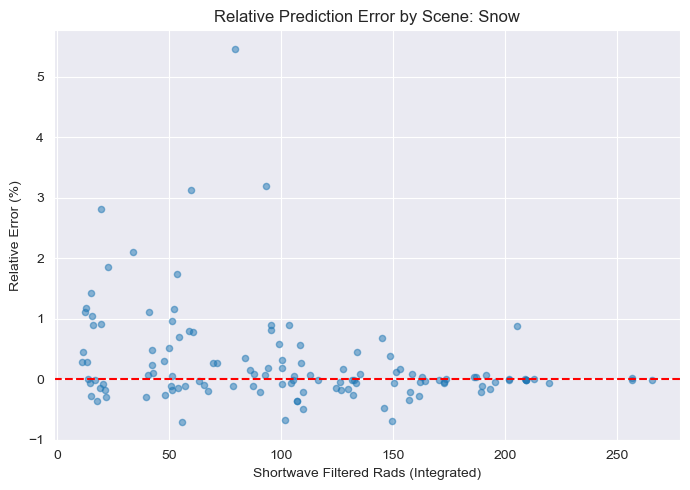

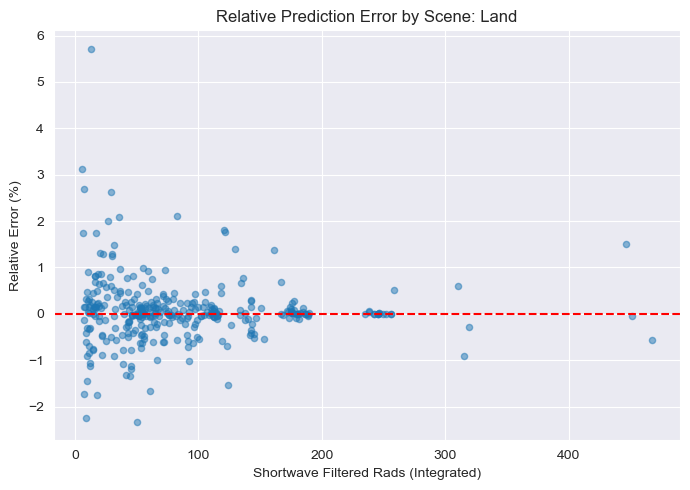

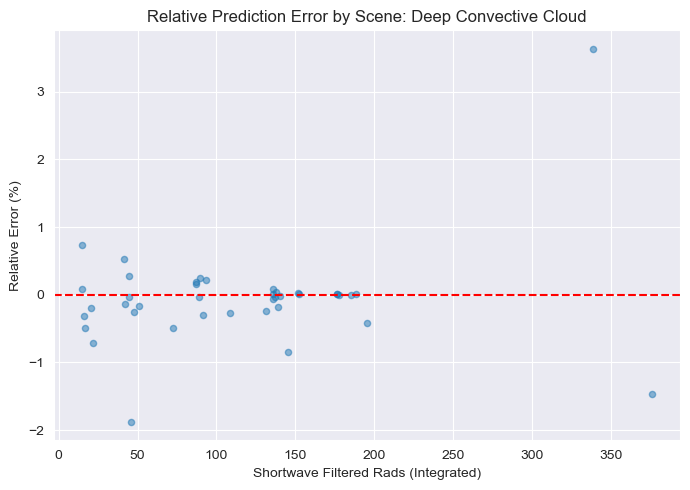

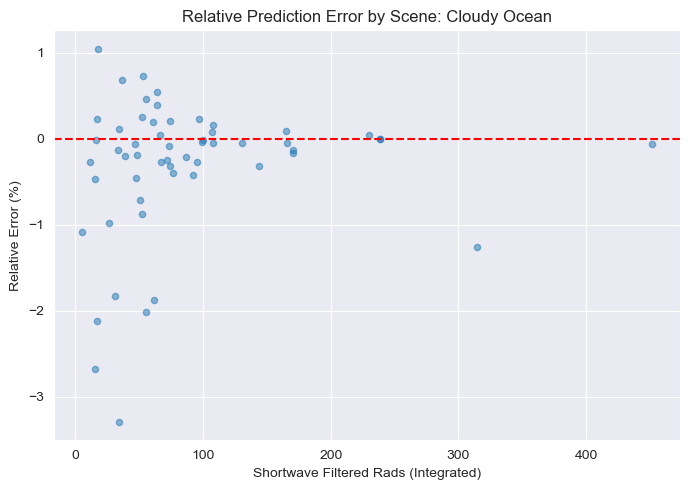

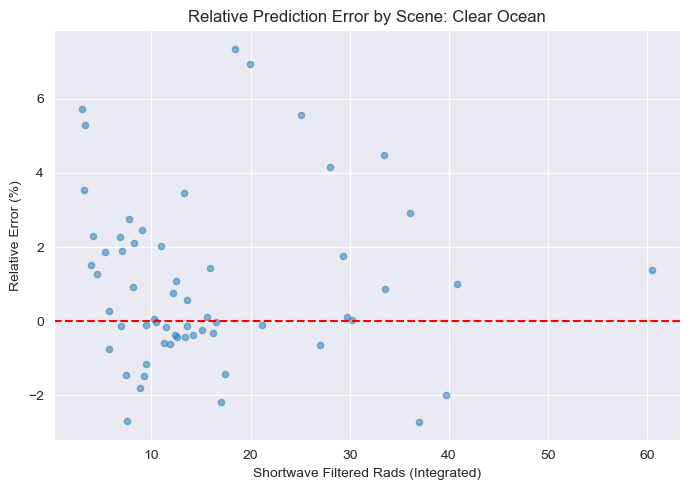

In [232]:
scene_pes = evaluate_pe_by_scene(
    test_i4_df,
    model=gs_no_geo_no_i4_refit["Final_Model"],
    input_features=list(i4_refit_test_data["X_test"].columns),  # same as what model trained on
    is_sw=True
)

In [32]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
#
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import (
#     mean_squared_error, mean_absolute_error, r2_score
# )
#
#
# # ---------- main comparator ----------
# def compare_old_poly_vs_model(
#     train_df: pd.DataFrame,
#     eval_df: pd.DataFrame,
#     model,                          # your trained model (RF)
#     is_sw: bool = True,             # True=SW, False=LW
#     poly_degree: int = 2,           # old method degree (2 = quadratic)
#     plot: bool = True,
#     title_suffix: str = "Evaluation"
# ):
#     """
#     Fit the old polynomial baseline on TRAIN (filtered -> unfiltered),
#     and compare it to the provided MODEL on the same EVAL data.
#     Returns metrics for both approaches and (optionally) a PE scatter plot.
#     """
#
#     # Choose column names
#     target_col  = "Shortwave Unfiltered Rads (Integrated)" if is_sw else "Longwave Unfiltered Rads (Integrated)"
#     filt_col    = "Shortwave Filtered Rads (Integrated)"   if is_sw else "Longwave Filtered Rads (Integrated)"
#
#     # Sanity checks
#     for df in (train_df, eval_df):
#         if filt_col not in df.columns or target_col not in df.columns:
#             raise ValueError(f"'{filt_col}' and '{target_col}' must be present in train/eval data frames.")
#
#     # ---------------- Baseline (fit on TRAIN) ----------------
#     X_train_poly_in = train_df[[filt_col]].to_numpy()
#     y_train_poly    = train_df[target_col].to_numpy()
#
#     poly = PolynomialFeatures(degree=poly_degree, include_bias=True)
#     X_train_poly = poly.fit_transform(X_train_poly_in)
#
#     baseline = LinearRegression()
#     baseline.fit(X_train_poly, y_train_poly)
#
#     # Predict on EVAL for the baseline
#     X_eval_poly = poly.transform(eval_df[[filt_col]].to_numpy())
#     y_eval_true = eval_df[target_col].to_numpy().ravel()
#     y_eval_pred_baseline = baseline.predict(X_eval_poly)
#
#     # ---------------- Model (predict on same EVAL) ----------------
#     # Use exactly the columns the model was trained with.
#     # If unsure, prefer model.feature_names_in_ (sklearn >=1.0) to avoid mismatch.
#     if hasattr(model, "feature_names_in_"):
#         model_features = list(model.feature_names_in_)
#     else:
#         # Fallback: use all non-target, non-meta columns from eval_df
#         drop_cols = {target_col, "Scene", "Run #"}
#         model_features = [c for c in eval_df.columns if c not in drop_cols]
#
#     X_eval_model = eval_df[model_features]
#     y_eval_pred_model = model.predict(X_eval_model)
#
#     # ---------------- Metrics ----------------
#     def _metrics(y_true, y_pred):
#         rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#         mae  = mean_absolute_error(y_true, y_pred)
#         mape = np.mean(np.abs((y_pred - y_true) / y_true)) * 100.0
#         r2   = r2_score(y_true, y_pred)
#         pe   = (y_pred - y_true) / y_true * 100.0
#         return {"RMSE": rmse, "MAE": mae, "MAPE%": mape, "R2": r2, "PE": pe}
#
#     baseline_metrics = _metrics(y_eval_true, y_eval_pred_baseline)
#     model_metrics    = _metrics(y_eval_true, y_eval_pred_model)
#
#     # ---------------- Plot ----------------
#     if plot:
#         xaxis = eval_df[filt_col].to_numpy()
#         plt.figure(figsize=(8, 6))
#         plt.scatter(xaxis, baseline_metrics["PE"], s=22, alpha=0.6, label=f"Baseline poly deg={poly_degree}")
#         plt.scatter(xaxis, model_metrics["PE"], s=22, alpha=0.6, label="ML model")
#         plt.axhline(0, color="red", linestyle="--", label="Zero Error")
#         swlw = "SW" if is_sw else "LW"
#         plt.title(f"Relative Prediction Error — {swlw} — {title_suffix}")
#         plt.xlabel(filt_col)
#         plt.ylabel("Relative Error (%)")
#         plt.legend()
#         plt.tight_layout()
#         plt.show()
#
#     return {
#         "baseline": {
#             "degree": poly_degree,
#             **{k: v for k, v in baseline_metrics.items() if k != "PE"}
#         },
#         "model": {
#             **{k: v for k, v in model_metrics.items() if k != "PE"}
#         },
#         "PE_arrays": {
#             "baseline_PE": baseline_metrics["PE"],
#             "model_PE": model_metrics["PE"],
#             "x_filtered": eval_df[filt_col].to_numpy(),
#             "scene": eval_df.get("Scene", pd.Series(index=eval_df.index, dtype=object)).to_numpy()
#         },
#         "used_features_for_model": model_features
#     }
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def compare_methods_per_scene(
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
    model,
    is_sw: bool = True,
    poly_degree: int = 2
):
    """
    For each Scene, plot prediction error (PE) for:
      - Old baseline polynomial regression (filtered -> unfiltered)
      - Multivariate polynomial regression (if desired, e.g. filtered + bands -> unfiltered)
      - ML model (RandomForest, etc.)

    Args:
        train_df: DataFrame with training split (fit baselines here).
        eval_df: DataFrame with evaluation split (validation/test).
        model: Trained ML model to compare.
        is_sw: True = shortwave, False = longwave.
        poly_degree: Degree for polynomial baseline (default=2).
    """

    # --- Column setup ---
    target_col  = "Shortwave Unfiltered Rads (Integrated)" if is_sw else "Longwave Unfiltered Rads (Integrated)"
    filt_col    = "Shortwave Filtered Rads (Integrated)"   if is_sw else "Longwave Filtered Rads (Integrated)"

    # --- Baseline poly regression (univariate: filtered -> unfiltered) ---
    X_train_poly = train_df[[filt_col]].to_numpy()
    y_train_poly = train_df[target_col].to_numpy()

    poly = PolynomialFeatures(degree=poly_degree, include_bias=True)
    X_train_poly_trans = poly.fit_transform(X_train_poly)

    base_reg = LinearRegression()
    base_reg.fit(X_train_poly_trans, y_train_poly)

    # --- Multivariate poly regression (optional: use more inputs) ---
    X_train_mv = train_df[[filt_col]].to_numpy()  # placeholder: just filtered
    y_train_mv = train_df[target_col].to_numpy()

    poly_mv = PolynomialFeatures(degree=poly_degree, include_bias=True)
    X_train_mv_trans = poly_mv.fit_transform(X_train_mv)

    mv_reg = LinearRegression()
    mv_reg.fit(X_train_mv_trans, y_train_mv)

    # --- Evaluate scene by scene ---
    for scene in eval_df["Scene"].unique():
        d_scene = eval_df[eval_df["Scene"] == scene]
        if d_scene.empty:
            continue

        # True values
        y_true = d_scene[target_col].to_numpy().ravel()

        # Baseline poly
        X_eval_poly = poly.transform(d_scene[[filt_col]].to_numpy())
        y_pred_base = base_reg.predict(X_eval_poly)
        pe_base = (y_pred_base - y_true) / y_true * 100

        # Multivariate poly (currently just filtered, but can add bands)
        X_eval_mv = poly_mv.transform(d_scene[[filt_col]].to_numpy())
        y_pred_mv = mv_reg.predict(X_eval_mv)
        pe_mv = (y_pred_mv - y_true) / y_true * 100

        # ML model
        if hasattr(model, "feature_names_in_"):
            model_features = list(model.feature_names_in_)
        else:
            drop_cols = {target_col, "Scene", "Run #"}
            model_features = [c for c in d_scene.columns if c not in drop_cols]

        X_eval_ml = d_scene[model_features]
        y_pred_ml = model.predict(X_eval_ml)
        pe_ml = (y_pred_ml - y_true) / y_true * 100

        # --- Plot ---
        plt.figure(figsize=(7,5))
        xaxis = d_scene[filt_col].to_numpy()

        plt.scatter(xaxis, pe_base, alpha=0.6, marker="x", label=f"Baseline Poly (deg={poly_degree})")
        plt.scatter(xaxis, pe_mv, alpha=0.6, marker="^", label="Multivariate Poly")
        plt.scatter(xaxis, pe_ml, alpha=0.6, marker="o", label="ML Model")

        plt.axhline(0, color="red", linestyle="--")
        plt.title(f"Relative Prediction Error by Scene: {scene}")
        plt.xlabel(filt_col)
        plt.ylabel("Relative Error (%)")
        plt.legend()
        plt.tight_layout()
        plt.show()


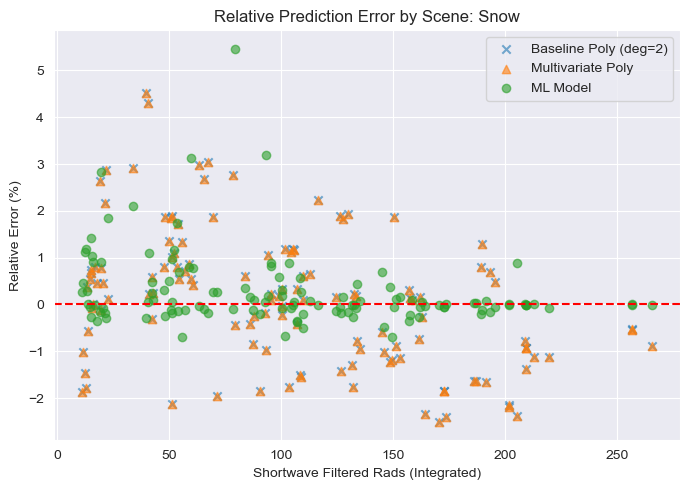

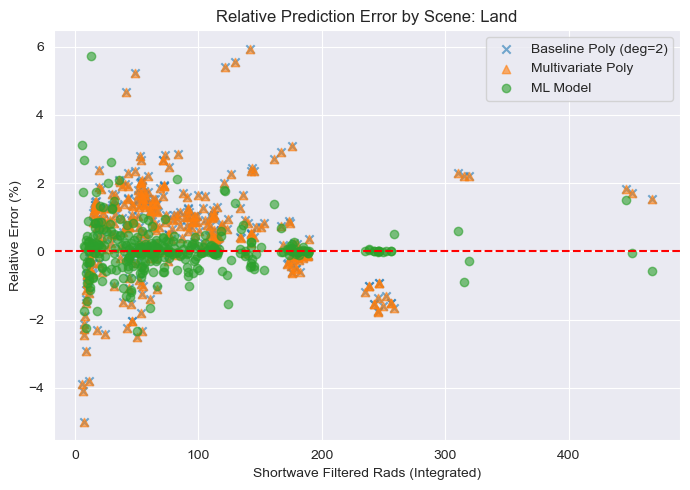

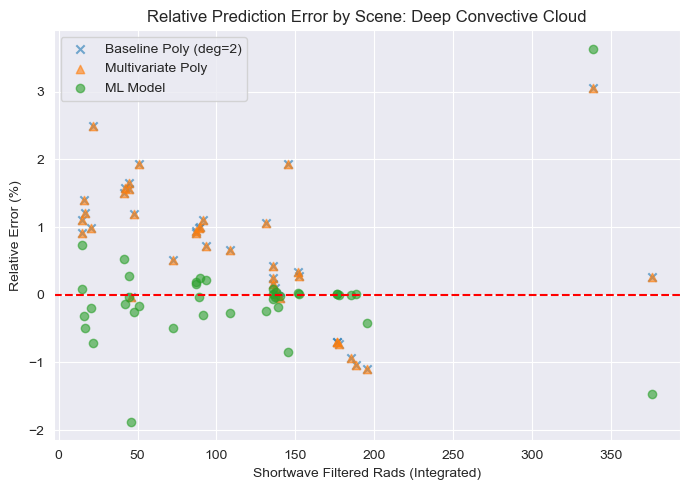

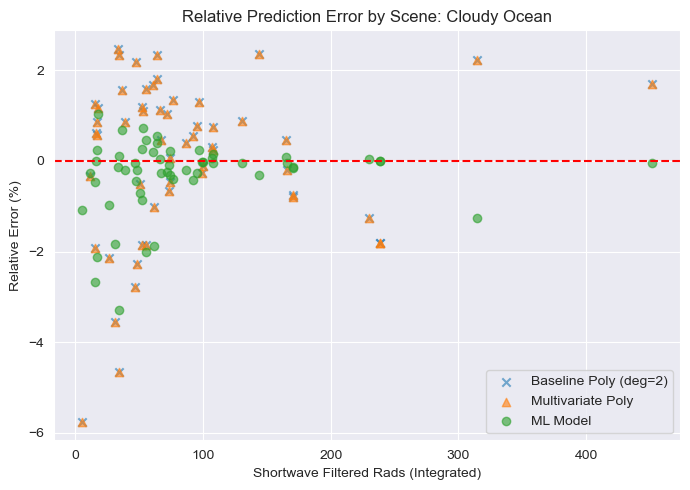

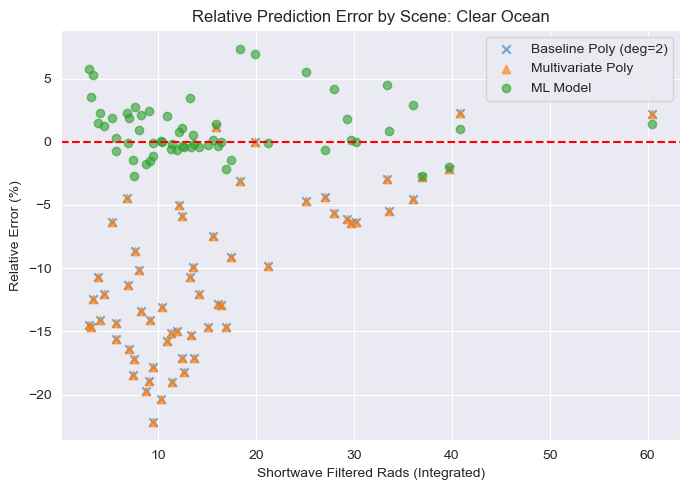

In [245]:
compare_methods_per_scene(
    train_df=pd.concat([train_i4_df, val_i4_df], axis=0),
    eval_df=test_i4_df,
    model=gs_no_geo_no_i4_refit["Final_Model"],
    is_sw=True,   # or False for LW
    poly_degree=2
)

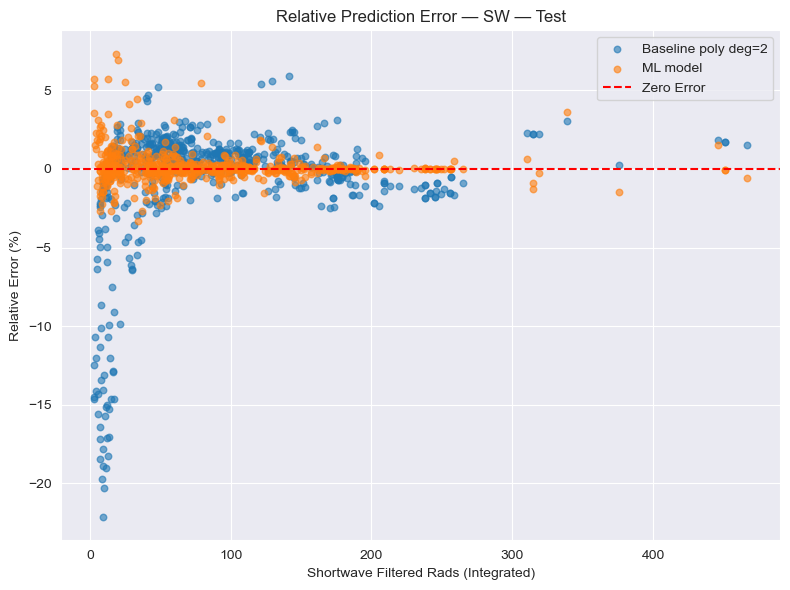

TEST baseline: {'degree': 2, 'RMSE': 2.287401747103276, 'MAE': 1.4755005083306034, 'MAPE%': 2.1239640217604294, 'R2': 0.9994507281879511}
TEST model   : {'RMSE': 1.0387147743954042, 'MAE': 0.4029656394113209, 'MAPE%': 0.5502907418749249, 'R2': 0.9998867351815842}


In [251]:
cmp_test = compare_old_poly_vs_model(
    train_df=pd.concat([train_i4_df, val_i4_df], axis=0),   # fit baseline on train+val for fairness
    eval_df=test_i4_df,
    model=gs_no_geo_no_i4_refit["Final_Model"],
    is_sw=True,
    poly_degree=2,
    title_suffix="Test"
)
print("TEST baseline:", cmp_test["baseline"])
print("TEST model   :", cmp_test["model"])

In [30]:
land_all = all_dataset[all_dataset["Scene"] == "Land"].copy()
land_all.columns

Index(['Scene', 'SZA', 'VZA', 'RAZ', 'Cloud', 'Run #',
       'Shortwave Unfiltered Rads (Integrated)',
       'Longwave Unfiltered Rads (Integrated)',
       'Shortwave Filtered Rads (Integrated)',
       'Longwave Filtered Rads (Integrated)', 'M1', 'M2', 'M3', 'M4', 'I1',
       'M5', 'DNB', 'M6', 'I2', 'M7', 'M8', 'M9', 'I3', 'M10', 'M11', 'I4',
       'M12', 'M13', 'M14', 'M15', 'I5', 'M16', 'Scaled Shortwave Filtered',
       'Scaled Shortwave Unfiltered', 'Scaled Longwave Filtered',
       'Scaled Longwave Unfiltered'],
      dtype='object')

In [35]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

unfilt_sw = land_all['Shortwave Unfiltered Rads (Integrated)'].to_numpy()
filt_sw = land_all['Shortwave Filtered Rads (Integrated)'].to_numpy()

print(np.shape(unfilt_sw), np.shape(filt_sw))

input = filt_sw.reshape(-1, 1)
output = unfilt_sw.reshape(-1, 1)

print(np.shape(input), np.shape(output))

poly_model = PolynomialFeatures(degree=1)
poly_x = poly_model.fit_transform(input)

poly_model.fit(poly_x, output)

regression = LinearRegression()
regression.fit(poly_x, output)

predicted = regression.predict(poly_x)
print(f"r^2 Value: {r2_score(unfilt_sw, predicted)}")
print(f"Mean Squared Error: {mean_squared_error(unfilt_sw, predicted)}")

mv_relative_error = (unfilt_sw-predicted)/unfilt_sw*100

(3150,) (3150,)
(3150, 1) (3150, 1)
r^2 Value: 0.9989574378065708
Mean Squared Error: 7.218355255729035


In [36]:
subset = land_all[(land_all["SZA"].between(40,60)) &
                  (land_all["VZA"].between(15,30)) &
                  (land_all["RAZ"].between(15,60))]

filt_sw_bin = subset['Shortwave Filtered Rads (Integrated)'].to_numpy()
unfilt_sw_bin = subset['Shortwave Unfiltered Rads (Integrated)'].to_numpy()

input_bin = filt_sw_bin.reshape(-1, 1)
output_bin = unfilt_sw_bin.reshape(-1, 1)

print(np.shape(input_bin), np.shape(output_bin))

poly_model_bin = PolynomialFeatures(degree=1)
poly_x_bin = poly_model_bin.fit_transform(input_bin)

poly_model_bin.fit(poly_x_bin, output_bin)

regression_bin = LinearRegression()
regression_bin.fit(poly_x_bin, output_bin)

predicted_bin = regression_bin.predict(poly_x_bin)
print(f"r^2 Value: {r2_score(unfilt_sw_bin, predicted_bin)}")
print(f"Mean Squared Error: {mean_squared_error(unfilt_sw_bin, predicted_bin)}")

mv_relative_error_bin = (unfilt_sw_bin-predicted_bin)/unfilt_sw_bin*100

(30, 1) (30, 1)
r^2 Value: 0.9999108521471843
Mean Squared Error: 0.43130662368247114


For all Land Clear data:
r^2 Value: 0.9989574378065708
Mean Squared Error: 7.218355255729035

For binned Land Clear data:
r^2 Value: 0.9999108521471843
Mean Squared Error: 0.43130662368247114


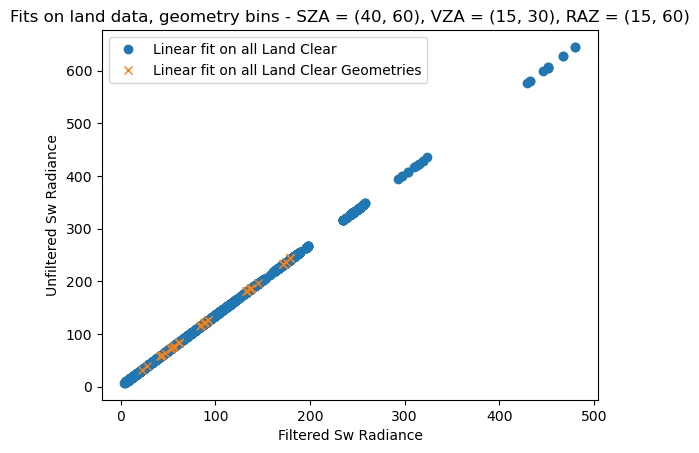

In [37]:
plt.plot(filt_sw, predicted, "o", label="Linear fit on all Land Clear")
plt.plot(filt_sw_bin, predicted_bin, "x", label="Linear fit on all Land Clear Geometries")
plt.title("Fits on land data, geometry bins - SZA = (40, 60), VZA = (15, 30), RAZ = (15, 60)")
plt.xlabel("Filtered Sw Radiance")
plt.ylabel("Unfiltered Sw Radiance")
plt.legend()


print("For all Land Clear data:")
print(f"r^2 Value: {r2_score(unfilt_sw, predicted)}")
print(f"Mean Squared Error: {mean_squared_error(unfilt_sw, predicted)}")
print("\nFor binned Land Clear data:")
print(f"r^2 Value: {r2_score(unfilt_sw_bin, predicted_bin)}")
print(f"Mean Squared Error: {mean_squared_error(unfilt_sw_bin, predicted_bin)}")

For all Land Clear data:
r^2 Value: 0.9989574378065708
Mean Squared Error: 2.6866996958590357

For binned Land Clear data:
r^2 Value: 0.9999108521471843
Mean Squared Error: 0.6567393879481199


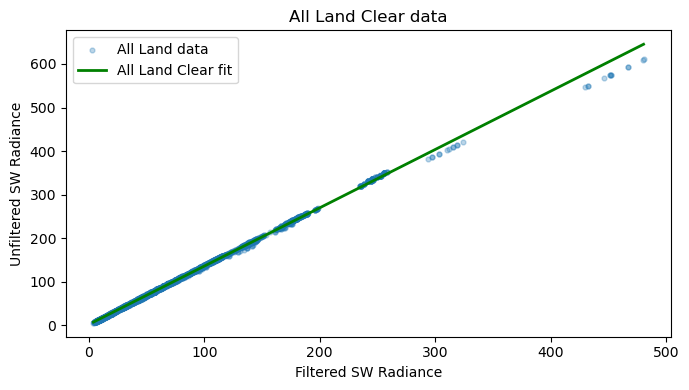

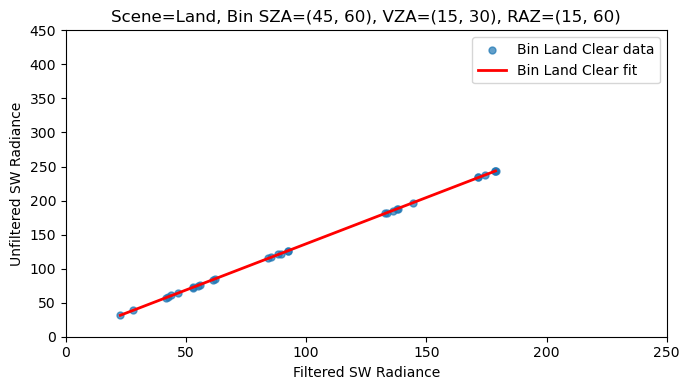

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

def compare_global_vs_bin_fit(df, scene="Land", sza_range=(45,60), vza_range=(15,30), raz_range=(15,60), degree=1):
    """
    Compare global linear/poly fit vs a single geometry-bin fit.
    Plots both fits together.

    Args:
        df: DataFrame with 'Scene','SZA','VZA','RAZ', SW filtered/unfiltered columns.
        scene: which Scene to filter to.
        *_range: tuple of (low, high) to select bin for SZA,VZA,RAZ.
        degree: polynomial degree (1=linear, 2=quadratic).
    """
    filt_col = "Shortwave Filtered Rads (Integrated)"
    unfilt_col = "Shortwave Unfiltered Rads (Integrated)"

    # ---- GLOBAL FIT ----
    land = df[df["Scene"] == scene]
    X_global = land[[filt_col]].to_numpy().reshape(-1, 1)  # just filtered radiance
    y_global = land[unfilt_col].to_numpy().reshape(-1, 1)

    poly = PolynomialFeatures(degree=degree)
    Xg_poly = poly.fit_transform(X_global)
    g_model = LinearRegression().fit(Xg_poly, y_global)

    # ---- BIN FIT ----
    # subset = land[
    #     land["SZA"].between(*sza_range) &
    #     land["VZA"].between(*vza_range) &
    #     land["RAZ"].between(*raz_range)
    # ]
    subset = land_all[(land_all["SZA"].between(40,60)) &
                  (land_all["VZA"].between(15,30)) &
                  (land_all["RAZ"].between(15,60))]

    X_bin = subset['Shortwave Filtered Rads (Integrated)'].to_numpy().reshape(-1, 1)
    y_bin = subset['Shortwave Unfiltered Rads (Integrated)'].to_numpy().reshape(-1, 1)

    Xb_poly = poly.fit_transform(X_bin)
    b_model = LinearRegression().fit(Xb_poly, y_bin)

    print("For all Land Clear data:")
    print(f"r^2 Value: {r2_score(unfilt_sw, predicted)}")
    print(f"Mean Squared Error: {root_mean_squared_error(unfilt_sw, predicted)}")
    print("\nFor binned Land Clear data:")
    print(f"r^2 Value: {r2_score(unfilt_sw_bin, predicted_bin)}")
    print(f"Mean Squared Error: {root_mean_squared_error(unfilt_sw_bin, predicted_bin)}")

    x_line = np.linspace(min(X_global.min(), X_bin.min()),
                         max(X_global.max(), X_bin.max()), 200).reshape(-1,1)
    x_line_poly = poly.transform(x_line)




    plt.figure(figsize=(7,4))
    # scatter the data
    plt.scatter(X_global, y_global, s=12, alpha=0.3, label="All Land data")
    idx_g = np.argsort(X_global.ravel())
    plt.plot(X_global[idx_g], g_model.predict(Xg_poly)[idx_g],
             color="green", lw=2, label="All Land Clear fit")

    plt.xlabel("Filtered SW Radiance")
    plt.ylabel("Unfiltered SW Radiance")
    plt.title(f"All Land Clear data")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,4))
    plt.scatter(X_bin, y_bin, s=25, alpha=0.7, label="Bin Land Clear data")
    # plt.scatter(X_global, y_global, s=12, alpha=0.3, label="All Land data")
    idx_b = np.argsort(X_bin.ravel())
    # plt.plot(X_global[idx_g], g_model.predict(Xg_poly)[idx_g],
    #          color="green", lw=2, label="All Land Clear fit")
    plt.plot(X_bin[idx_b], b_model.predict(Xb_poly)[idx_b],
             color="red", lw=2, label="Bin Land Clear fit")

    plt.xlabel("Filtered SW Radiance")
    plt.ylabel("Unfiltered SW Radiance")
    plt.xlim(0, 250)
    plt.ylim(0, 450)
    plt.title(f"Scene={scene}, Bin SZA={sza_range}, VZA={vza_range}, RAZ={raz_range}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # plot fits
    # change the global line to orange, bin line to, say, purple
    # plt.plot(X_global, g_model.predict(Xg_poly), color="orange", lw=2, label="Global fit")
    # plt.plot(X_bin, b_model.predict(Xb_poly), color="purple", lw=2, linestyle="--", label="Bin fit")
    # plt.plot(X_bin, X_bin, color="yellow", lw=2, linestyle="--", label="Linear reference")
    # plt.plot(X_bin, y_bin, color="red", lw=2, linestyle="--", label="Bin exact unfilt values")
    # plt.plot(X_global, y_global, color="green", lw=2, linestyle="--", label="All exact unfilt values")


    # plt.plot(x_line, g_model.predict(x_line_poly), color="orange", lw=2, label="All Land Clear fit")
    # plt.plot(x_line, b_model.predict(x_line_poly), color="yellow", lw=2, label="Bin Land Clear fit")




compare_global_vs_bin_fit(
    land_all,
    scene="Land",
    sza_range=(45,60),
    vza_range=(15,30),
    raz_range=(15,60),
    degree=1  # linear, or 2 for quadratic
)

In [351]:
import pandas as pd
import statsmodels.formula.api as smf

def ancova_compare_lines(df_land, df_bin, spectrum="sw"):
    y = "Shortwave Unfiltered Rads (Integrated)" if spectrum=="sw" else "Longwave Unfiltered Rads (Integrated)"
    x = "Shortwave Filtered Rads (Integrated)"   if spectrum=="sw" else "Longwave Filtered Rads (Integrated)"

    land = df_land[[x, y]].copy().assign(Bin=0)
    binn = df_bin[[x, y]].copy().assign(Bin=1)
    pooled = pd.concat([land, binn], axis=0, ignore_index=True).dropna()
    pooled = pooled.rename(columns={
        "Shortwave Unfiltered Rads (Integrated)": "SW_Unfiltered",
        "Shortwave Filtered Rads (Integrated)": "SW_Filtered"
    })


    # ANCOVA: y ~ x + Bin + x:Bin
    # m = smf.ols(formula=f"`{y}` ~ `{x}` + Bin + `{x}`:Bin", data=pooled).fit()
    m = smf.ols("SW_Unfiltered ~ SW_Filtered + Bin + SW_Filtered:Bin", data=pooled).fit()

    print(m.params.index)


    slope_test = m.f_test("SW_Filtered:Bin = 0")
    intercept_test = m.f_test("Bin = 0")

    from statsmodels.stats.outliers_influence import variance_inflation_factor

    X = m.model.exog  # design matrix
    vif = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    temp = list(zip(m.model.exog_names, vif))

    return {
        "summary": m.summary(),
        "slope_p": float(slope_test.pvalue),
        "intercept_p": float(intercept_test.pvalue),
        "vif" : temp
    }
subset = land_all[(land_all["SZA"].between(40,60)) &
                  (land_all["VZA"].between(15,30)) &
                  (land_all["RAZ"].between(15,60))]

In [352]:
ancova_compare_lines(land_all, subset)

Index(['Intercept', 'SW_Filtered', 'Bin', 'SW_Filtered:Bin'], dtype='object')


{'summary': <class 'statsmodels.iolib.summary.Summary'>
 """
                             OLS Regression Results                            
 Dep. Variable:          SW_Unfiltered   R-squared:                       0.999
 Model:                            OLS   Adj. R-squared:                  0.999
 Method:                 Least Squares   F-statistic:                 1.022e+06
 Date:                Tue, 30 Sep 2025   Prob (F-statistic):               0.00
 Time:                        15:29:58   Log-Likelihood:                -7640.9
 No. Observations:                3180   AIC:                         1.529e+04
 Df Residuals:                    3176   BIC:                         1.531e+04
 Df Model:                           3                                         
 Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
 -----------------------------------------------------